# Non-academic Collaboration — tagging through analysis

One notebook, end to end: classify each paper's research organisations into a
collaborator taxonomy, then analyse the result. It replaces the former pair
(`04_non_academic_04_collab_analysis` + `04_non_academic_05_collab_classifier`),
which split the workflow across two files whose input and output filenames did
not agree.

**The classification step is skipped whenever its output already exists.** §1
reads `output/non_academic_flagged_full_company.xlsx` if it is there and makes no
API calls at all; only a missing file (or `FORCE_RECLASSIFY = True`) triggers the
LLM pass. Everything from §2 on is unchanged reporting over
[`data_analysis_04_non_academic_collab_helpers.py`](../utils/data_analysis_04_non_academic_collab_helpers.py).

## Workflow

1. **Tag** — classify each paper's `research_orgs` as academic / non-academic /
   company / UK company (§1). Cached and skippable.
2. Prepare normalised organisation fields and derive the 8-sector taxonomy (§2).
3. Summary statistics and top collaborator tables (§3–4).
4. Collaborator patterns over organisation, time, discipline and geography (§5–10).
5. Top-cited papers by taxonomy sector, and the publication figure (§11–12).

> **Running the classifier needs an Anthropic API key** (`ANTHROPIC_API_KEY`, or an
> `ant auth login` profile) and `pip install anthropic`. It is not needed to re-run
> the analysis on an existing classified file. See
> [`doc/04_non_academic_methodology.md`](../../doc/04_non_academic_methodology.md) §5.2.

In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

import pandas as pd
from IPython.display import display

from utils.shared_showcase import load_showcase
from utils import data_analysis_04_non_academic_collab_classifier as CLS
from utils import data_analysis_04_non_academic_collab_helpers as h

h.apply_project_plot_style()

# ---------------------------------------------------------------- run controls
FORCE_RECLASSIFY = False        # True re-runs the LLM pass even if the output exists
CLS_MODEL = CLS.DEFAULT_MODEL   # "claude-sonnet-5" — see the module for why not Opus/Haiku
CLS_EFFORT = CLS.DEFAULT_EFFORT # "low" — short-string classification, not reasoning

# Both live under data/analysis/, with the other analysis-derived tables. The classified
# file is an INPUT to §2 onward, not a deliverable, so it does not belong in output/.
CLASSIFIED_PATH = P.COLLAB_FLAGGED   # data/analysis/non_academic/collaboration/…full_company.csv
CACHE_PATH = P.COLLAB_CACHE          # …/collab_classifier_cache.jsonl

print("classified file:", CLASSIFIED_PATH, "| exists:", CLASSIFIED_PATH.exists())

classified file: /Users/valler/Python/RA/20_years_of_ukb/data/analysis/non_academic/collaboration/non_academic_flagged_full_company.csv | exists: True


## 1. Tag collaborators

`load_or_classify` returns the existing classified file untouched when it is
present. The index lists it produces are **positions in `research_orgs`** — that
alignment is what lets §2 read each organisation's GRID type and country to assign
a sector, so the classifier and the taxonomy must never be pointed at different
organisation lists.

In [2]:
# The corpus. `research_orgs` is the classifier's input AND the taxonomy's lookup
# table, so it has to be parsed here and carried through to the saved file.
# `journal_title_raw` and `research_org_countries` are carried for §7 and §10: without
# the first, _pick_journal_name returns "" for every row and the journal table silently
# comes back empty; the second is §10's fallback when an org carries no GRID country.
# They must be requested HERE, before classification — the file written below is what
# every later section reads.
corpus = load_showcase(
    columns=["id", "title", "year", "times_cited", "altmetric",
             "category_for_2020", "research_orgs", "authors",
             "journal_title_raw", "research_org_countries"],
    parse=["research_orgs", "authors", "category_for_2020"],
)
print(f"corpus: {len(corpus):,} publications")

df_flagged, ran_classifier = CLS.load_or_classify(
    corpus,
    out_path=CLASSIFIED_PATH,
    cache_path=CACHE_PATH,
    force=FORCE_RECLASSIFY,
    model=CLS_MODEL,
    effort=CLS_EFFORT,
)
print(f"classifier ran this session: {ran_classifier}")

corpus: 26,109 publications


  reusing non_academic_flagged_full_company.csv (26,109 rows) — no API calls, no cost. Pass force=True to reclassify.
classifier ran this session: False


## 2. Prepare and derive the sector taxonomy

`require_sector_columns=False` on purpose: the classifier emits index lists, and
`add_non_academic_sector_taxonomy` derives the eight sector labels from those plus
each organisation's GRID metadata. Requiring the columns to pre-exist would demand
that the LLM name the sectors itself — a second, less reliable judgement where a
lookup does the job.

In [3]:
df, data_path, raw_df = h.load_and_prepare_dataframe(
    data_path=CLASSIFIED_PATH,
    require_sector_columns=False,
)

print(f"Loaded file: {data_path}")
print(f"Loaded raw rows: {len(raw_df)}")
print(f"Rows after data preparation: {len(df)}")
print(f"Rows with parsed institutions: {(df['all_institutions'].map(len) > 0).sum()}")
print(f"Rows with any non-academic org parsed: {(df['non_academic_institutions_norm'].map(len) > 0).sum()}")
print(f"Rows with any company parsed: {(df['company_institutions_norm'].map(len) > 0).sum()}")
print(f"Rows with parsed affiliation mentions: {(df['affiliation_names'].map(len) > 0).sum()}")
print(f"Rows with >=1 sector label: {(df['non_academic_sector_labels'].map(len) > 0).sum()}")

if len(df) <= 1000:
    print(
        "WARNING: loaded a small dataset (<=1000 rows). "
        "If unexpected, check input file selection."
    )

Loaded file: /Users/valler/Python/RA/20_years_of_ukb/data/analysis/non_academic/collaboration/non_academic_flagged_full_company.csv
Loaded raw rows: 26109
Rows after data preparation: 26071
Rows with parsed institutions: 24988
Rows with any non-academic org parsed: 24984
Rows with any company parsed: 1923
Rows with parsed affiliation mentions: 25277
Rows with >=1 sector label: 24984


## 3. Core Statistics and Top Collaborators

Statistics are computed from taxonomy sectors using paper-level collaborator organization contributions.

In [4]:
top_sector_tables, unique_counts = h.build_top_sector_collaborator_tables(df, n=30)
stats = h.compute_summary_stats(df, unique_counts=unique_counts)

for line in h.summary_stats_as_lines(stats):
    print(line)

for label in h.NON_ACADEMIC_SECTOR_LABELS:
    table = top_sector_tables.get(label, pd.DataFrame()).head(10)
    if table.empty:
        print(f"Top {label} collaborators: none")
        continue
    display(table.style.set_caption(f"Top {label} collaborators"))


Total papers: 26071
Papers with any taxonomy sector collaborator: 24984 (95.83%)
Papers with any company collaborator: 1923 (7.38%)
Papers with Company (non-UK): 1660 (6.37%)
Papers with UK company: 365 (1.4%)
University/HEI: 68978 mentions (56.2%), 22835 papers (91.4%), mean orgs/paper=2.646
Unique University/HEI institutions: 2016
Hospital/Clinical: 33873 mentions (27.6%), 15094 papers (60.4%), mean orgs/paper=1.299
Unique Hospital/Clinical institutions: 2375
Government/Public: 4491 mentions (3.7%), 3293 papers (13.2%), mean orgs/paper=0.172
Unique Government/Public institutions: 317
Research institute/Centre: 8437 mentions (6.9%), 5073 papers (20.3%), mean orgs/paper=0.324
Unique Research institute/Centre institutions: 615
Nonprofit/Charity: 4233 mentions (3.4%), 3173 papers (12.7%), mean orgs/paper=0.162
Unique Nonprofit/Charity institutions: 267
Company (non-UK): 2207 mentions (1.8%), 1660 papers (6.6%), mean orgs/paper=0.085
Unique Company (non-UK) institutions: 445
UK company: 3

,org,papers
0,Harvard University,2318
1,University of Oxford,1909
2,University College London,1125
3,King's College London,1120
4,University of Cambridge,1061
5,Imperial College London,1058
6,University of Edinburgh,973
7,Karolinska Institutet,946
8,University of Bristol,882
9,University of Pennsylvania,744


,org,papers
0,Massachusetts General Hospital,1487
1,The Brigham and Women's Hospital Inc,1004
2,Vanderbilt University Medical Center,412
3,Erasmus MC,376
4,West China Hospital of Sichuan University,368
5,Tongji Medical College of Huazhong University of Science and Technology,364
6,University Medical Center Utrecht,316
7,University Medical Center Groningen,298
8,Oslo University Hospital,278
9,Guangdong Provincial People’s Hospital,278


,org,papers
0,National Cancer Institute,293
1,Ministry of Education of the People's Republic of China,223
2,International Agency for Research on Cancer,209
3,National Institute on Aging,191
4,National Institutes of Health,173
5,National Institute for Health and Care Research,168
6,Finnish Institute for Health and Welfare,153
7,NIHR Oxford Musculoskeletal Biomedical Research Centre,147
8,Inserm,134
9,Norwegian Institute of Public Health,124


,org,papers
0,MRC Integrative Epidemiology Unit,847
1,MRC Epidemiology Unit,327
2,QIMR Berghofer Medical Research Institute,326
3,Institute for Molecular Medicine Finland,308
4,Wellcome Centre for Human Genetics,234
5,Helmholtz Zentrum München,220
6,Wellcome Centre for Integrative Neuroimaging,172
7,German Centre for Cardiovascular Research,166
8,The Alan Turing Institute,161
9,MRC Human Genetics Unit,160


,org,papers
0,Broad Institute,1458
1,Wellcome Sanger Institute,254
2,Health Data Research UK,176
3,Baker IDI Heart and Diabetes Institute,169
4,Swiss Institute of Bioinformatics,141
5,UK Biobank,87
6,Kaiser Permanente,71
7,UCL Institute of Ophthalmology,71
8,Lundbeck Foundation,67
9,Cancer Council Victoria,67


,org,papers
0,Decode Genetics ehf,129
1,Regeneron Pharmaceuticals Inc,123
2,23andMe Inc,113
3,Kaiser Permanente,59
4,Calico Life Sciences LLC,54
5,Biogen Inc,52
6,Fimlab (Finland),46
7,Genentech Inc,43
8,Data Tecnica International (United States),38
9,GlaxoSmithKline LLC,36


,org,papers
0,Novo Nordisk Research Centre Oxford Ltd,80
1,AstraZeneca UK Ltd,70
2,GlaxoSmithKline Research and Development Ltd,40
3,Perspectum Ltd,32
4,Genomics England Ltd,25
5,Genomics PLC,14
6,Huma Therapeutics Ltd,13
7,The Francis Crick Institute Ltd,8
8,Siemens Healthcare Ltd,5
9,Microsoft Research (United Kingdom),5


,org,papers
0,Ikerbasque,19
1,Cambridge Biomedical Campus,14
2,Cancer Registry of Norway,9
3,Mútua Terrassa,7
4,British Library,7
5,China National GeneBank,4
6,National Cancer Registry,4
7,Consorzio per l'AREA di Ricerca Scientifica e Tecnologica di Trieste,3
8,Romanian Academy,3
9,Blood Transfusion Service of Namibia,3


## 4. Collaborator Sector Taxonomy

Sector labels are assigned per collaborator using structured `research_orgs` metadata and classifier indices (academic + non-academic union).

Taxonomy used:
- University/HEI
- Hospital/Clinical
- Government/Public
- Research institute/Centre
- Nonprofit/Charity
- Company (non-UK)
- UK company
- Other/Unknown

Collaborator taxonomy summary (derived from research_orgs + index mapping):


,sector,institution_mentions,papers,mentions_pct,papers_pct_of_non_academic_papers,papers_pct_of_taxonomy_papers
0,University/HEI,68978,22835,56.2,91.398495,91.4
1,Hospital/Clinical,33873,15094,27.6,60.414665,60.4
2,Government/Public,4491,3293,3.7,13.180435,13.2
3,Research institute/Centre,8437,5073,6.9,20.304995,20.3
4,Nonprofit/Charity,4233,3173,3.4,12.700128,12.7
5,Company (non-UK),2207,1660,1.8,6.644252,6.6
6,UK company,389,365,0.3,1.460935,1.5
7,Other/Unknown,101,96,0.1,0.384246,0.4


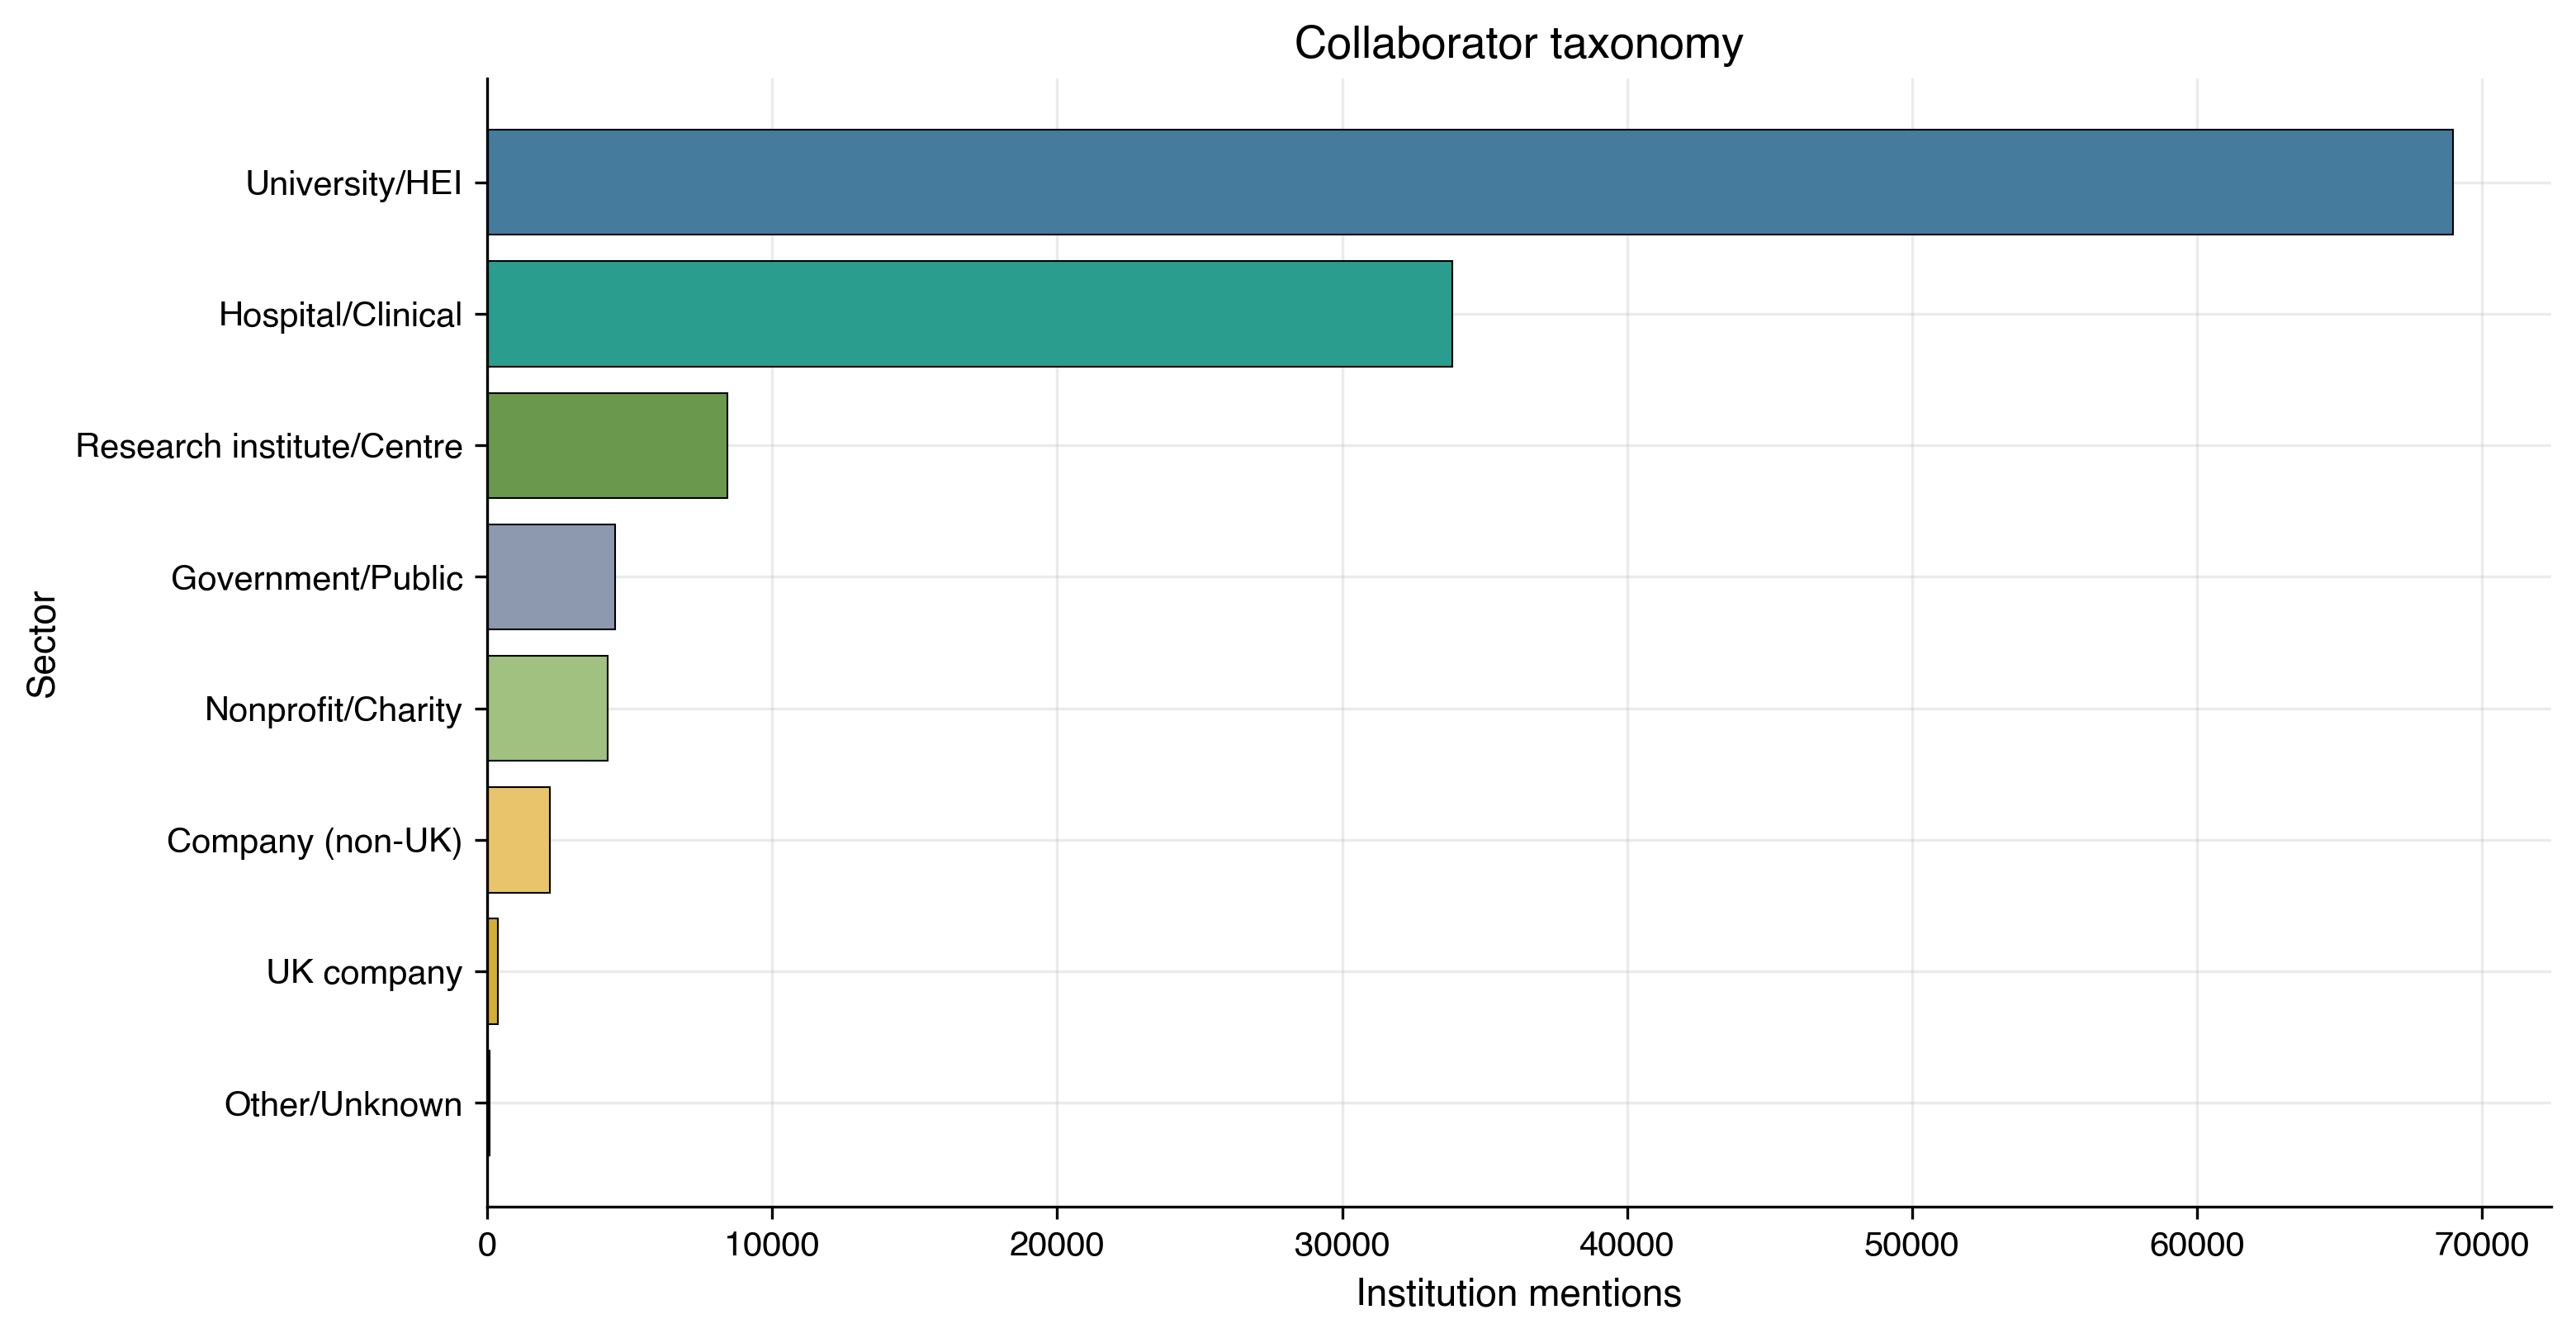

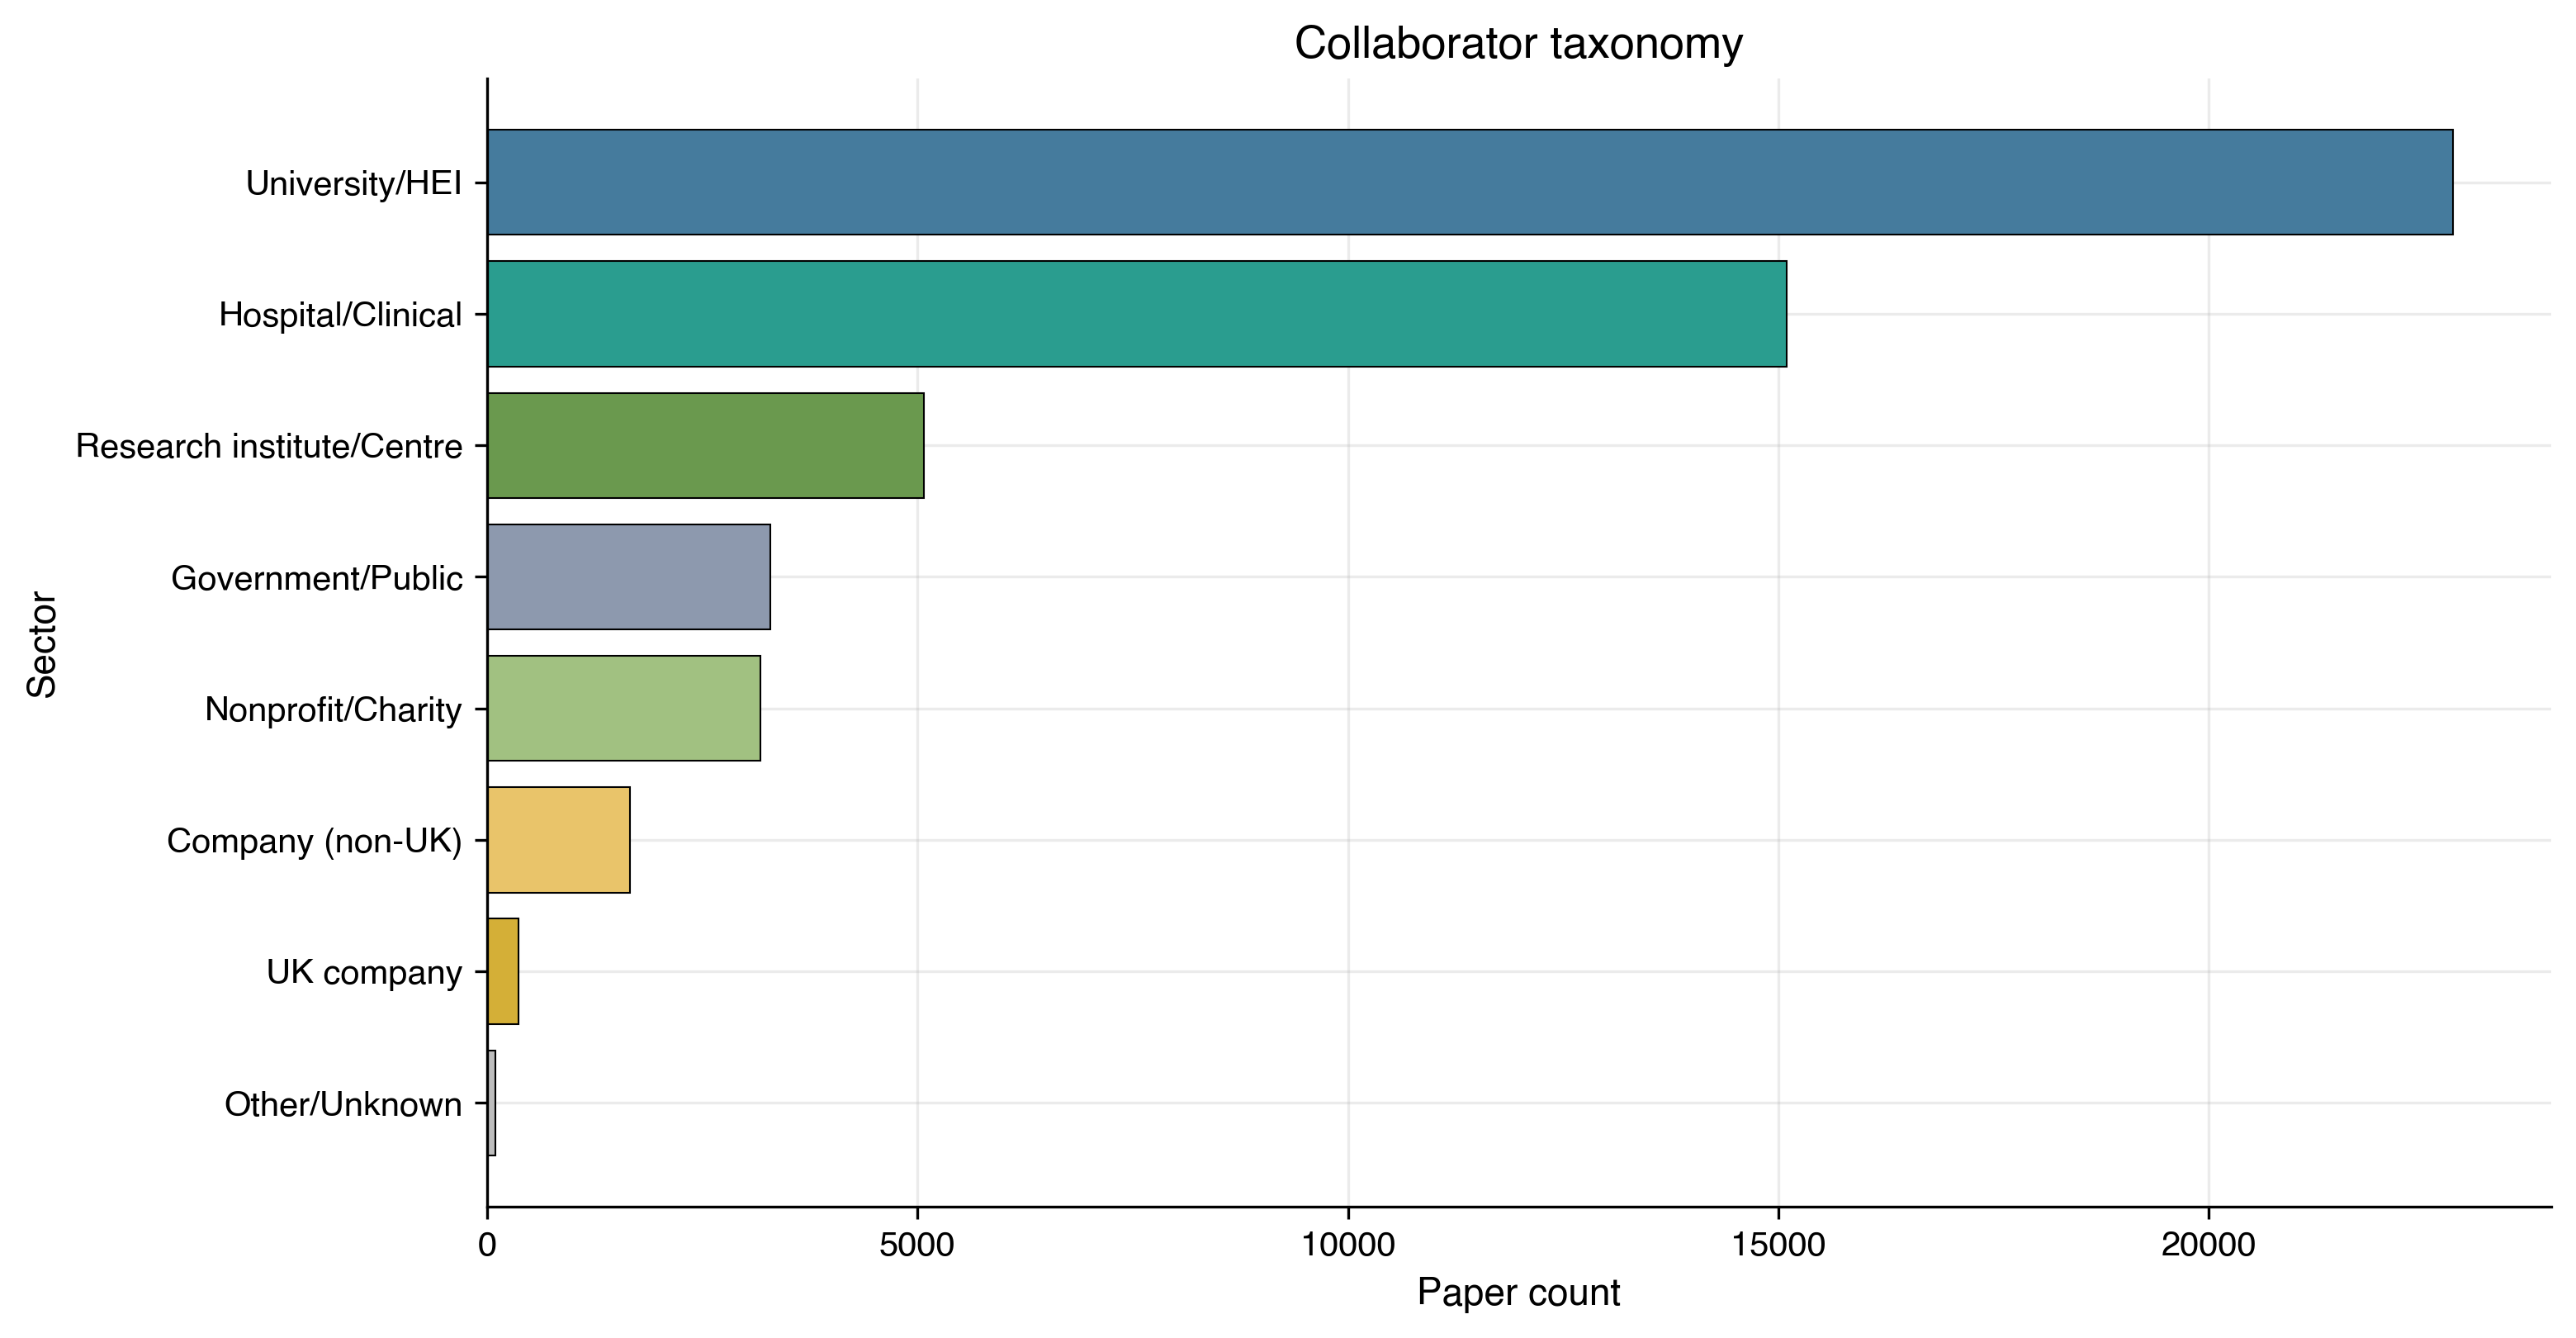

In [5]:
sector_summary_df = h.build_non_academic_sector_summary(df)

print("Collaborator taxonomy summary (derived from research_orgs + index mapping):")
display(
    sector_summary_df.assign(
        mentions_pct=lambda d: d["mentions_pct"].round(1),
        papers_pct_of_taxonomy_papers=lambda d: d["papers_pct_of_taxonomy_papers"].round(1),
    )
)

h.plot_non_academic_sector_breakdown(sector_summary_df, value_col="institution_mentions")
h.plot_non_academic_sector_breakdown(sector_summary_df, value_col="papers")


## 5. Organization-Level Distributions and Rankings

Organization rankings and prevalence figures are shown by taxonomy sector.

Top Hospital/Clinical collaborators:


,org,papers
0,Massachusetts General Hospital,1487
1,The Brigham and Women's Hospital Inc,1004
2,Vanderbilt University Medical Center,412
3,Erasmus MC,376
4,West China Hospital of Sichuan University,368
5,Tongji Medical College of Huazhong University ...,364
6,University Medical Center Utrecht,316
7,University Medical Center Groningen,298
8,Oslo University Hospital,278
9,Guangdong Provincial People’s Hospital,278


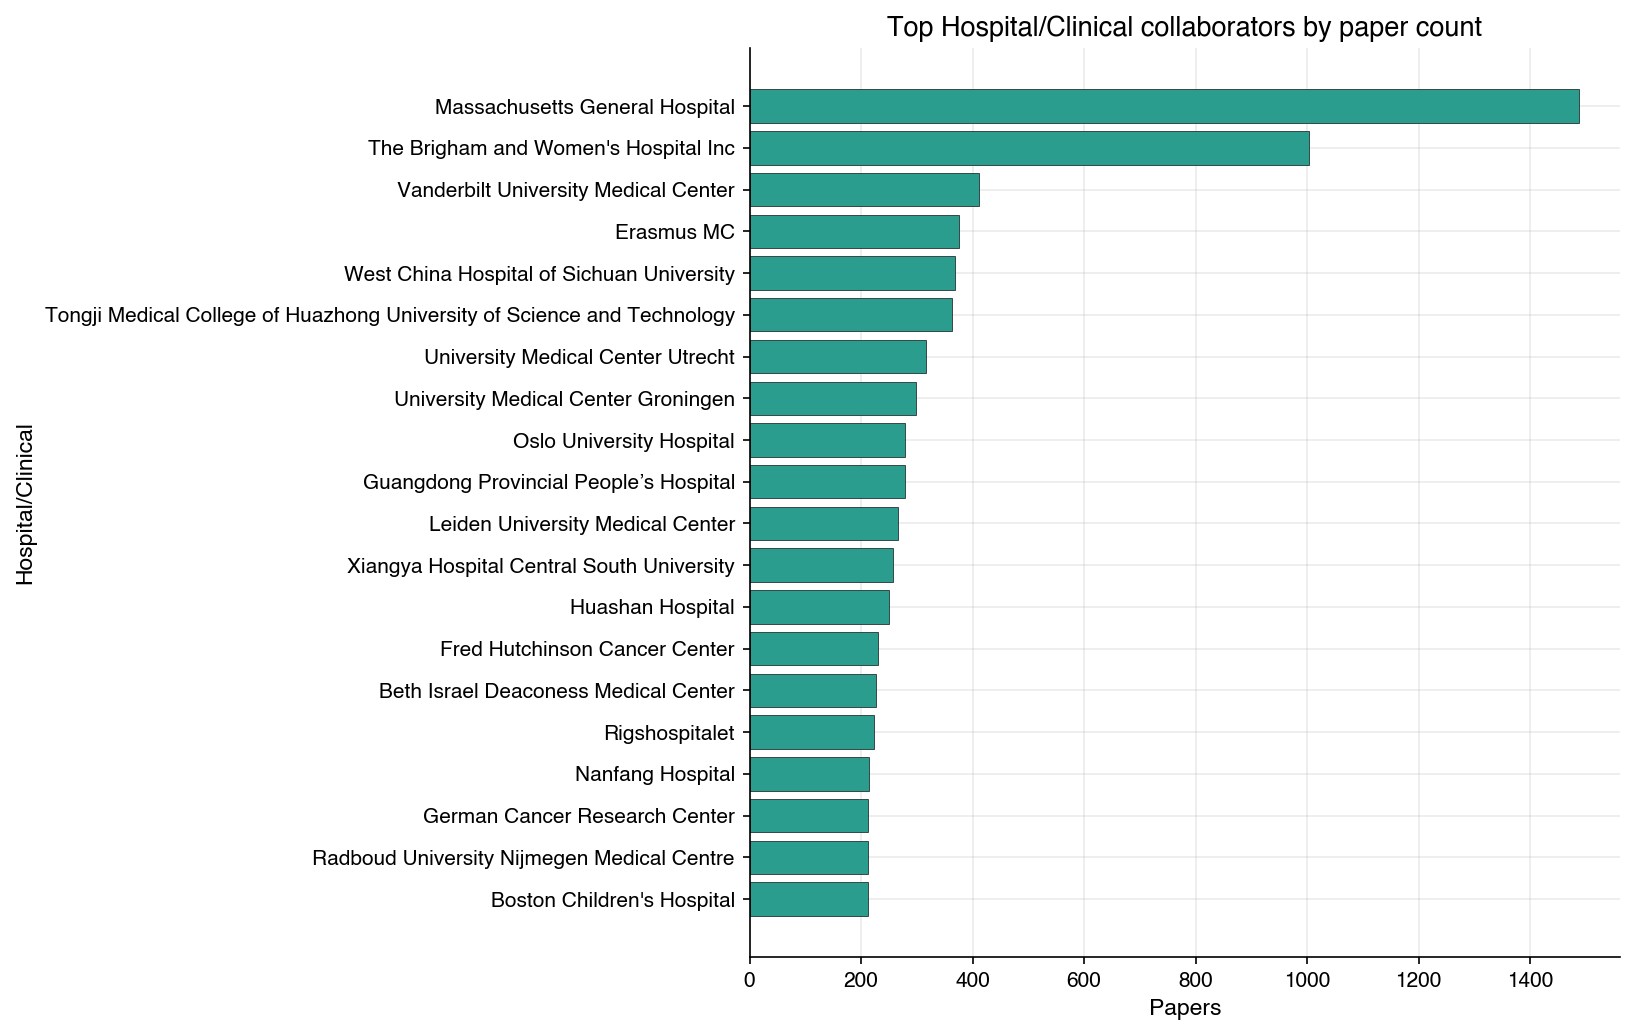

Top University/HEI collaborators:


,org,papers
0,Harvard University,2318
1,University of Oxford,1909
2,University College London,1125
3,King's College London,1120
4,University of Cambridge,1061
5,Imperial College London,1058
6,University of Edinburgh,973
7,Karolinska Institutet,946
8,University of Bristol,882
9,University of Pennsylvania,744


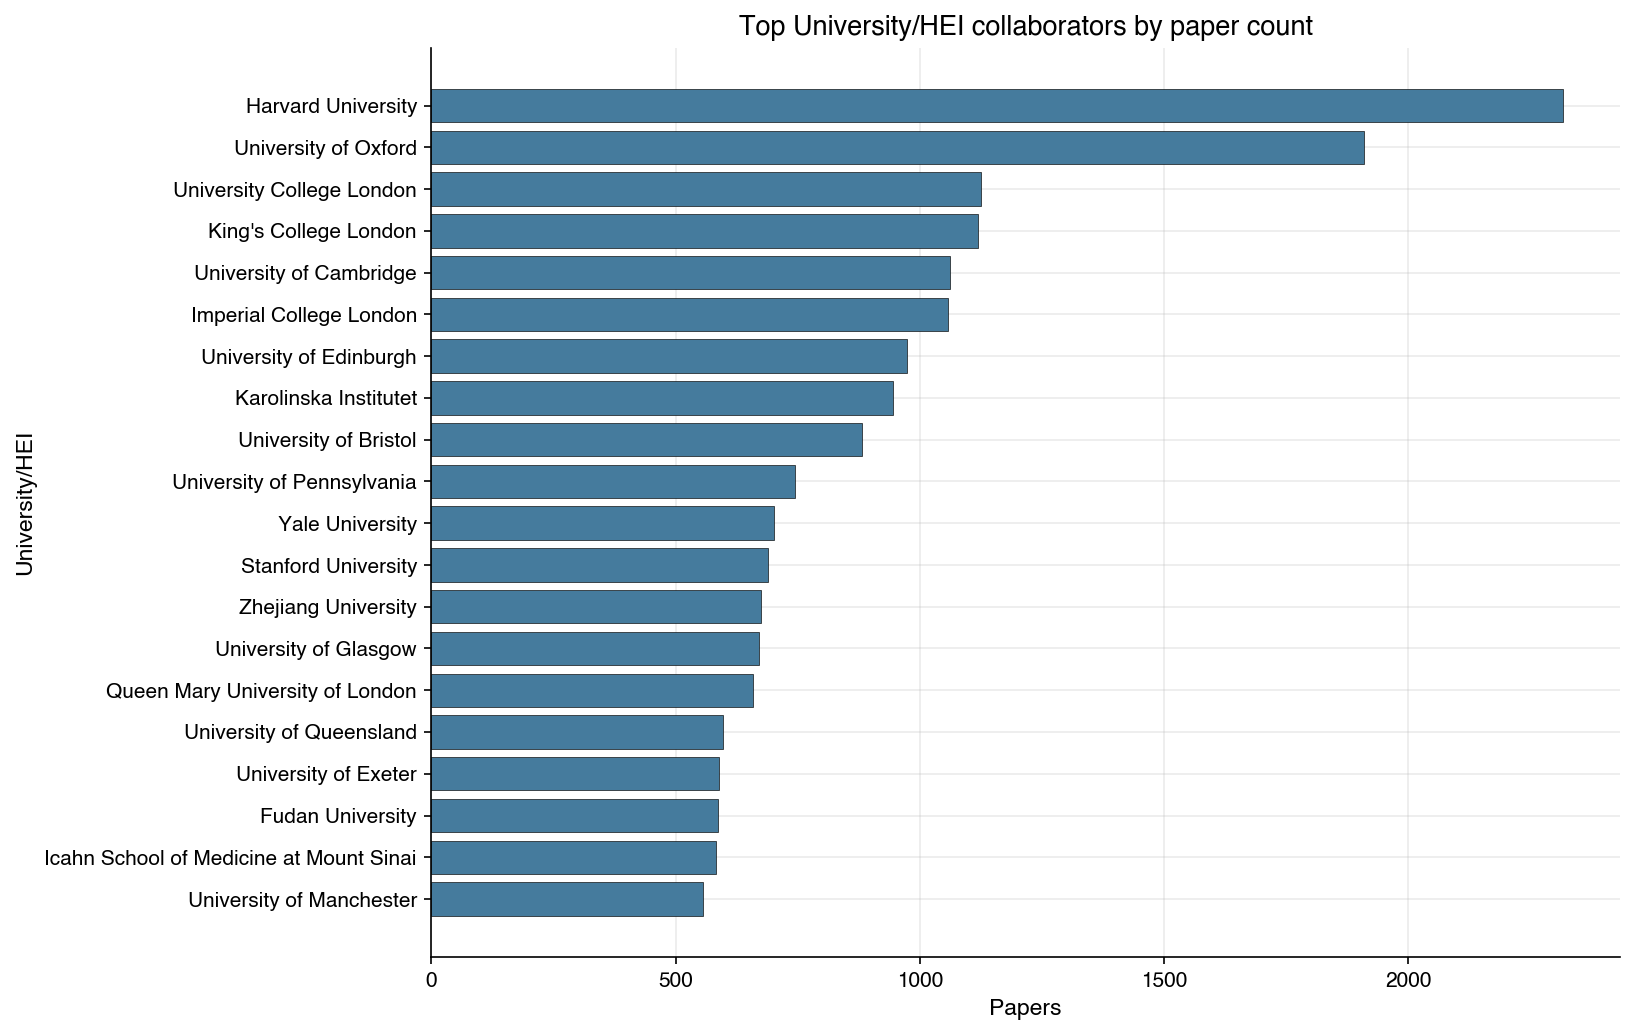

Top Government/Public collaborators:


,org,papers
0,National Cancer Institute,293
1,Ministry of Education of the People's Republic...,223
2,International Agency for Research on Cancer,209
3,National Institute on Aging,191
4,National Institutes of Health,173
5,National Institute for Health and Care Research,168
6,Finnish Institute for Health and Welfare,153
7,NIHR Oxford Musculoskeletal Biomedical Researc...,147
8,Inserm,134
9,Norwegian Institute of Public Health,124


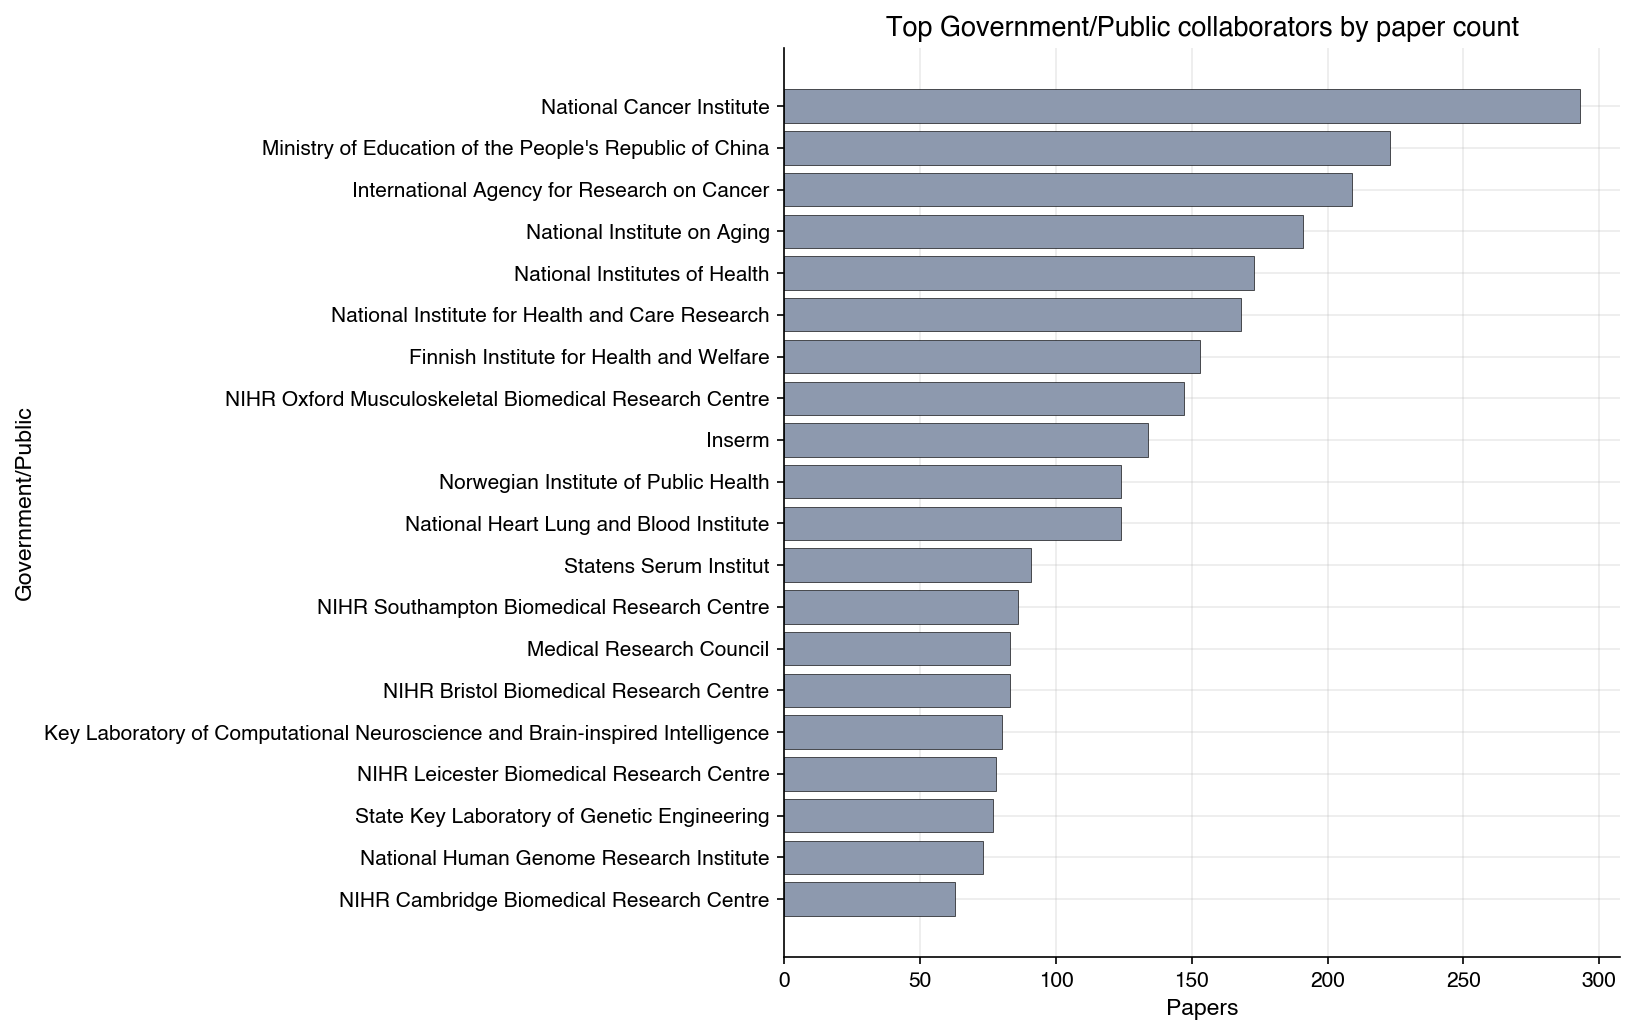

Top Research institute/Centre collaborators:


,org,papers
0,MRC Integrative Epidemiology Unit,847
1,MRC Epidemiology Unit,327
2,QIMR Berghofer Medical Research Institute,326
3,Institute for Molecular Medicine Finland,308
4,Wellcome Centre for Human Genetics,234
5,Helmholtz Zentrum München,220
6,Wellcome Centre for Integrative Neuroimaging,172
7,German Centre for Cardiovascular Research,166
8,The Alan Turing Institute,161
9,MRC Human Genetics Unit,160


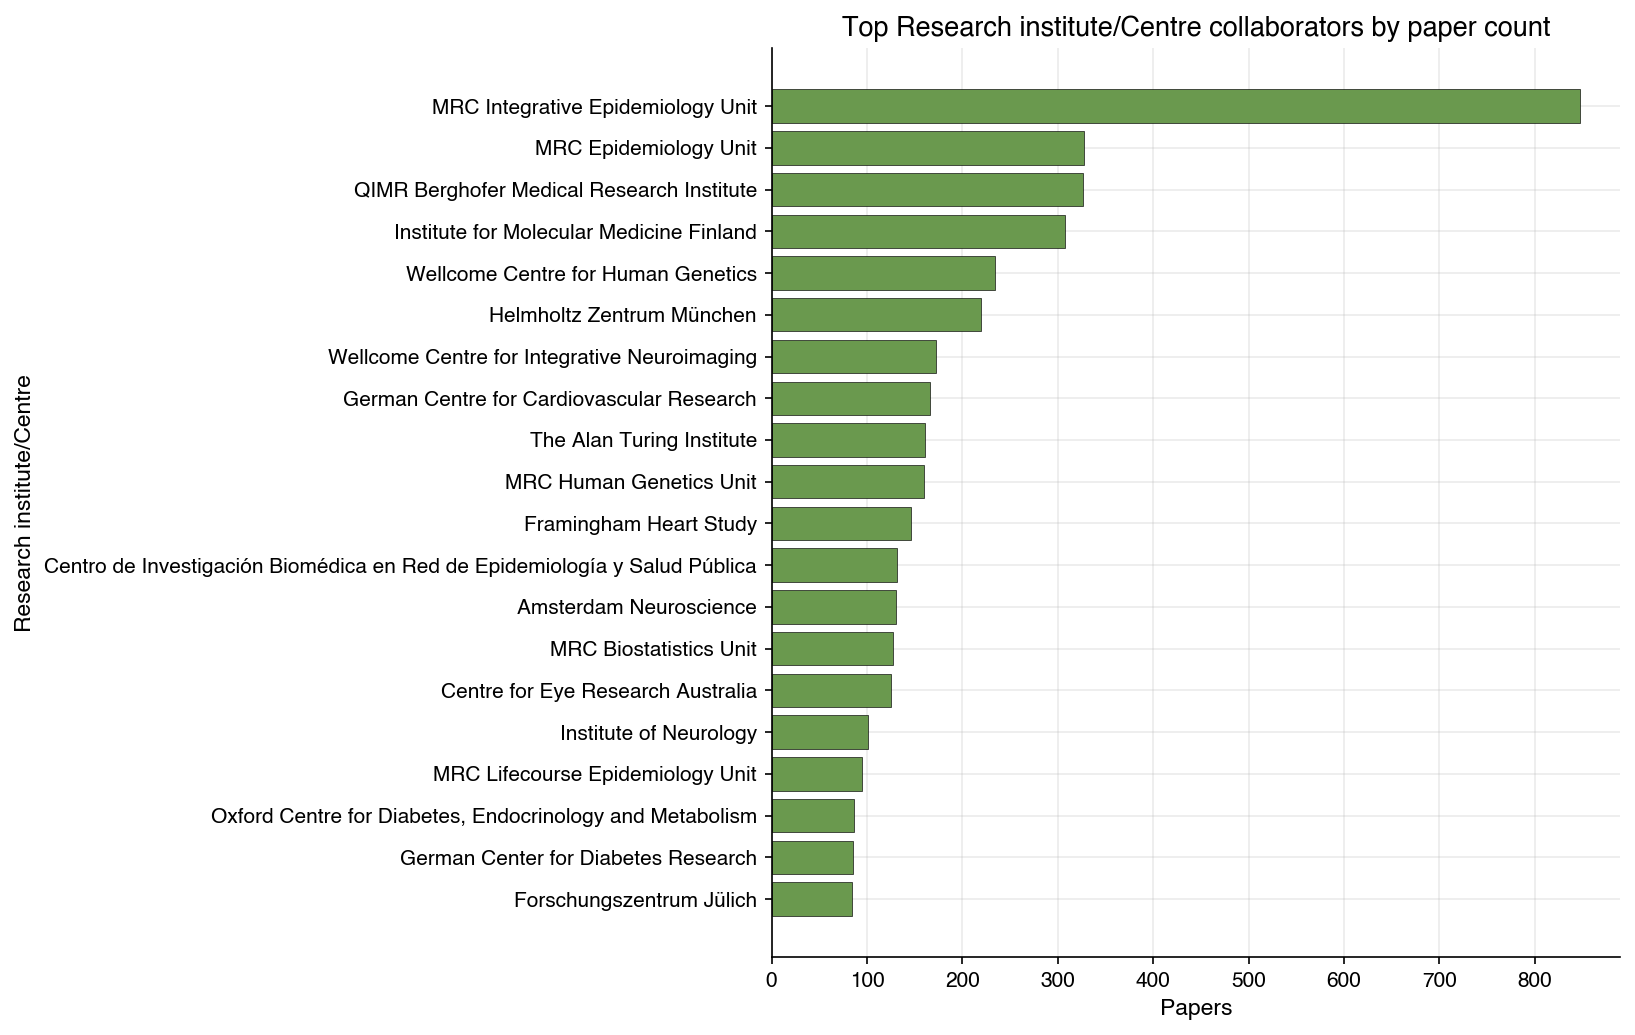

Top Nonprofit/Charity collaborators:


,org,papers
0,Broad Institute,1458
1,Wellcome Sanger Institute,254
2,Health Data Research UK,176
3,Baker IDI Heart and Diabetes Institute,169
4,Swiss Institute of Bioinformatics,141
5,UK Biobank,87
6,Kaiser Permanente,71
7,UCL Institute of Ophthalmology,71
8,Lundbeck Foundation,67
9,Cancer Council Victoria,67


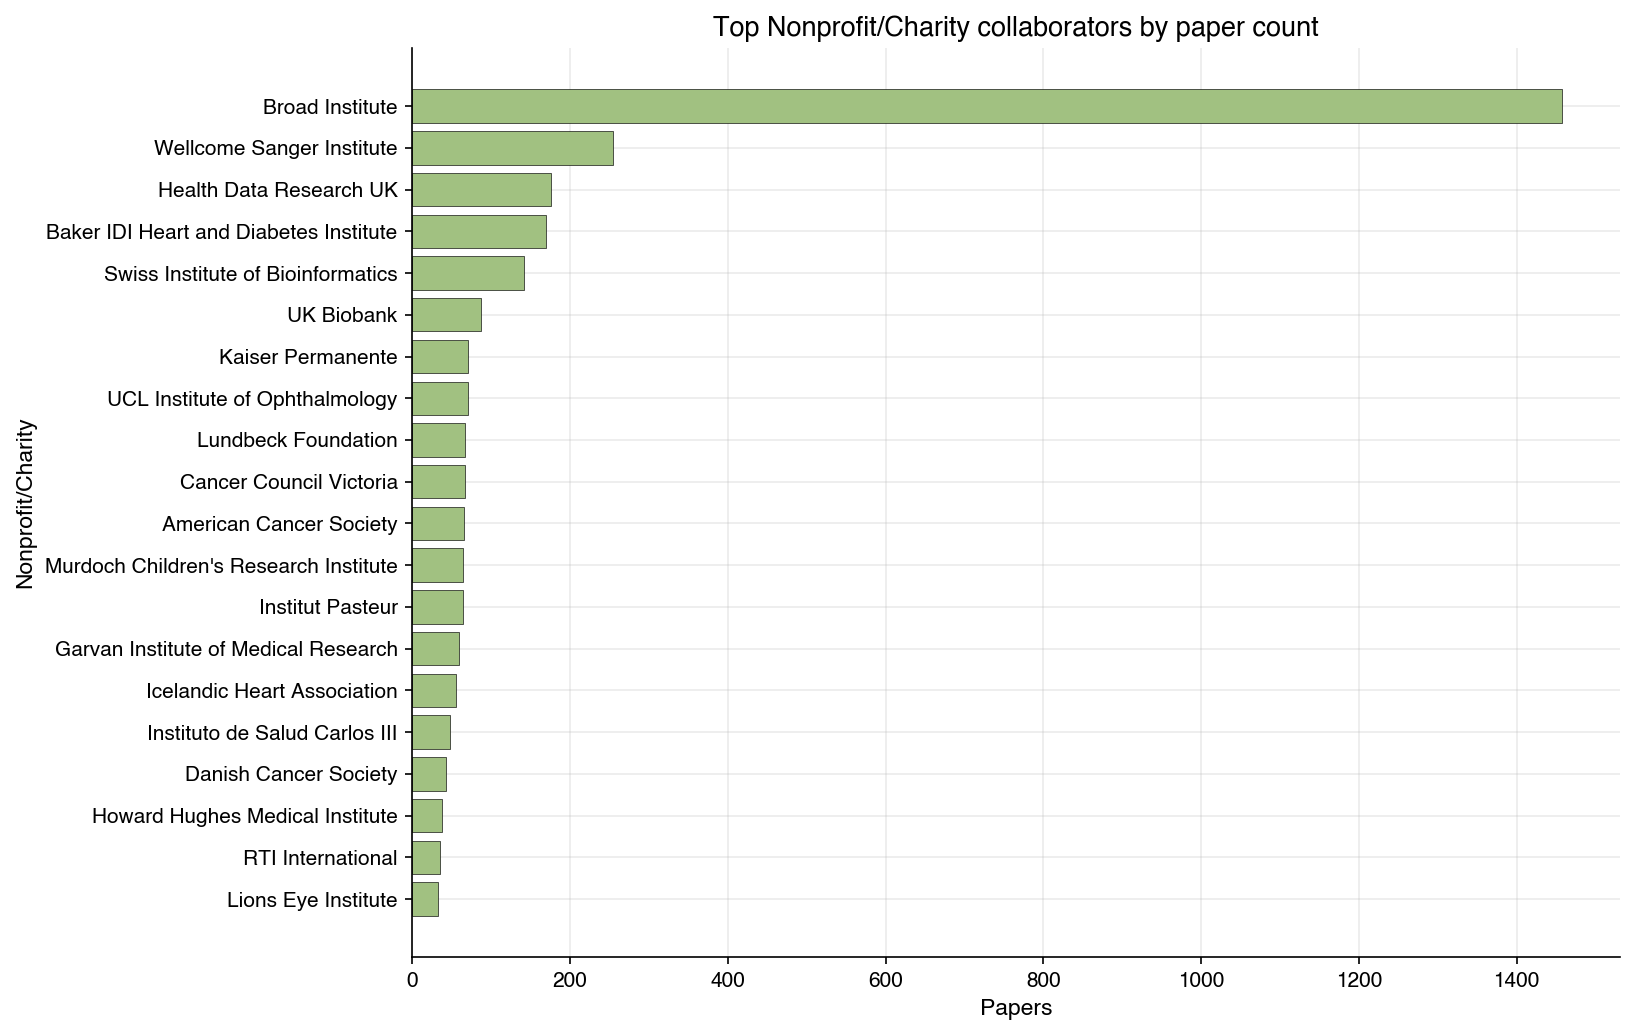

Top Company (non-UK) collaborators:


,org,papers
0,Decode Genetics ehf,129
1,Regeneron Pharmaceuticals Inc,123
2,23andMe Inc,113
3,Kaiser Permanente,59
4,Calico Life Sciences LLC,54
5,Biogen Inc,52
6,Fimlab (Finland),46
7,Genentech Inc,43
8,Data Tecnica International (United States),38
9,GlaxoSmithKline LLC,36


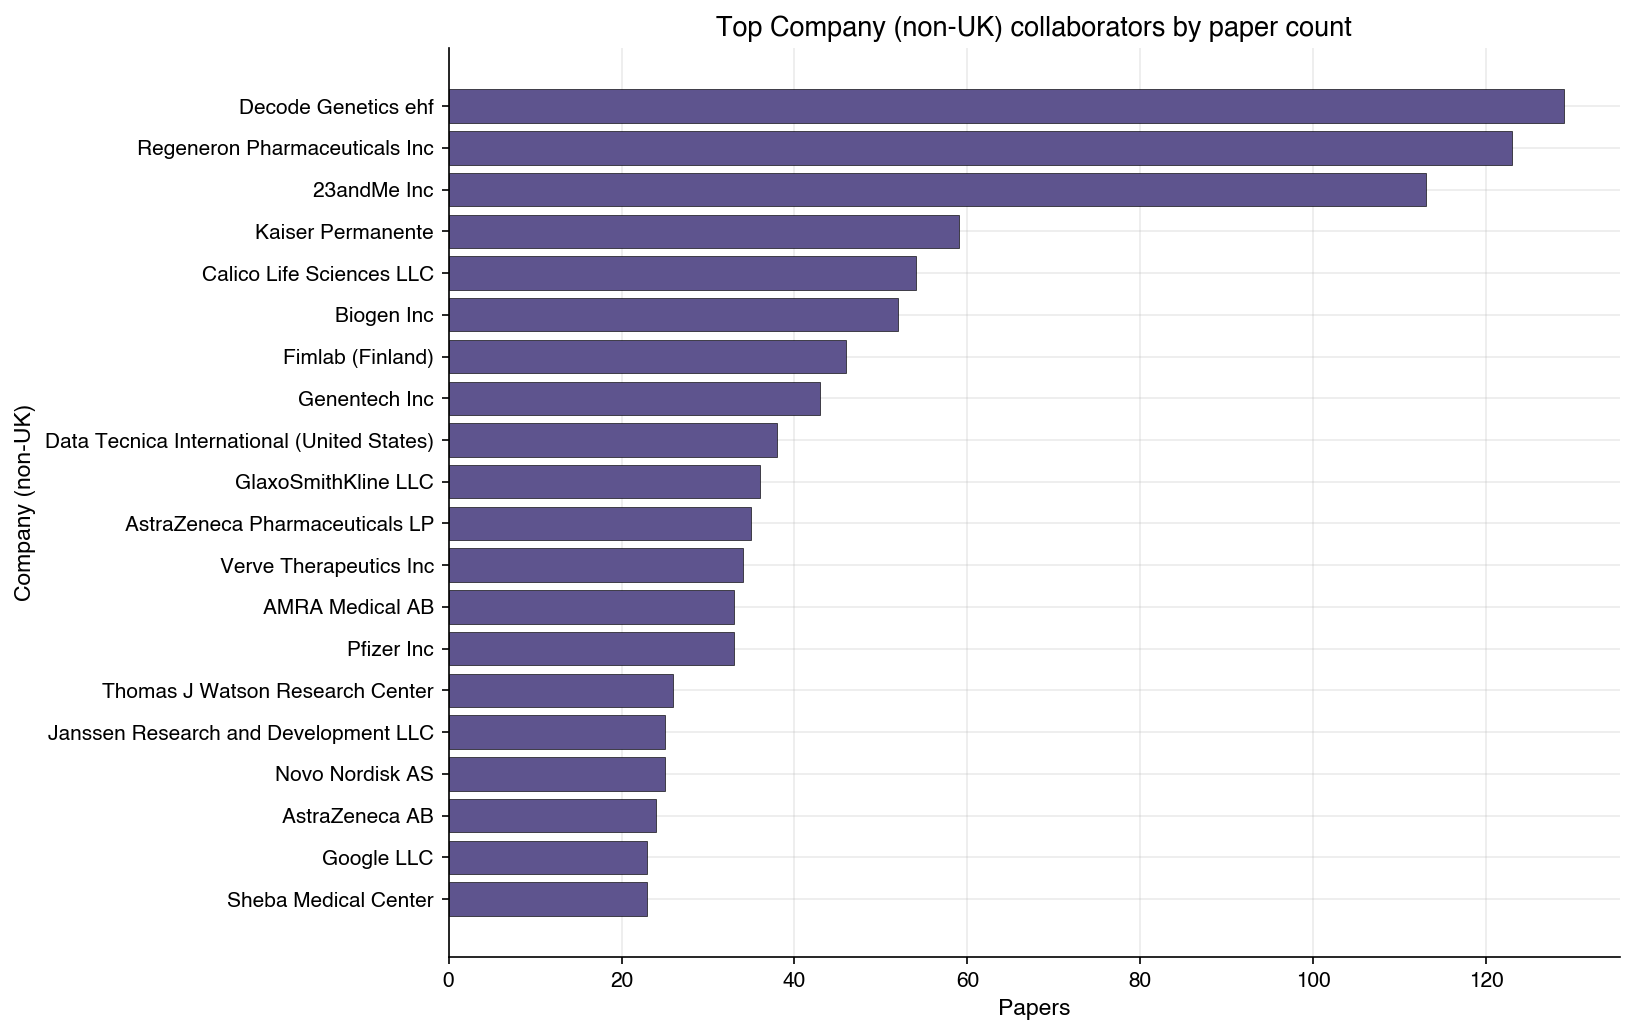

Top UK company collaborators:


,org,papers
0,Novo Nordisk Research Centre Oxford Ltd,80
1,AstraZeneca UK Ltd,70
2,GlaxoSmithKline Research and Development Ltd,40
3,Perspectum Ltd,32
4,Genomics England Ltd,25
5,Genomics PLC,14
6,Huma Therapeutics Ltd,13
7,The Francis Crick Institute Ltd,8
8,Siemens Healthcare Ltd,5
9,Microsoft Research (United Kingdom),5


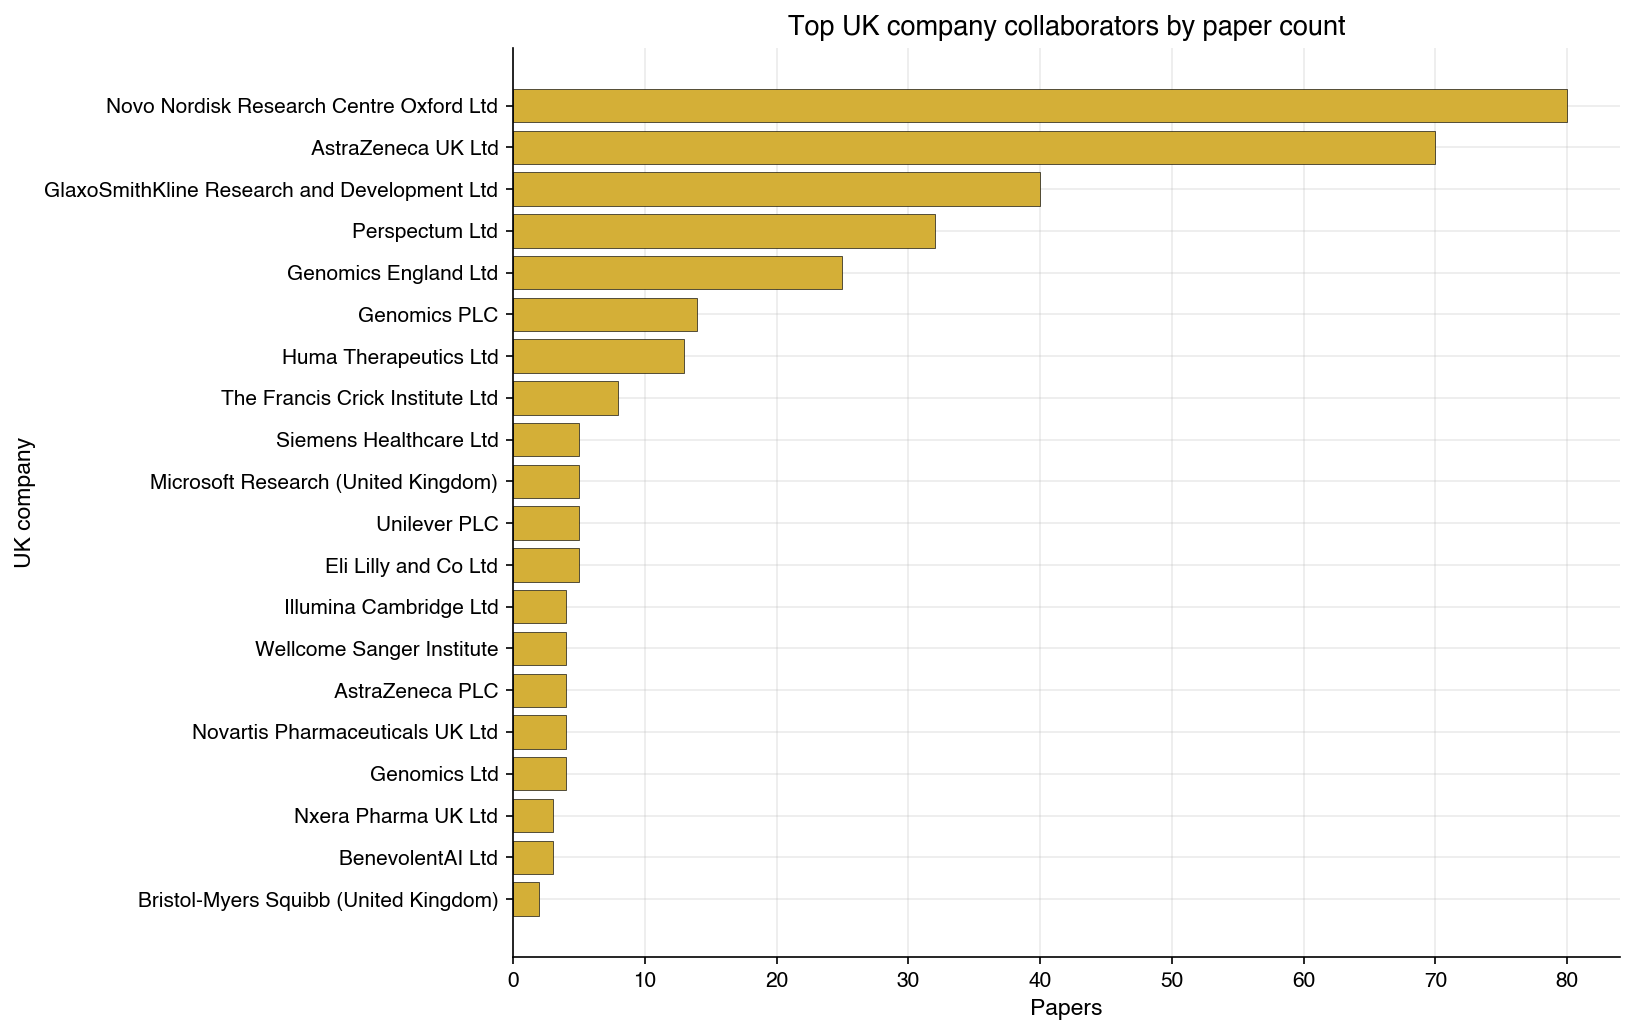

Top Other/Unknown collaborators:


,org,papers
0,Ikerbasque,19
1,Cambridge Biomedical Campus,14
2,Cancer Registry of Norway,9
3,Mútua Terrassa,7
4,British Library,7
5,China National GeneBank,4
6,National Cancer Registry,4
7,Consorzio per l'AREA di Ricerca Scientifica e ...,3
8,Romanian Academy,3
9,Blood Transfusion Service of Namibia,3


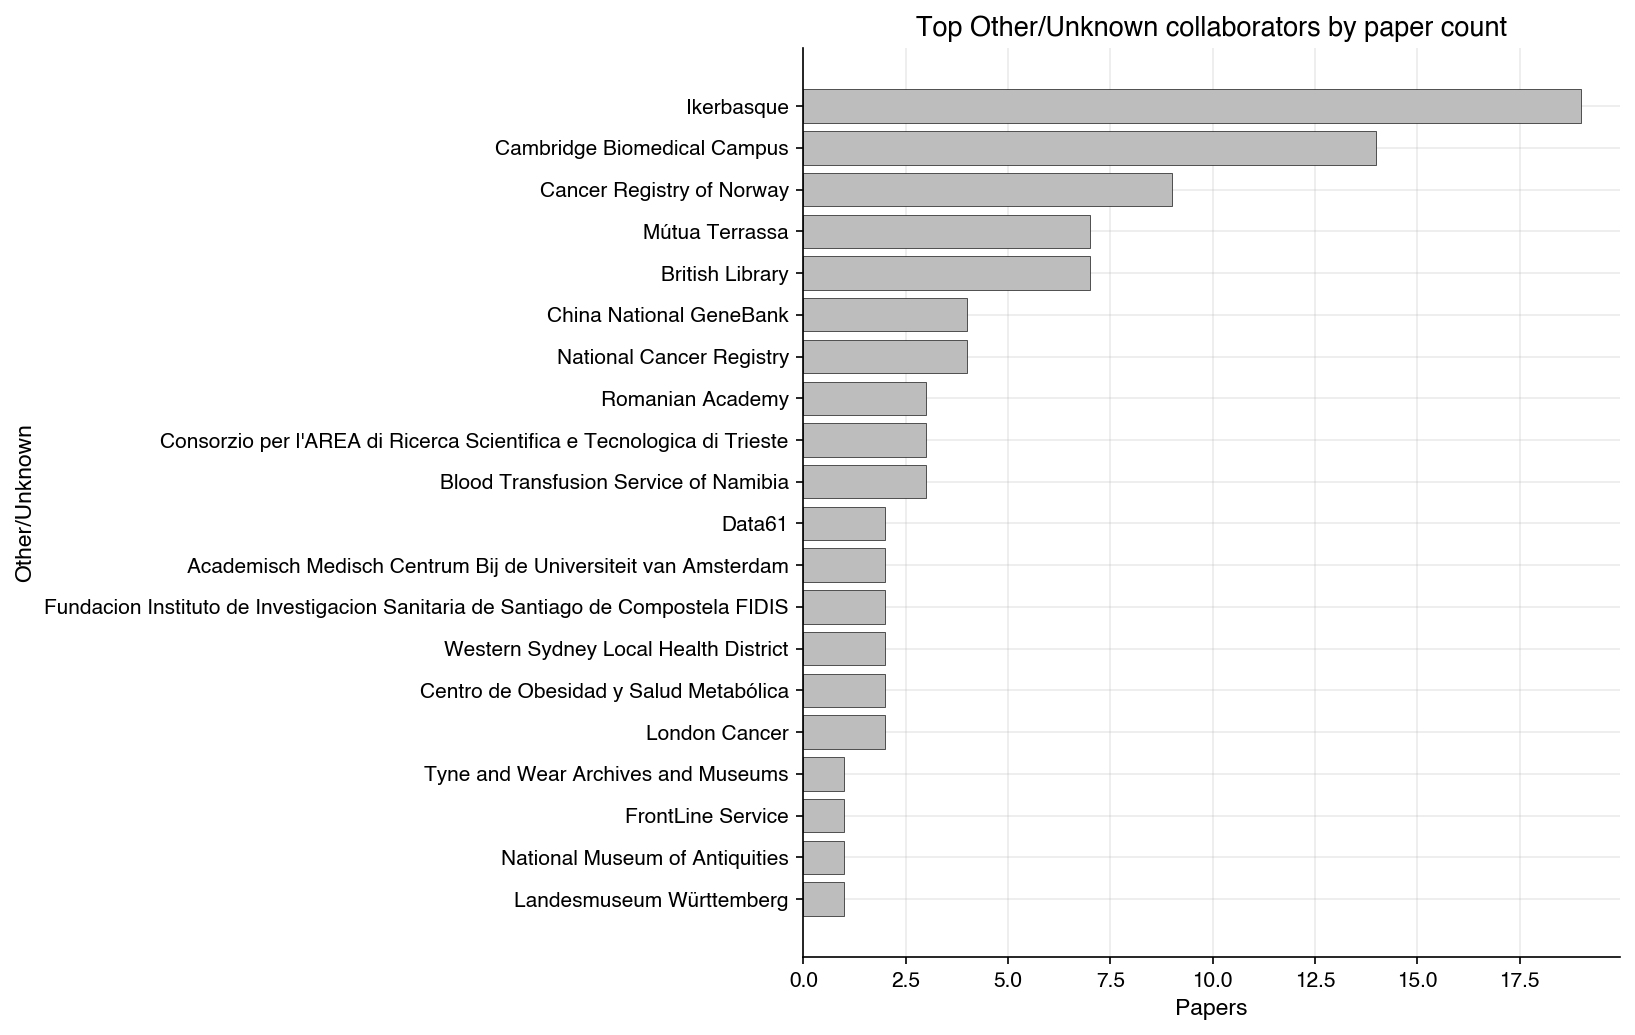

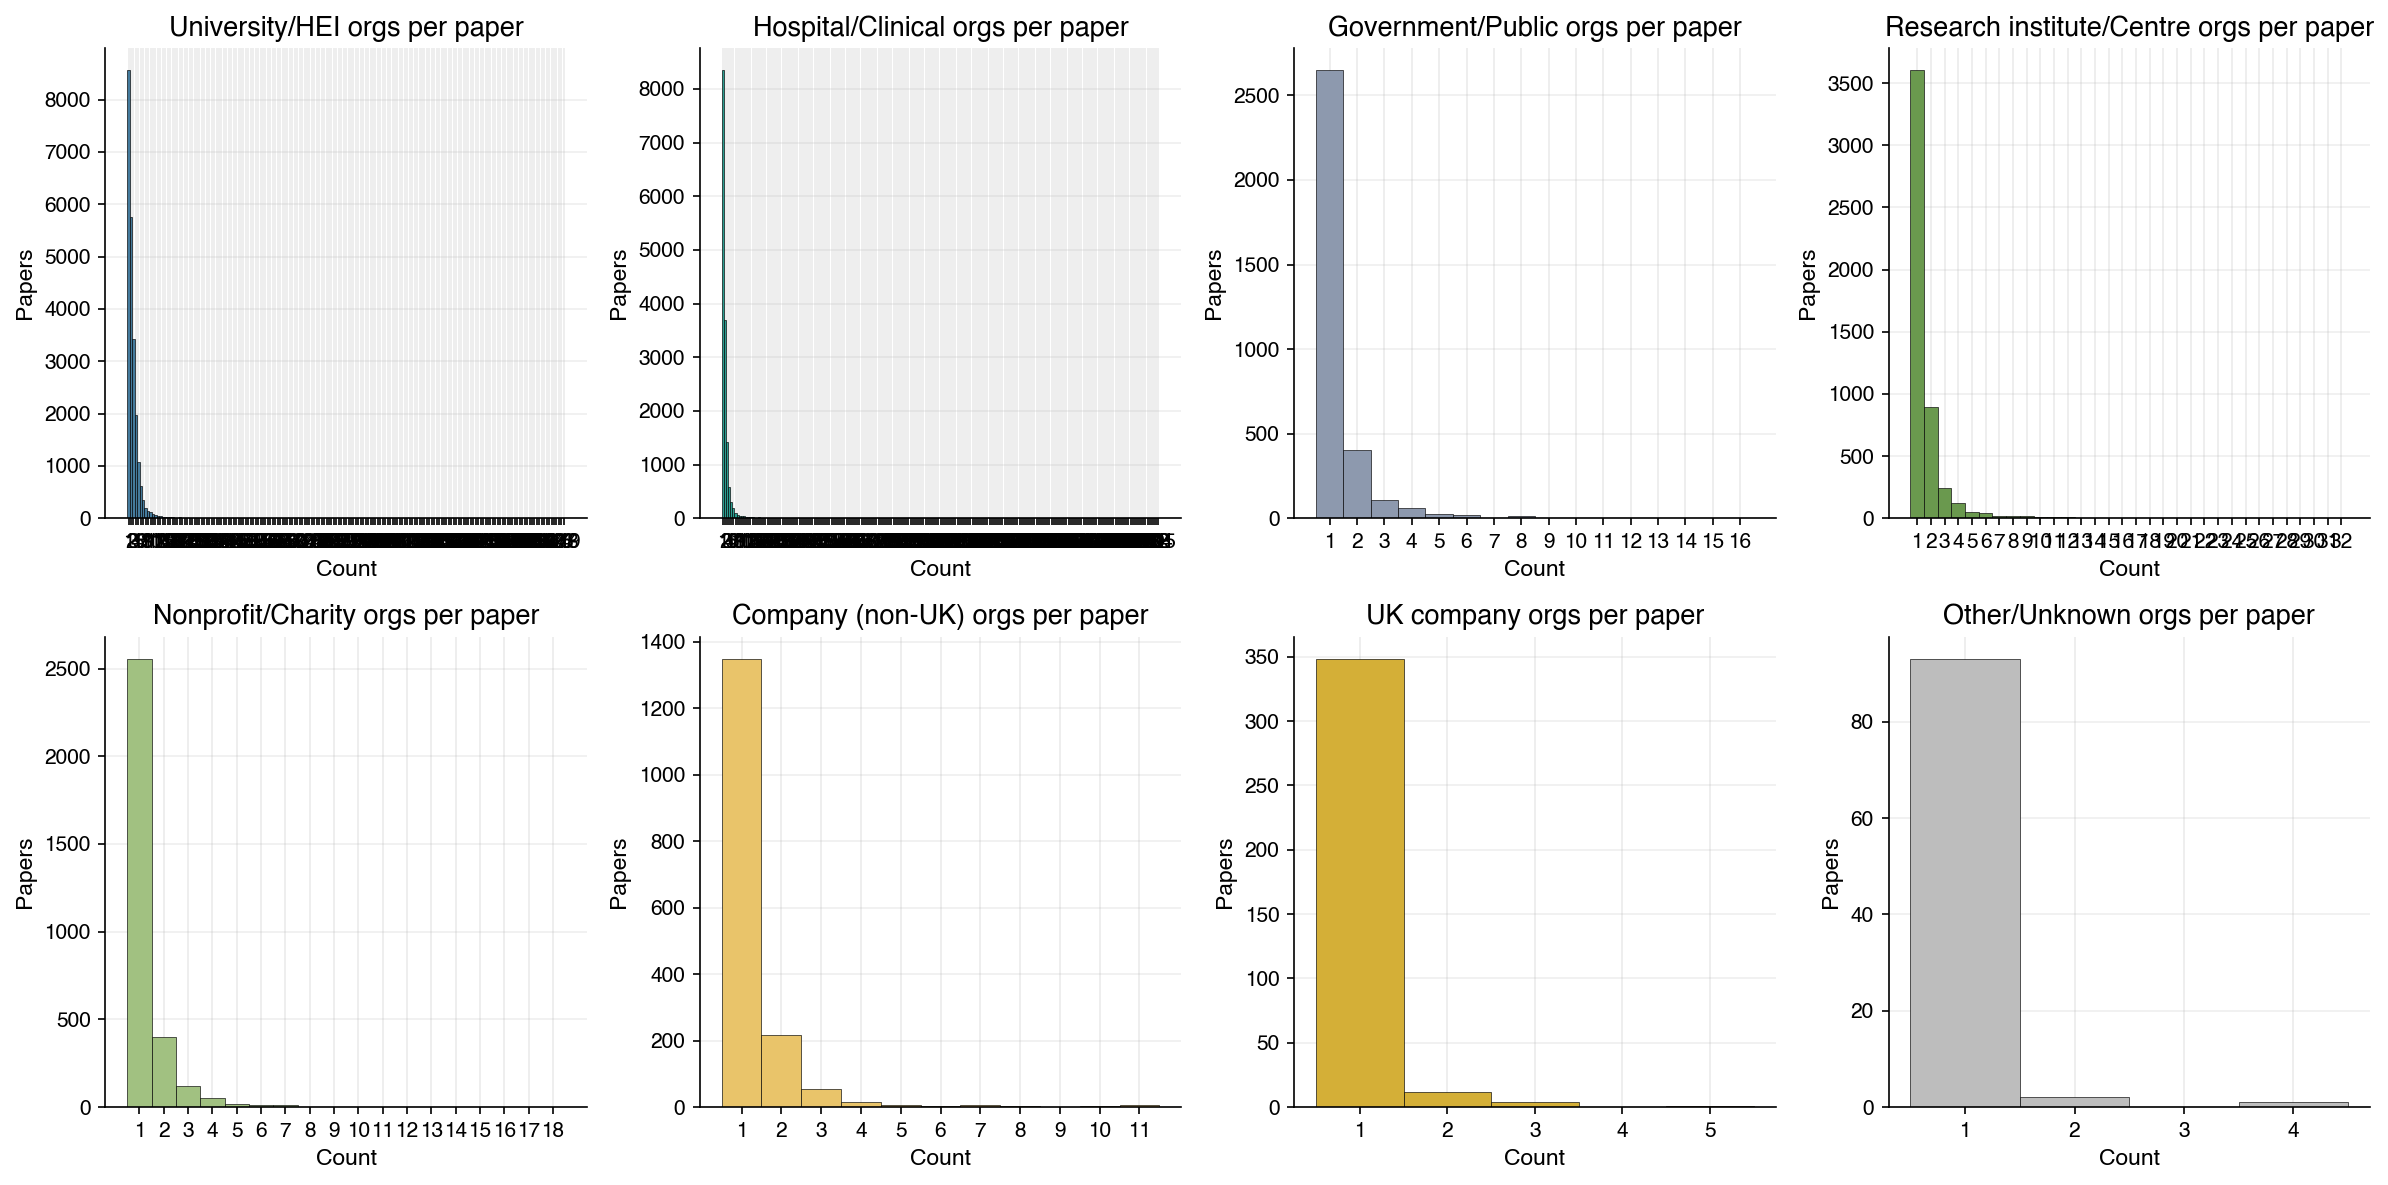

In [6]:
sector_order = [
    "Hospital/Clinical",
    "University/HEI",
    "Government/Public",
    "Research institute/Centre",
    "Nonprofit/Charity",
    "Company (non-UK)",
    "UK company",
    "Other/Unknown",
]
sector_colors = {
    "Hospital/Clinical": "#2A9D8F",
    "University/HEI": "#457B9D",
    "Government/Public": "#8D99AE",
    "Research institute/Centre": "#6A994E",
    "Nonprofit/Charity": "#A1C181",
    "Company (non-UK)": "#5E548E",
    "UK company": "#D4AF37",
    "Other/Unknown": "#BDBDBD",
}

for label in sector_order:
    table = top_sector_tables.get(label, pd.DataFrame())
    print(f"Top {label} collaborators:")
    display(table.head(25))
    if not table.empty:
        h.plot_top_orgs(
            table,
            f"Top {label} collaborators by paper count",
            "Papers",
            label,
            sector_colors.get(label, "#BDBDBD"),
        )

h.plot_collaborator_count_distributions(df)


## 6. Time Trends

Three views are shown:
- cumulative paper counts by taxonomy sector,
- annual share of all papers by taxonomy sector,
- annual share of taxonomy-collaboration papers that include company sectors.

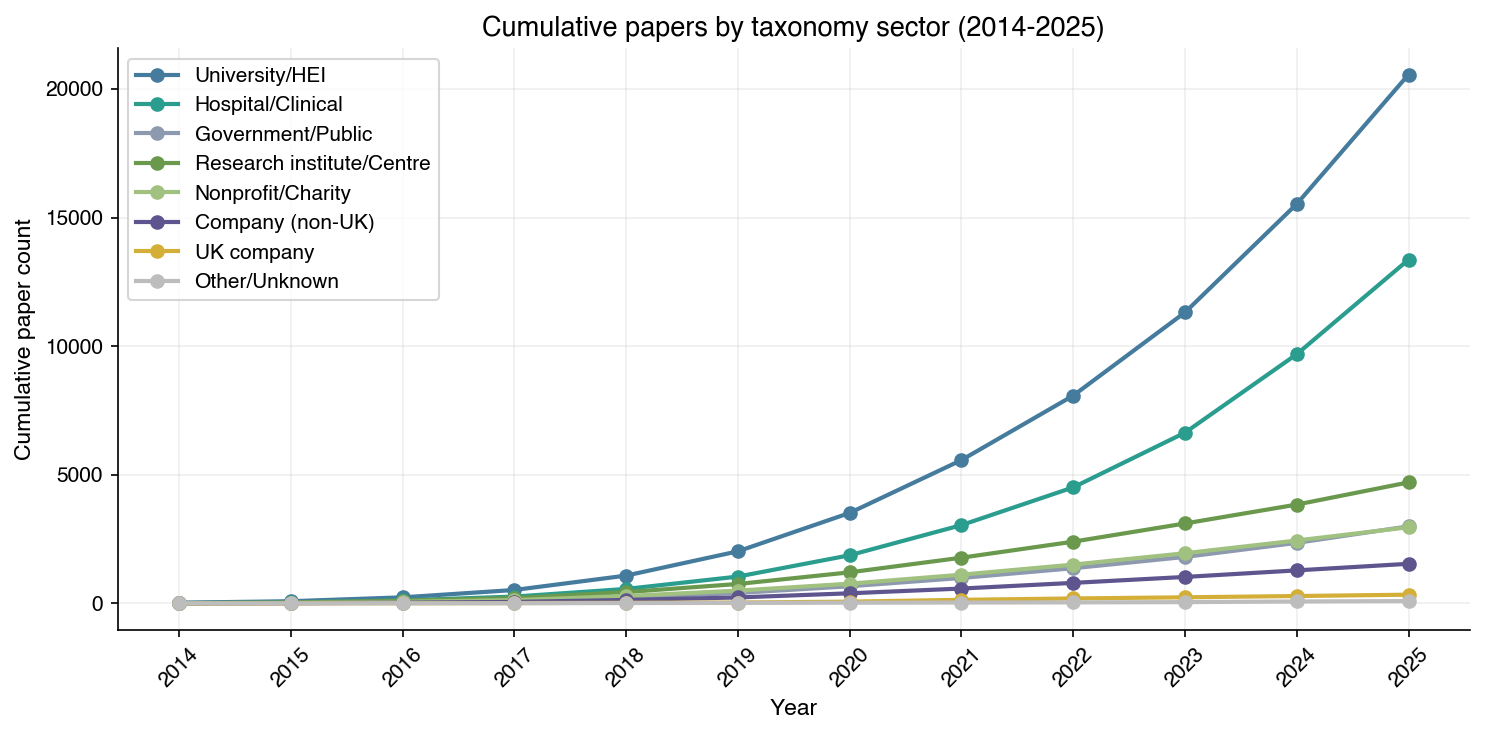

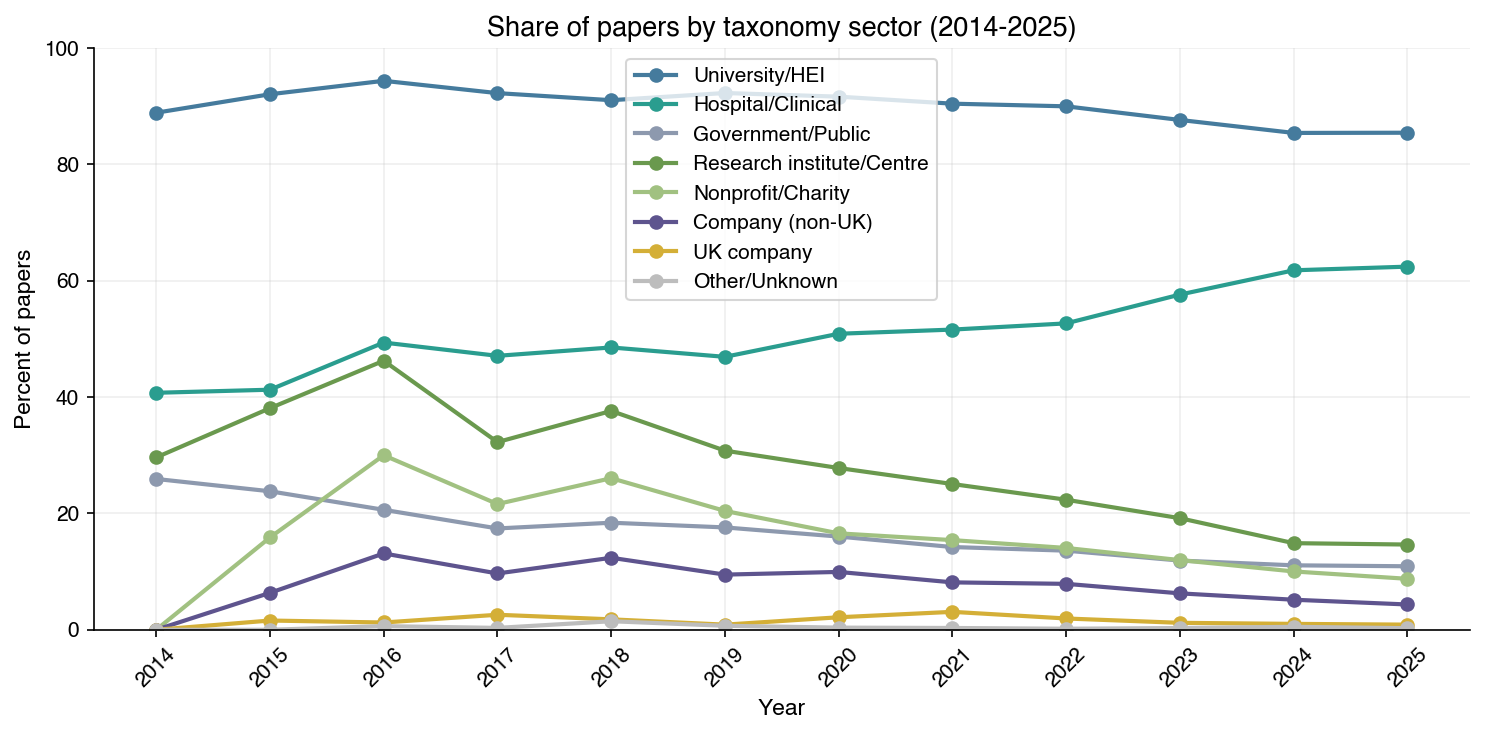

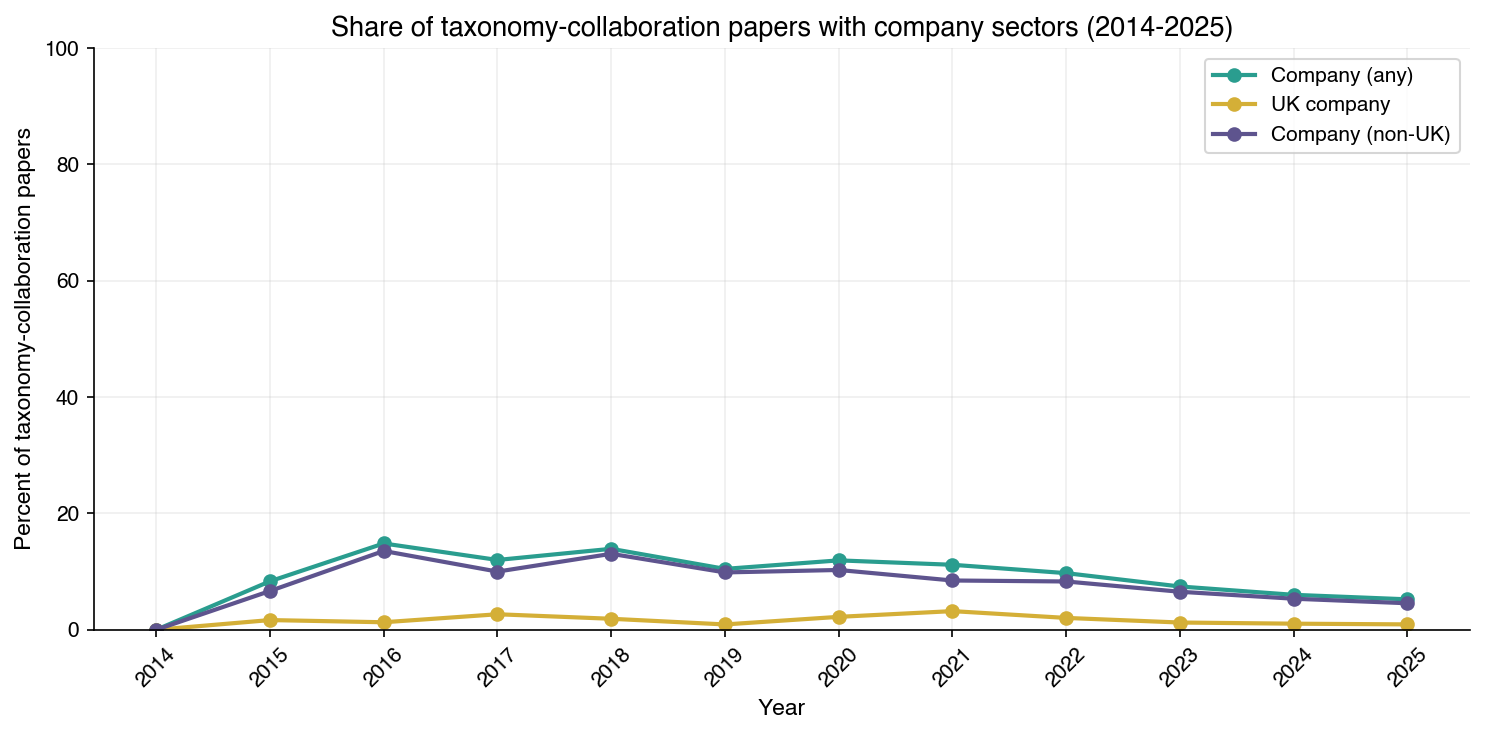

In [7]:
df = h.ensure_year_column(df)

h.plot_cumulative_by_type(df, start_year=2014, end_year=2025)
h.plot_yearly_share_by_type(df, start_year=2014, end_year=2025)
h.plot_company_share_within_non_academic(df, start_year=2014, end_year=2025)


## 7. Additional Publication Figures

These figures summarize taxonomy-sector structure and impact:
- annual primary-sector mix in counts and 100% shares,
- overlap heatmap of taxonomy sector flags,
- citation distributions and yearly median citation trajectories by taxonomy groups,
- collaborator concentration curves,
- top-journal company-sector share comparisons.

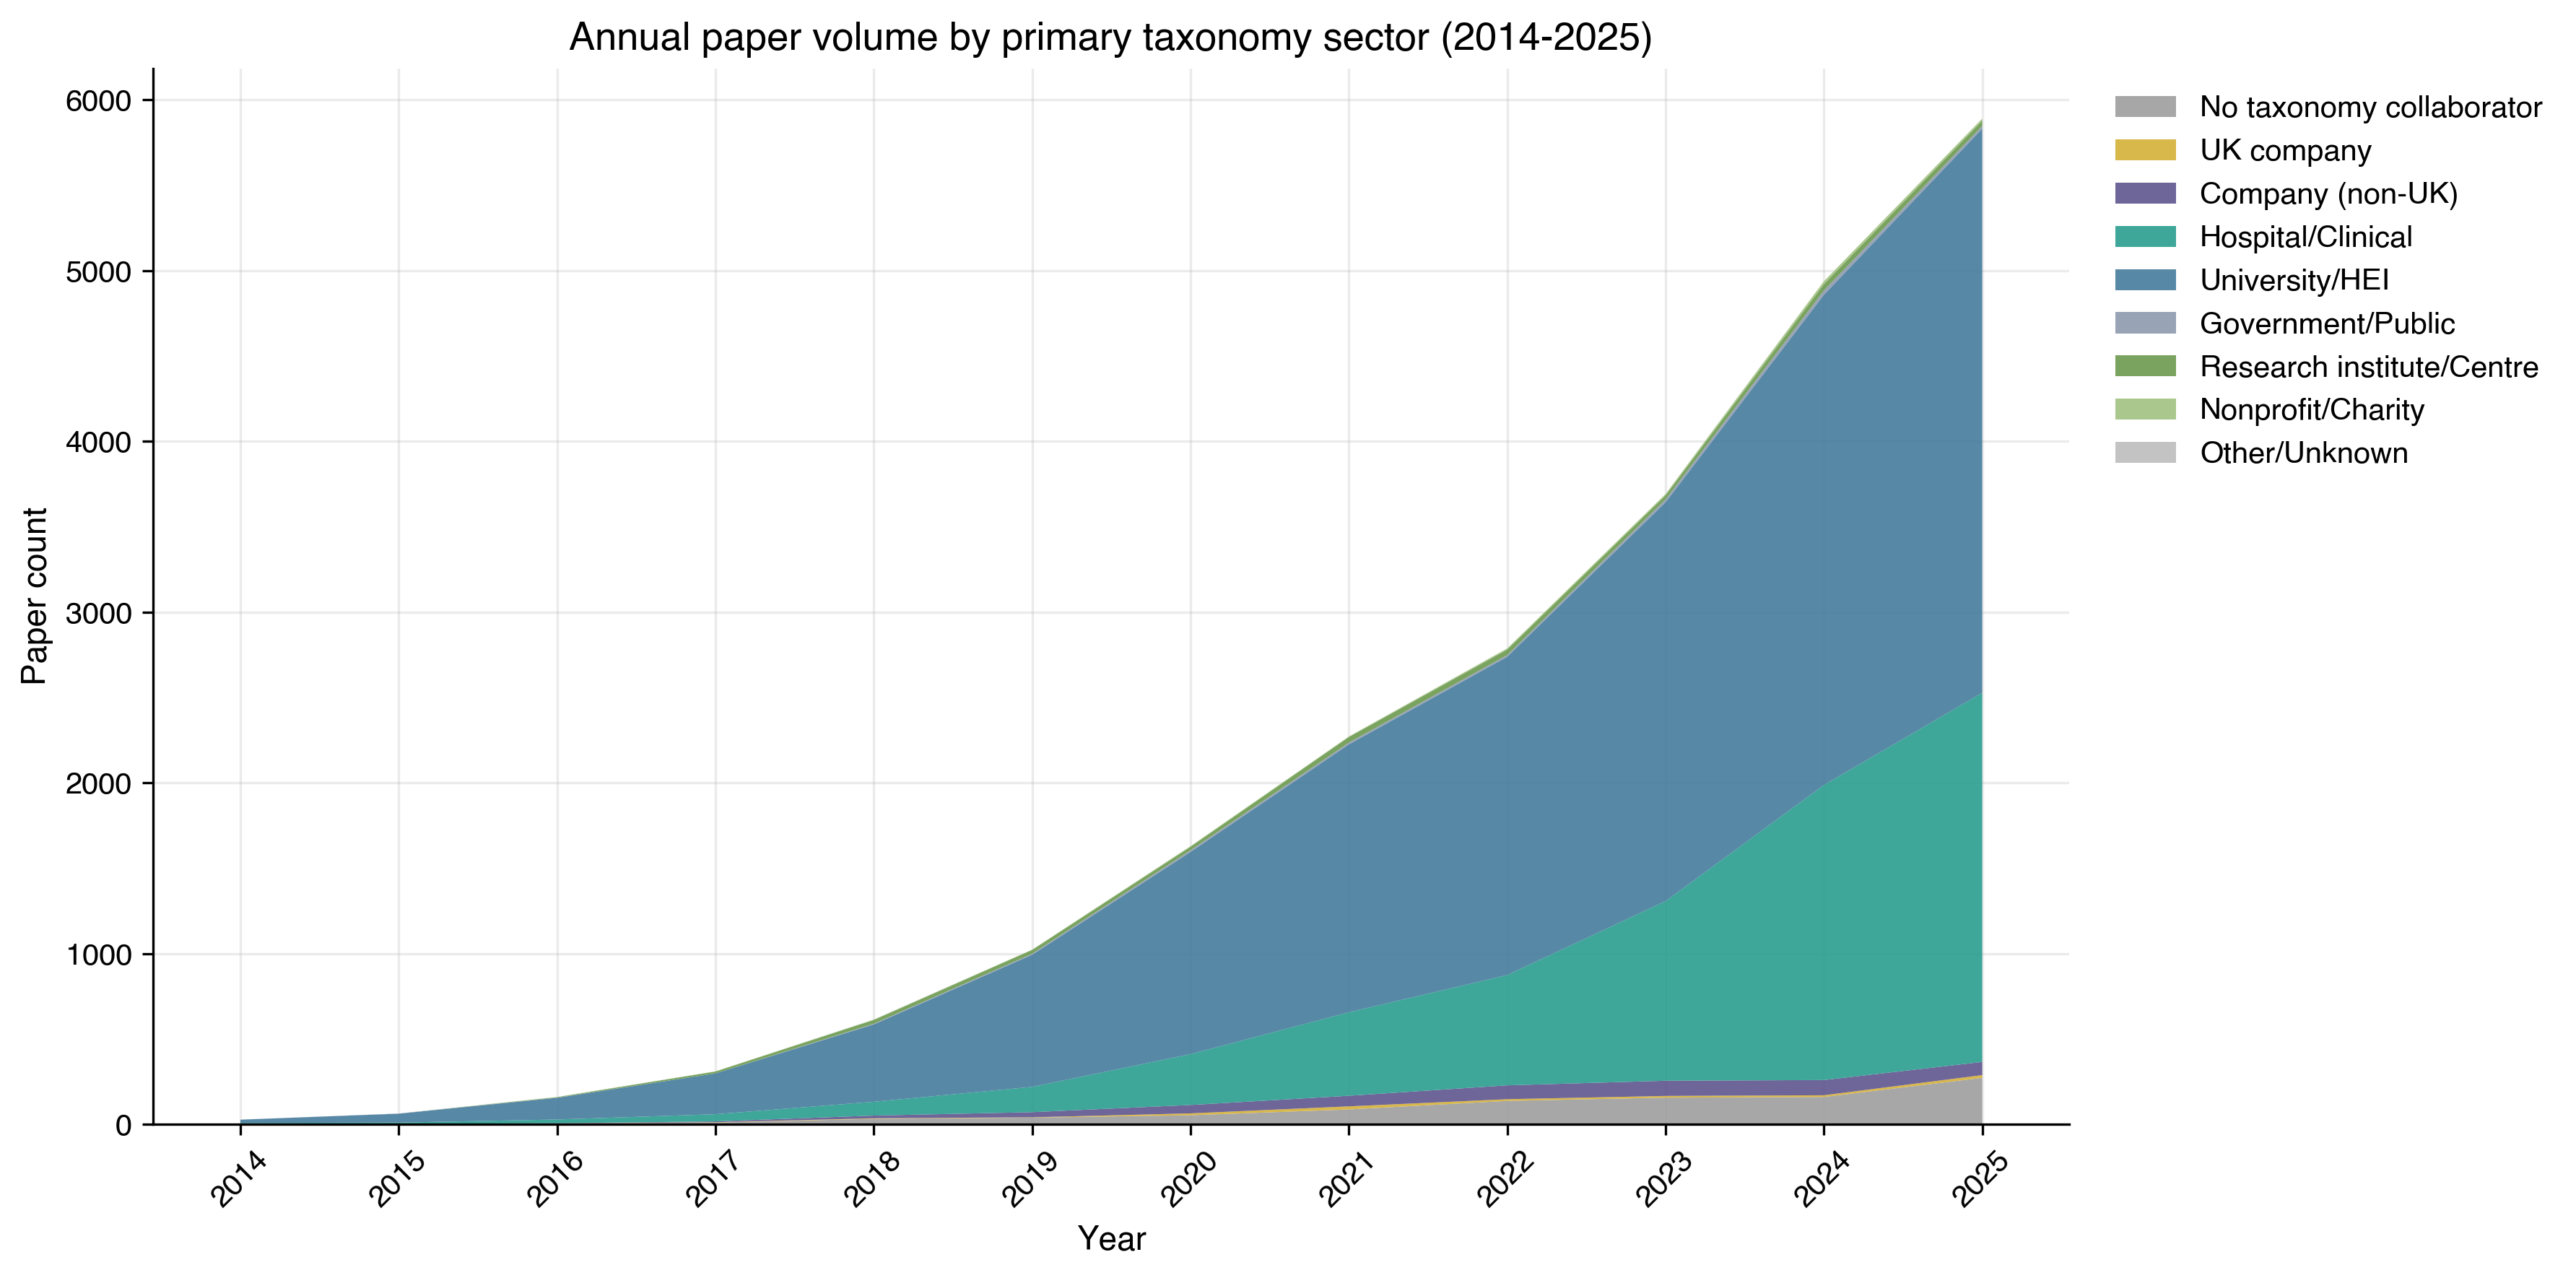

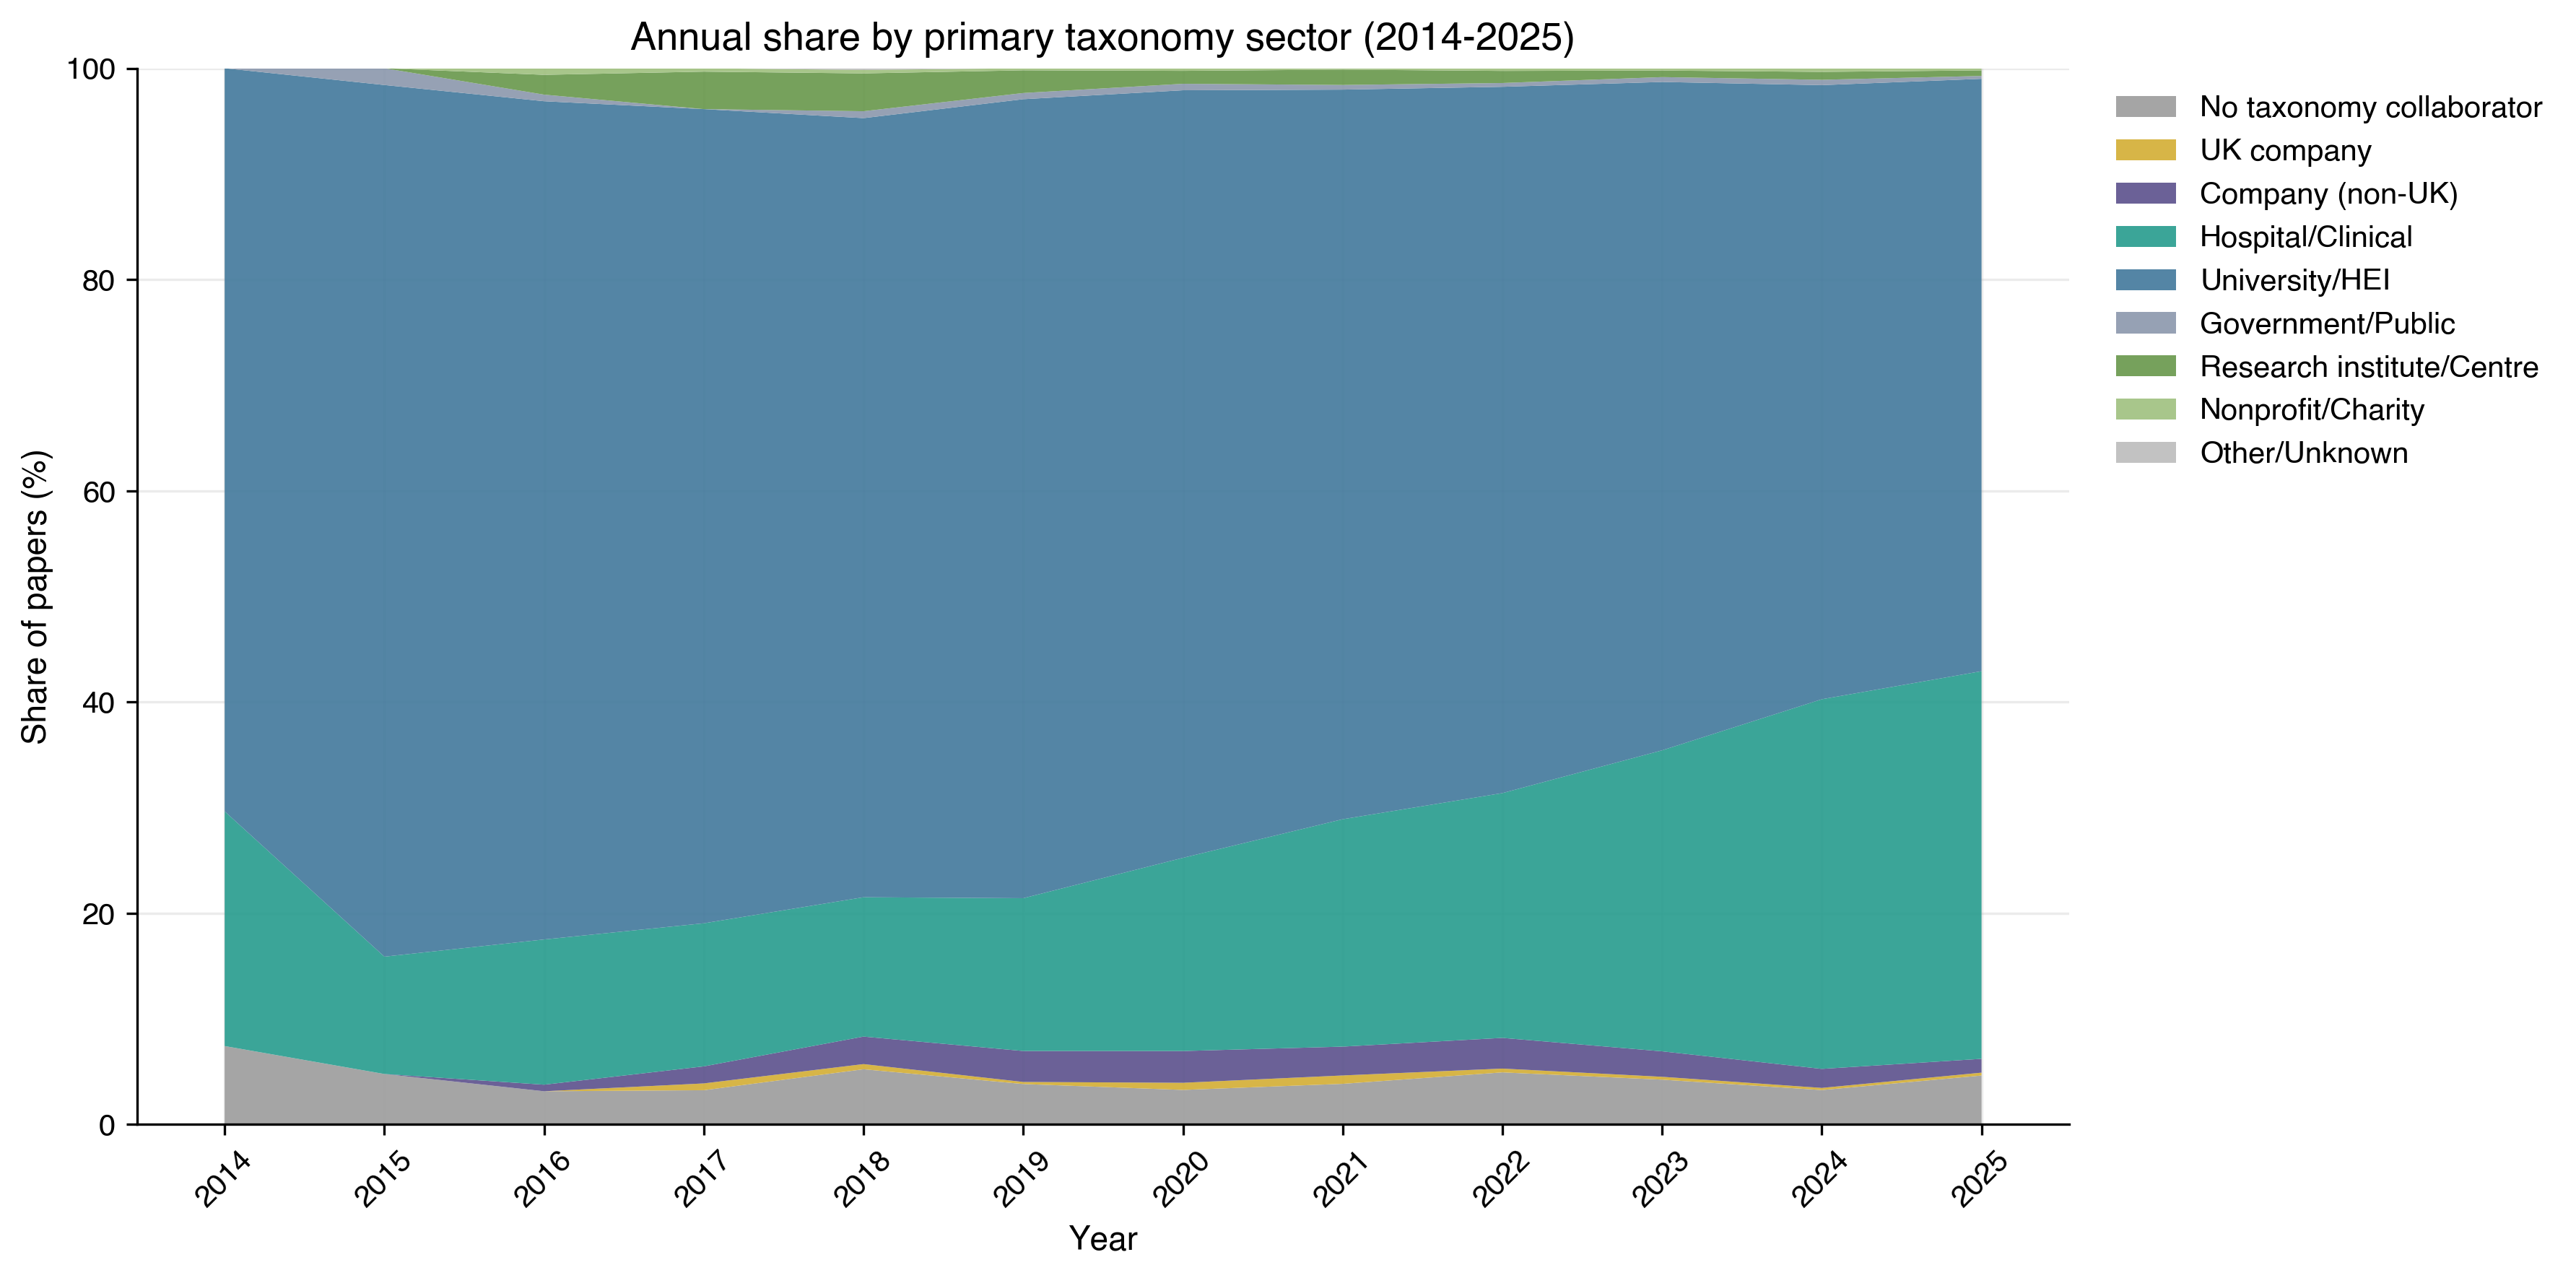

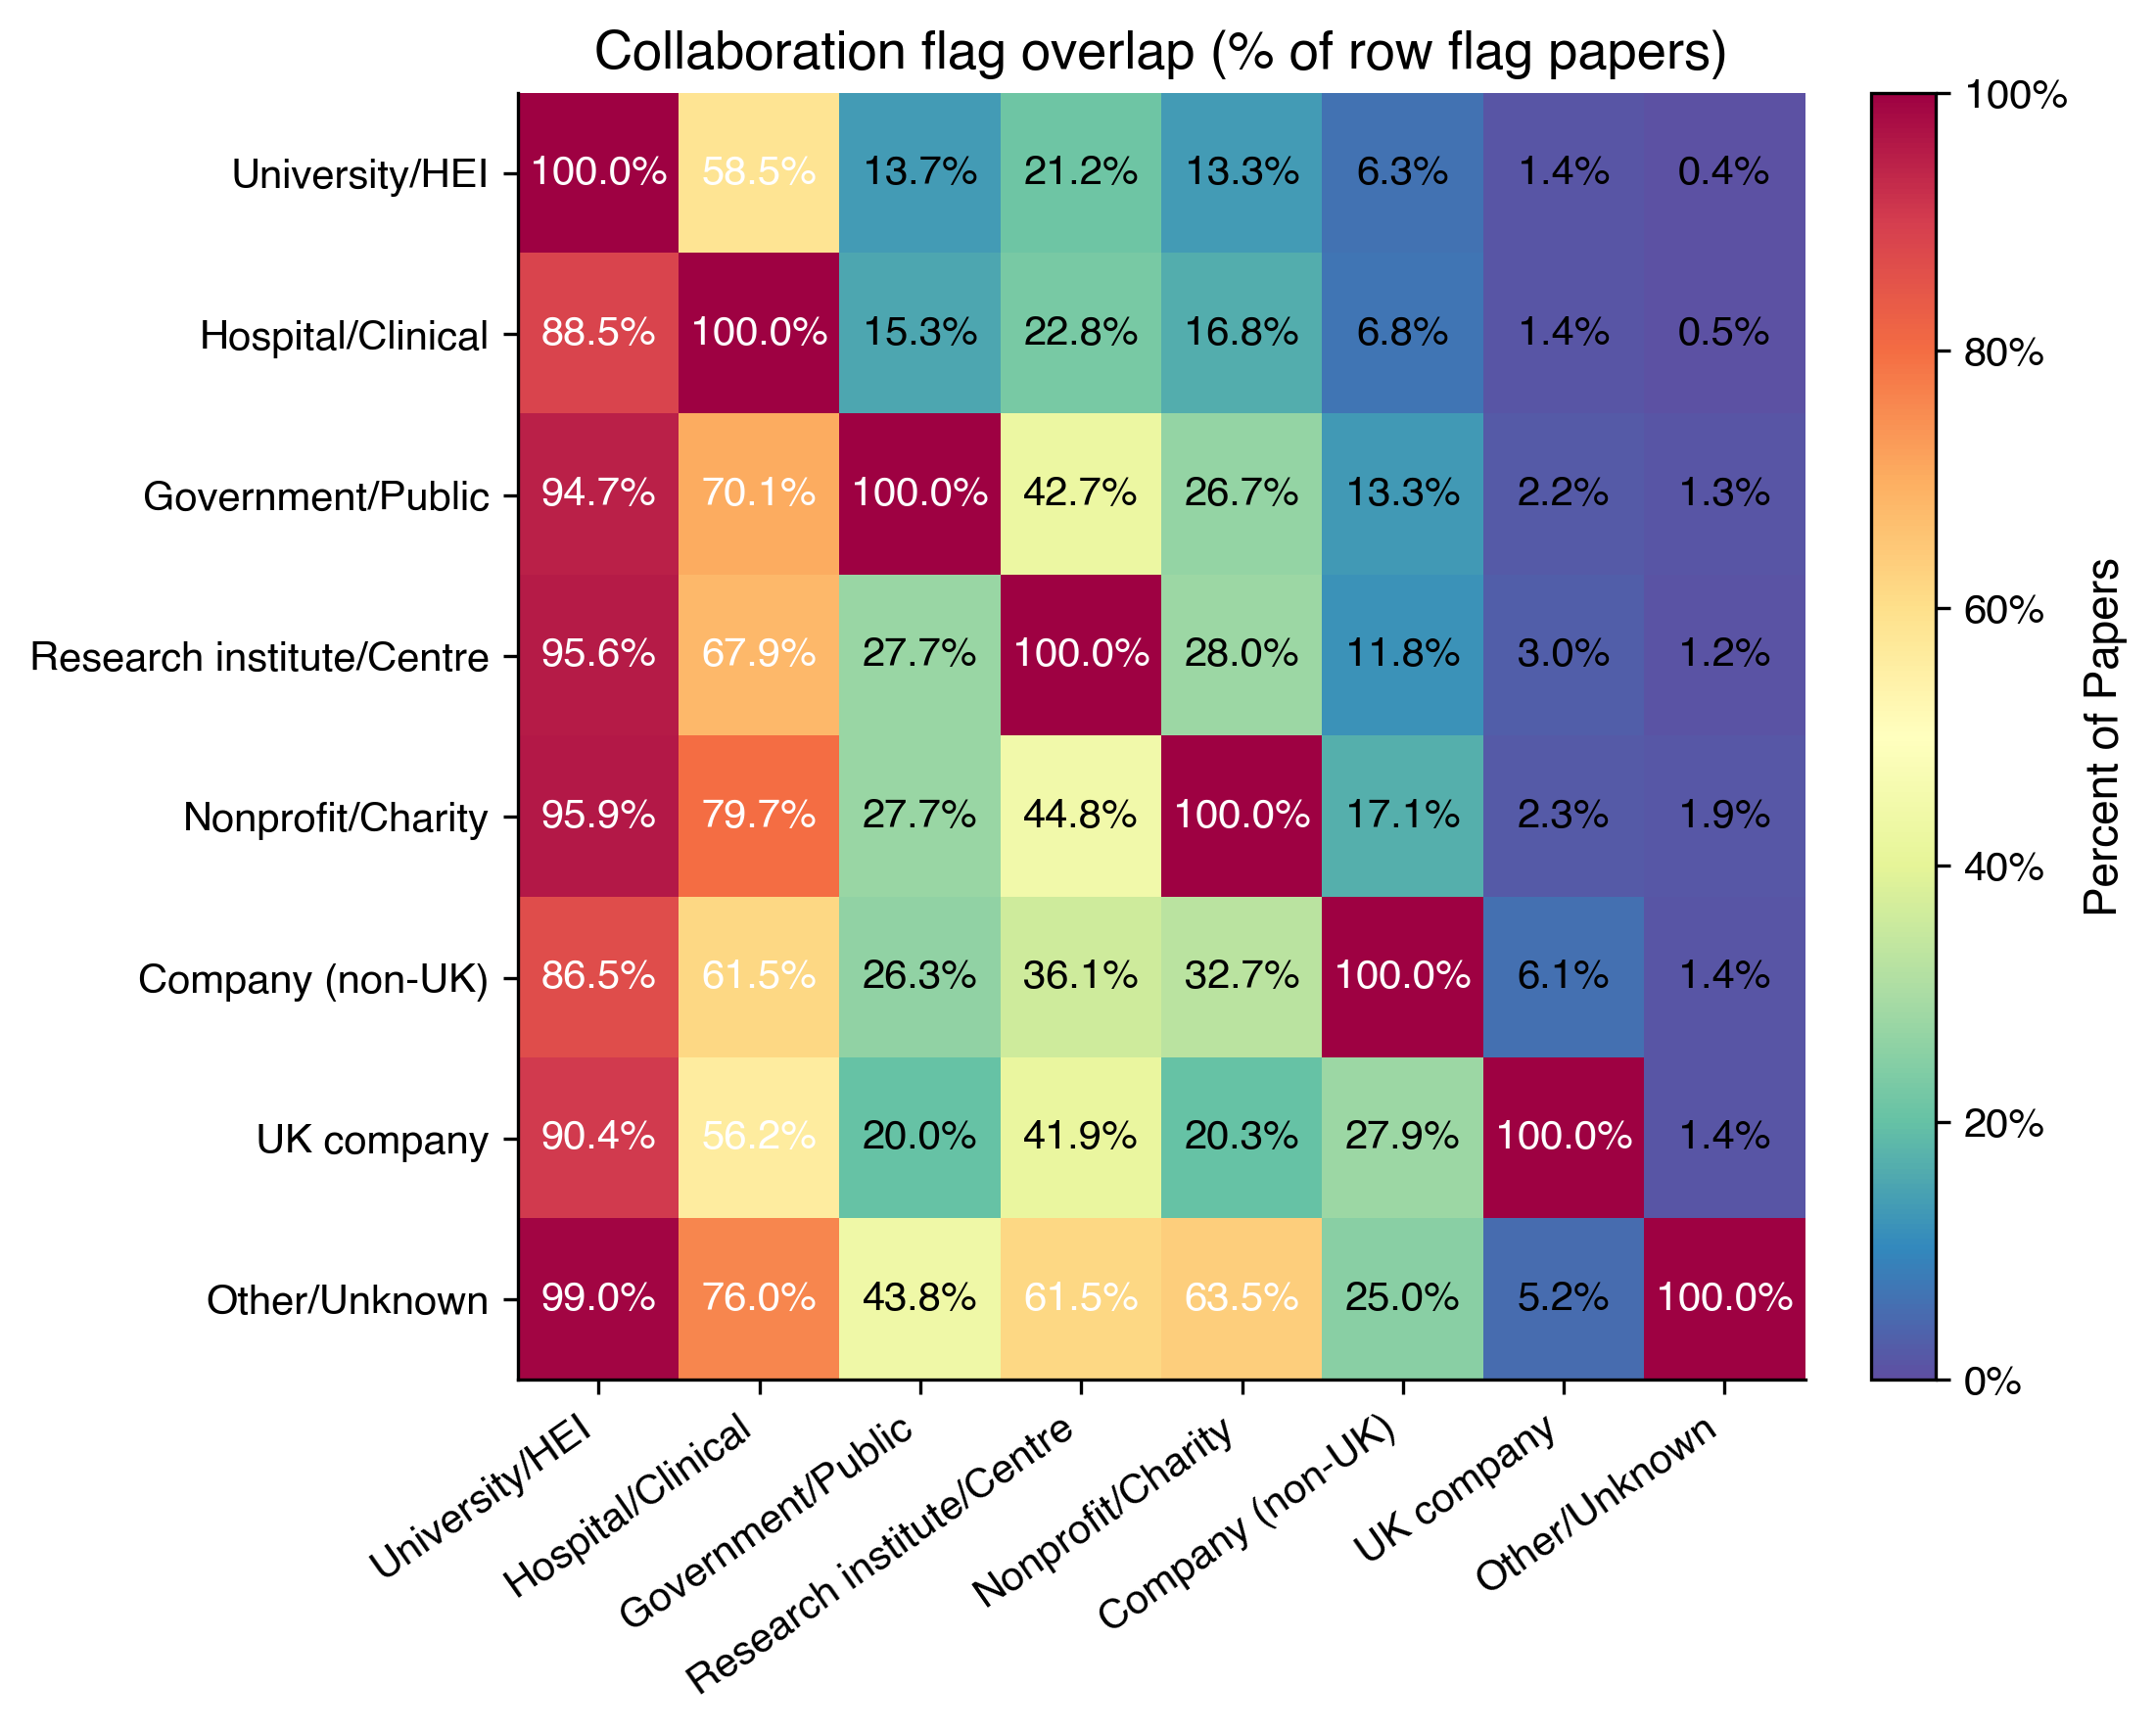

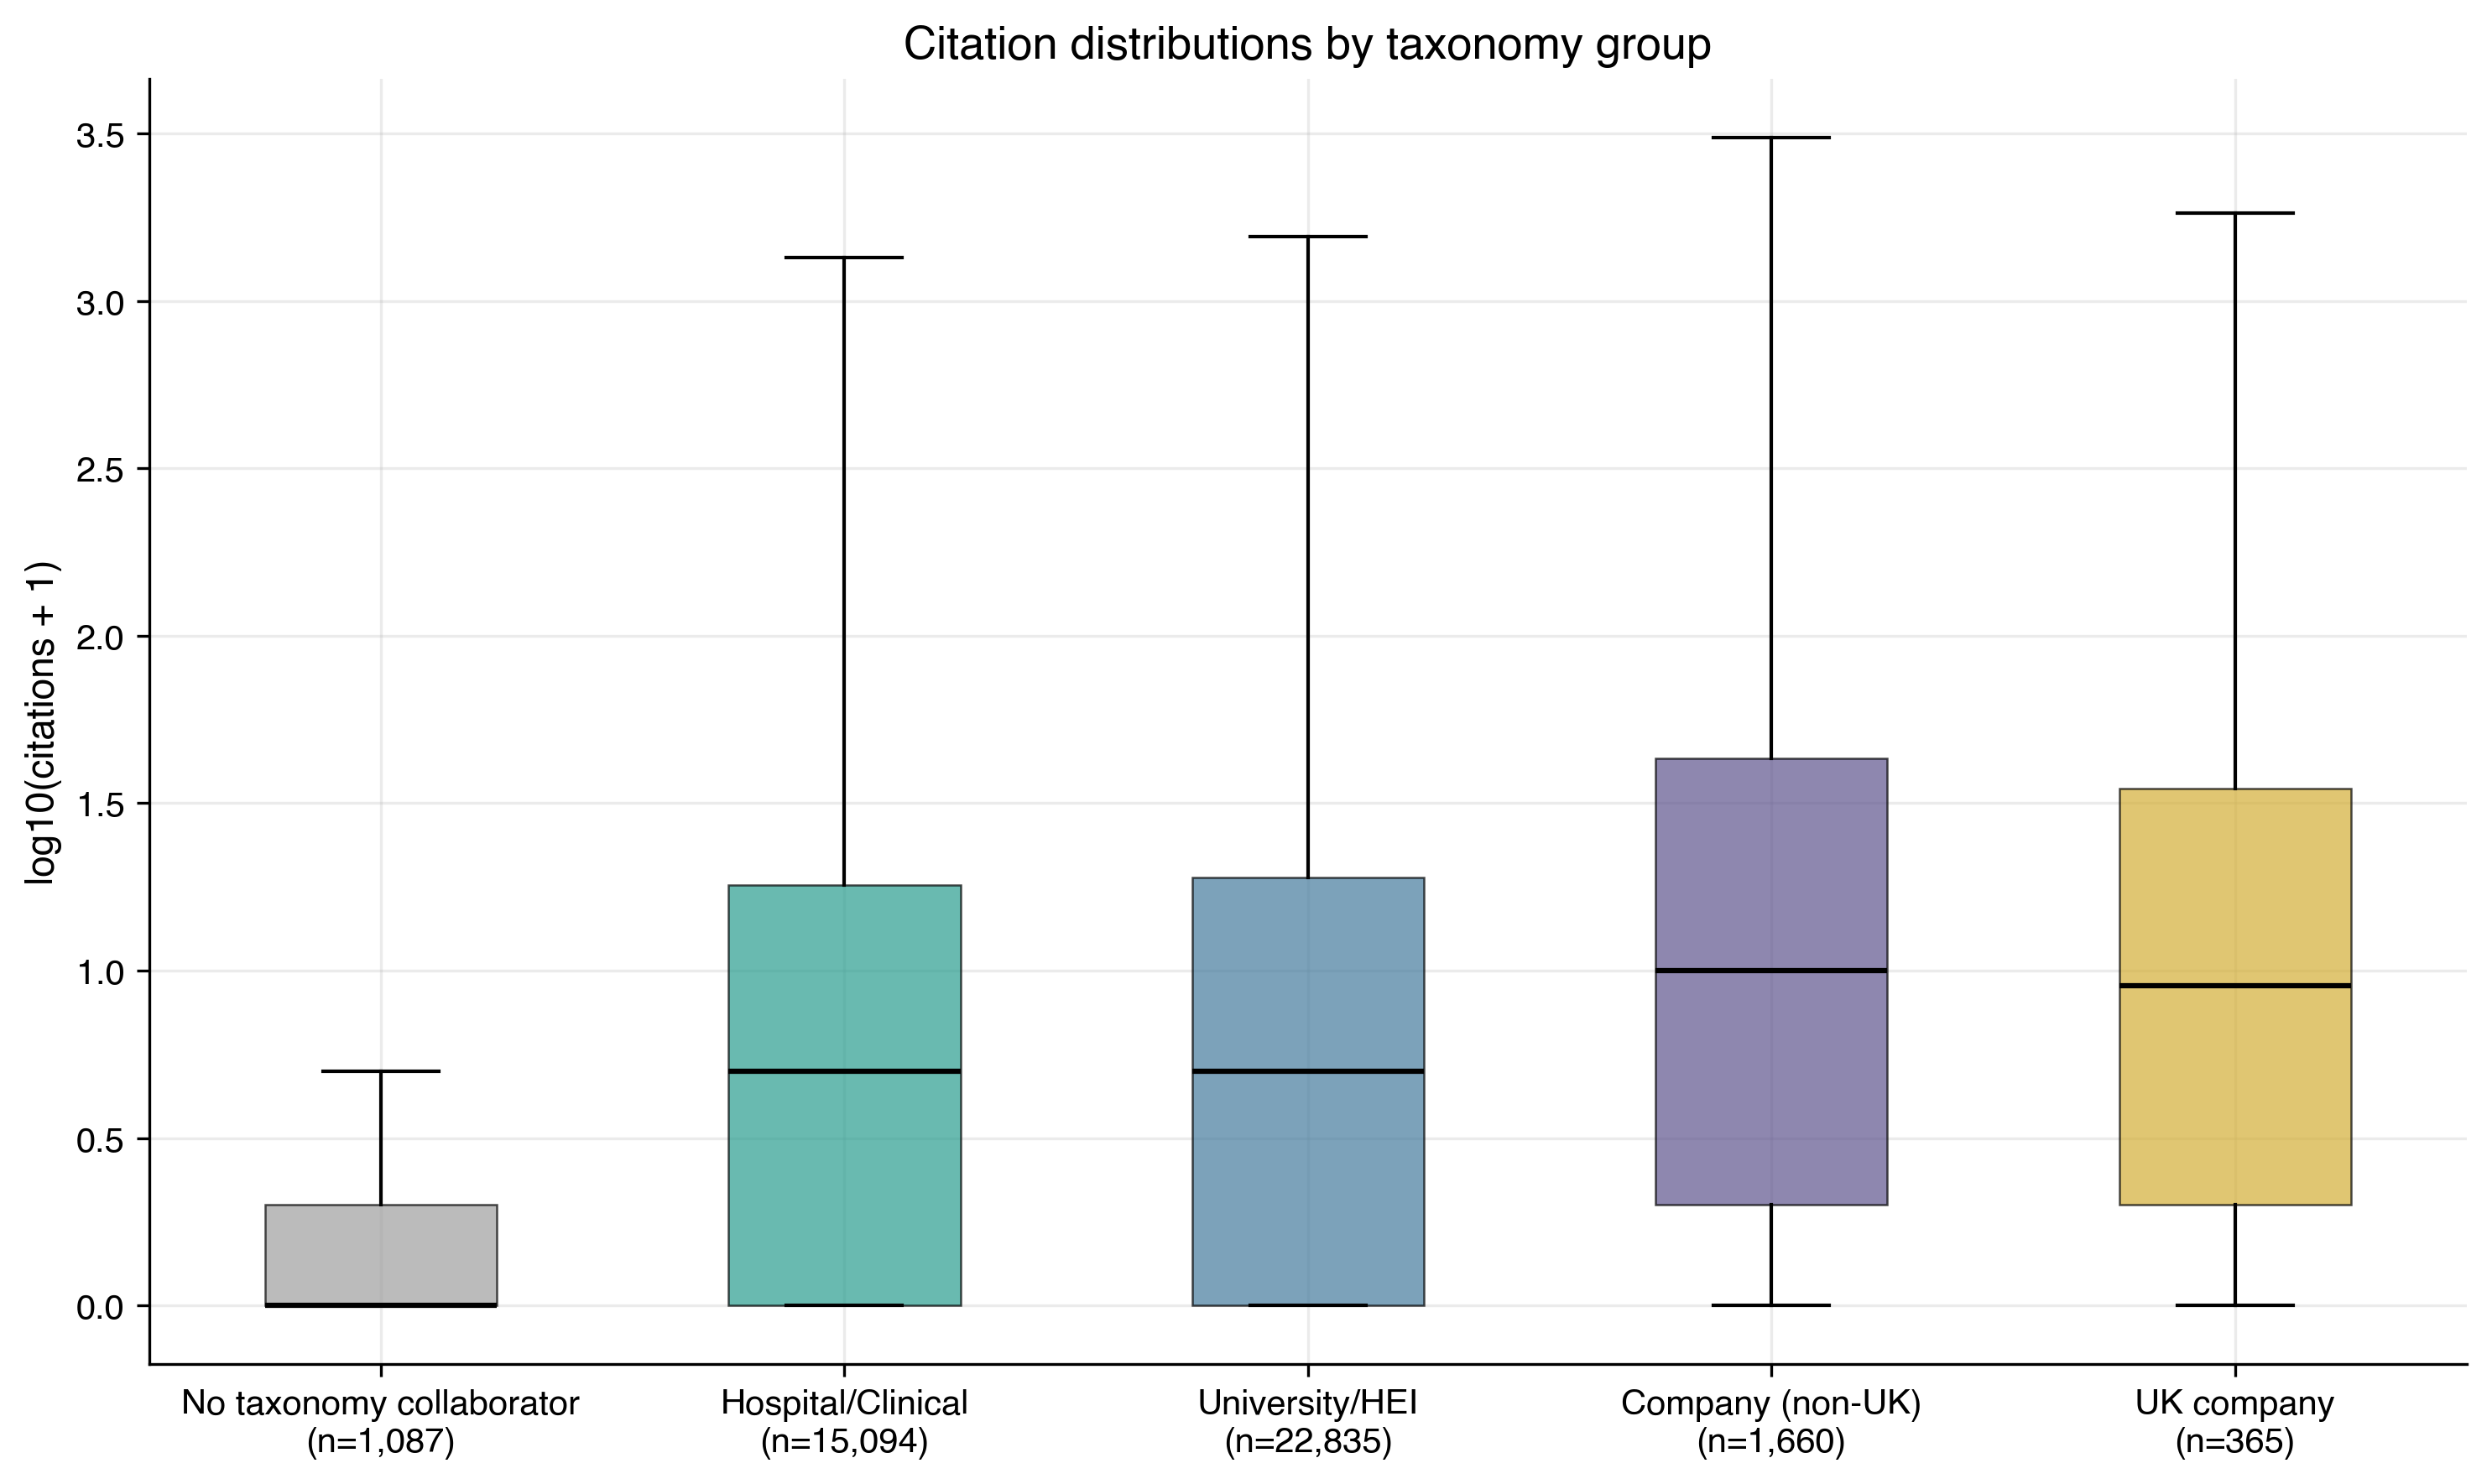

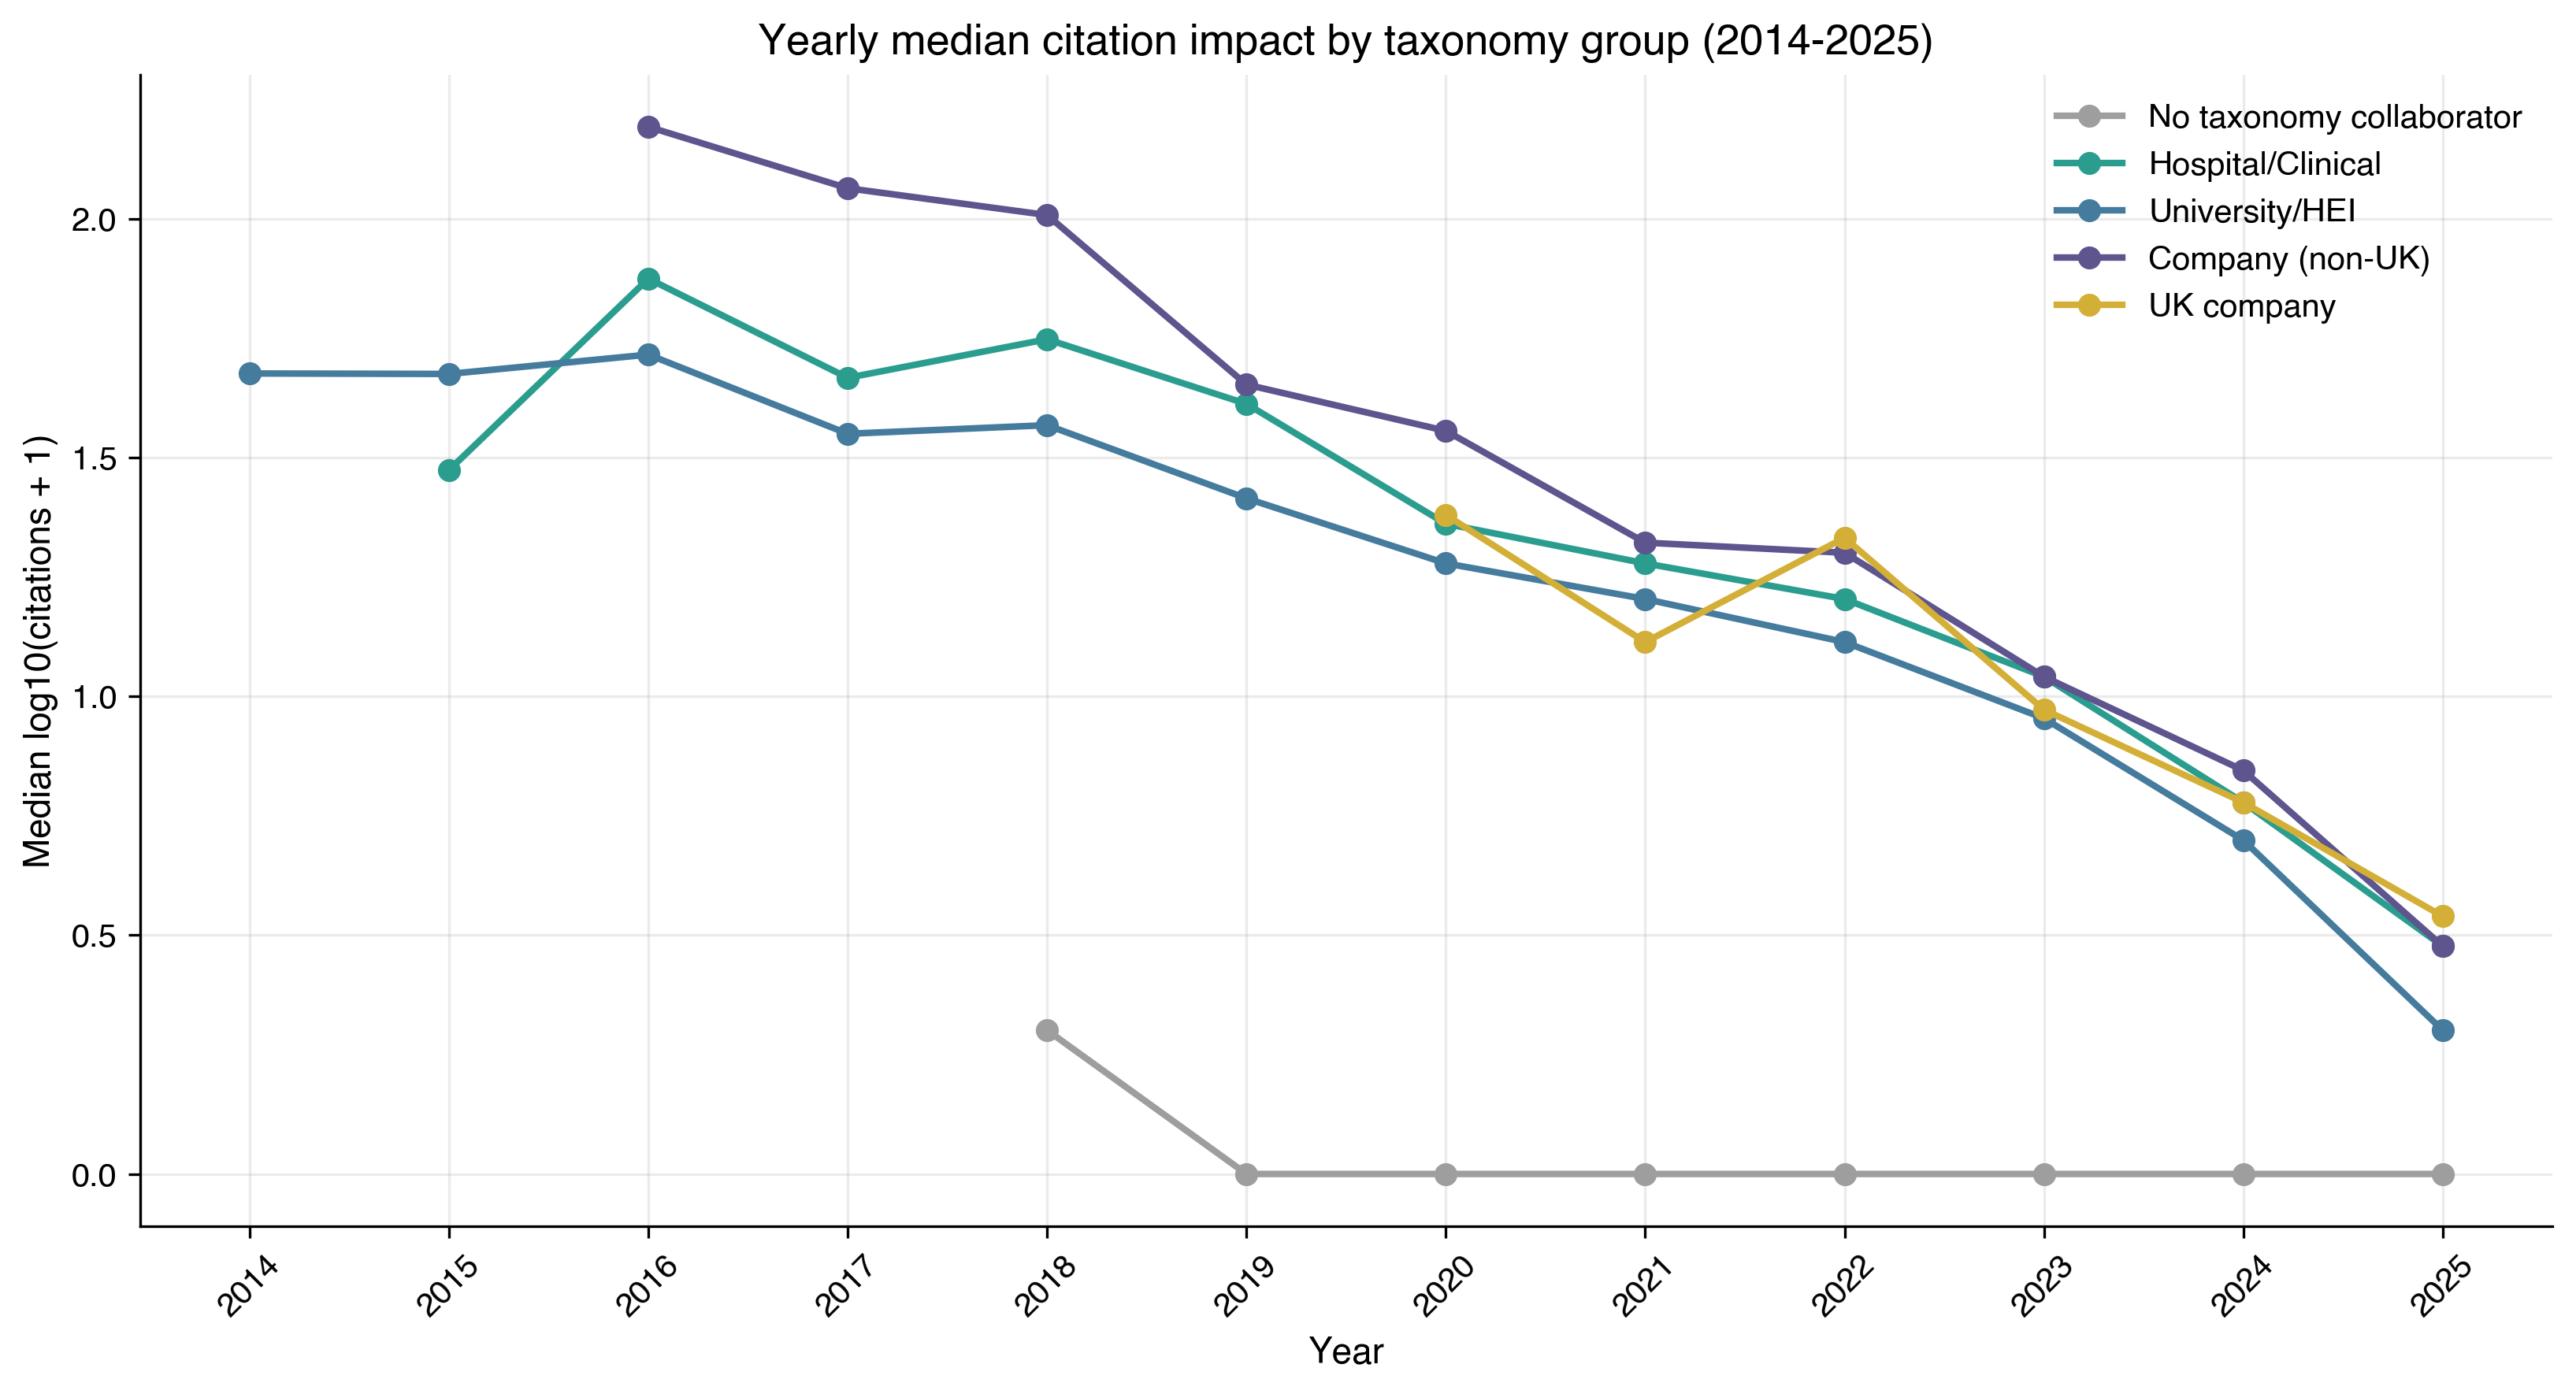

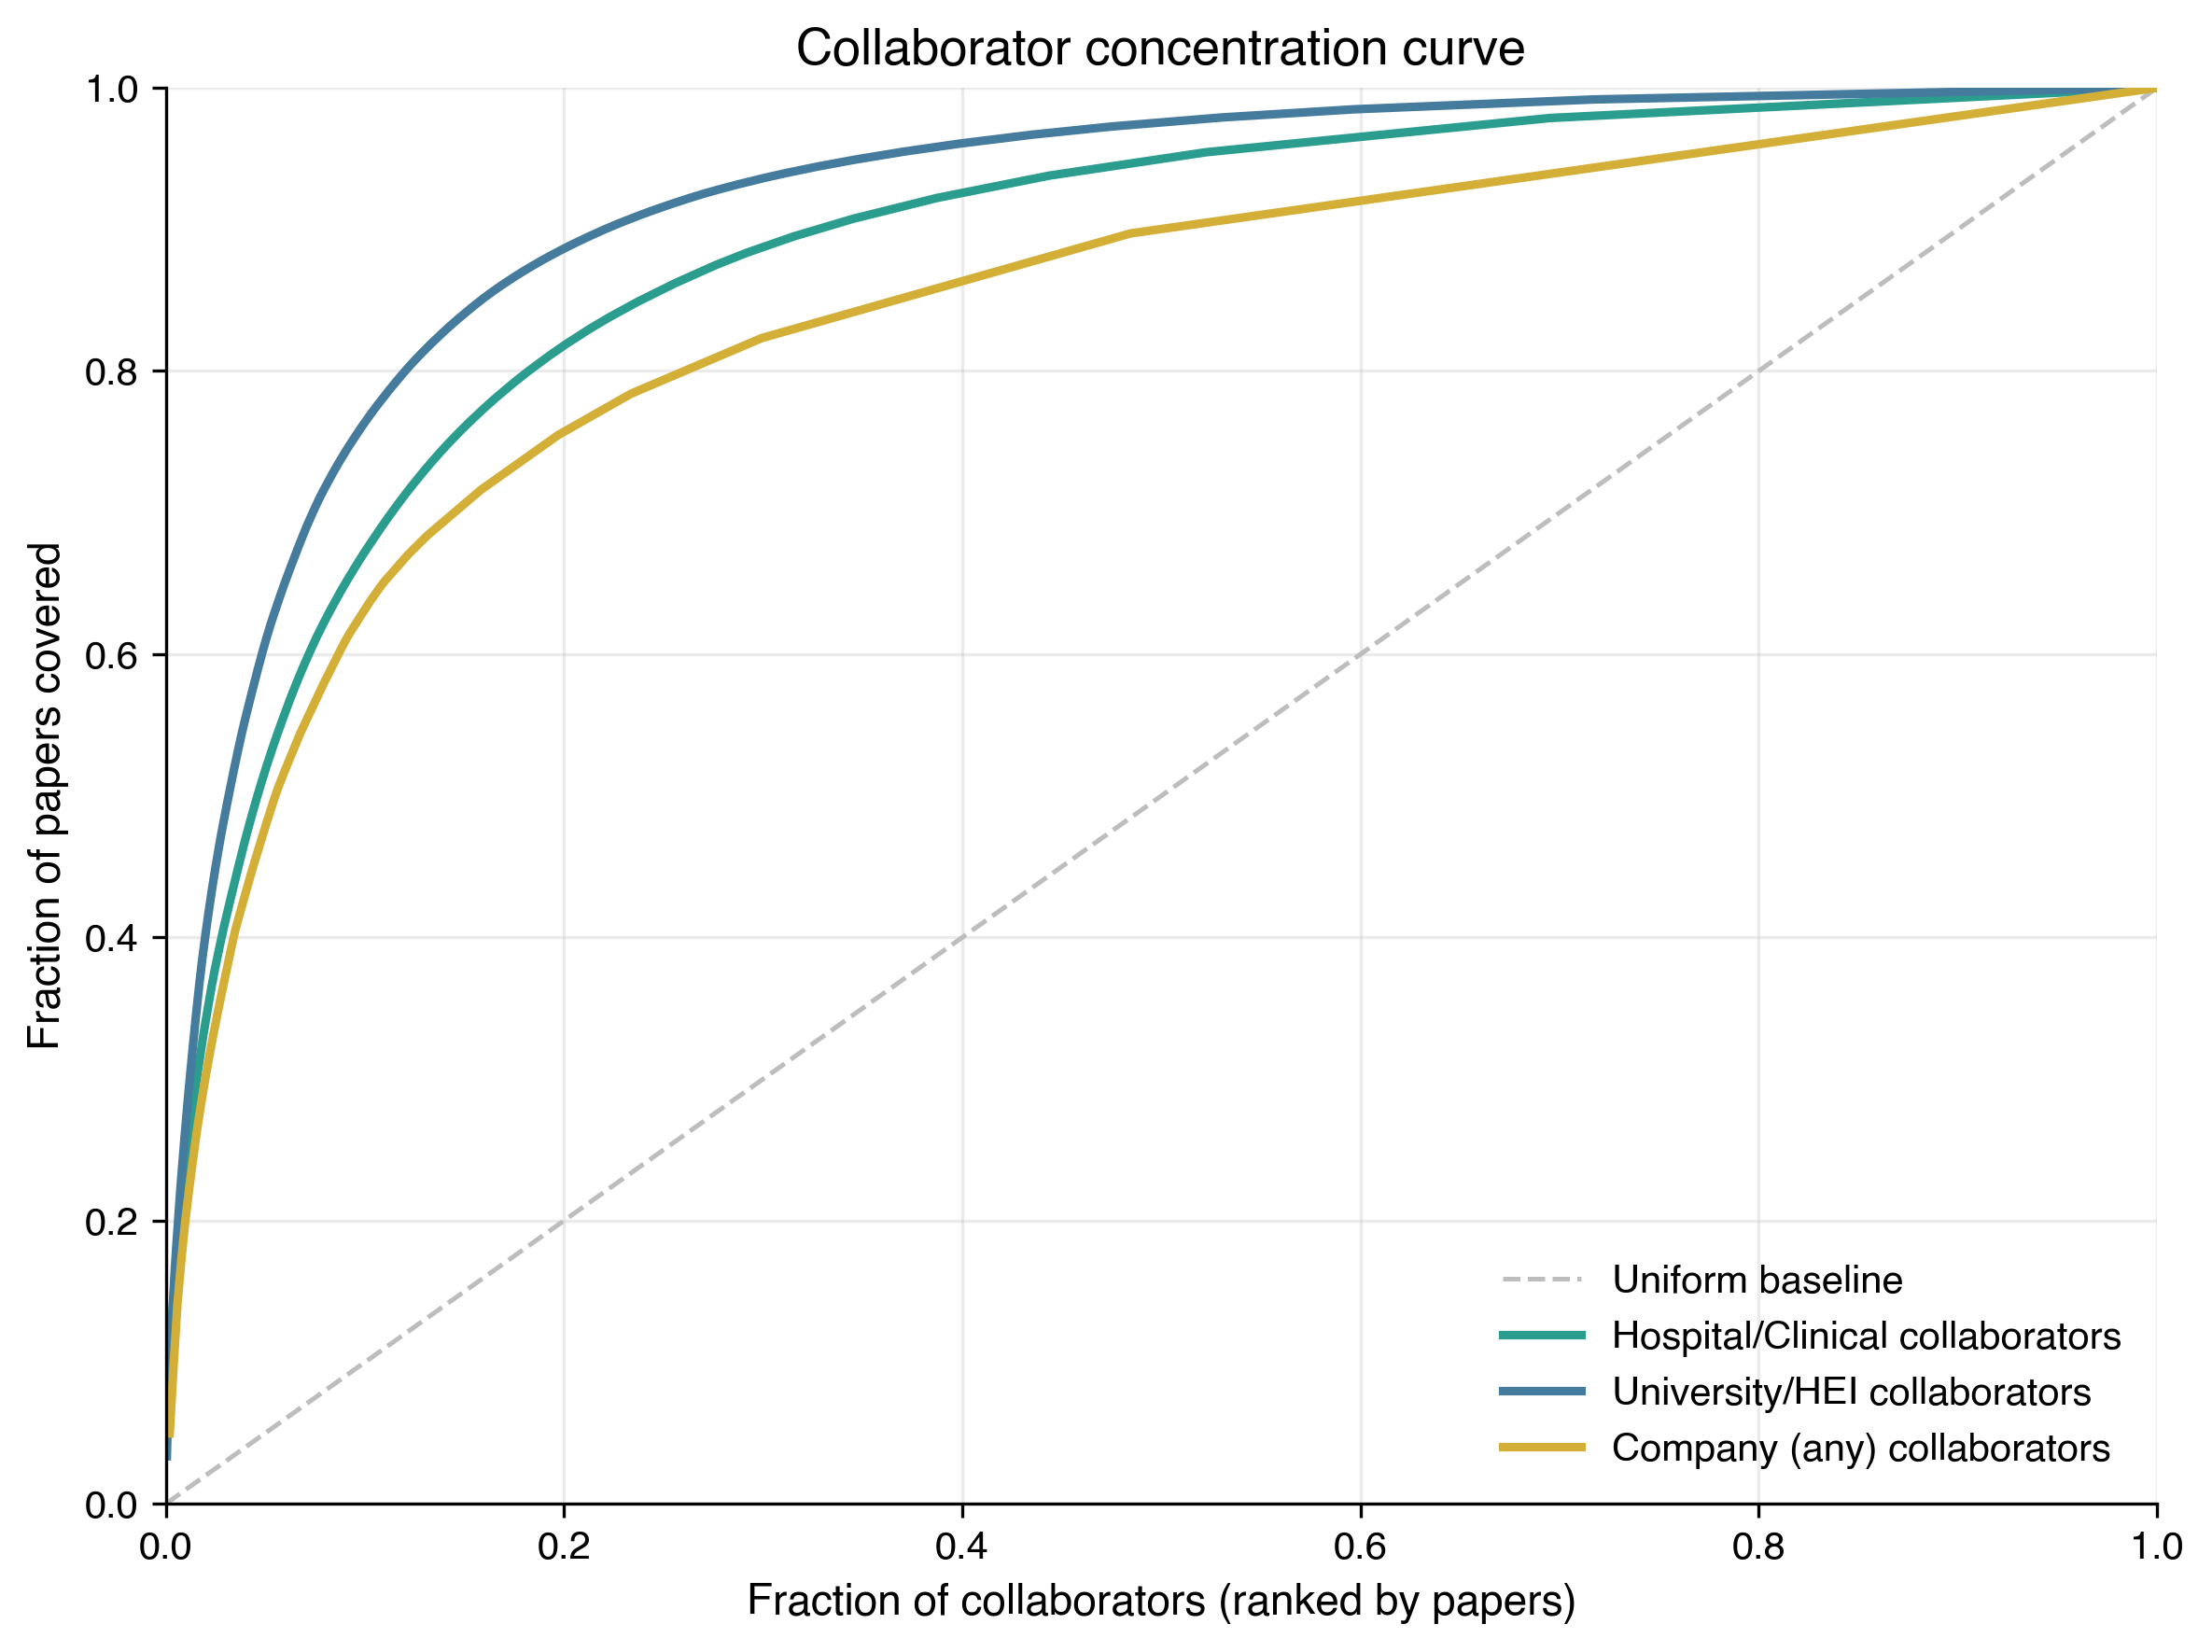

Top journals by paper volume with company-share metrics:


,journal_name,papers,company_papers,uk_company_papers,any_sector_papers,company_share,uk_company_share,any_sector_share
0,medRxiv,2622,318,70,2602,0.121281,0.026697,0.992372
1,bioRxiv,1328,159,29,1314,0.119729,0.021837,0.989458
2,Research Square,786,41,5,764,0.052163,0.006361,0.972010
3,Nature Communications,585,123,18,583,0.210256,0.030769,0.996581
4,Circulation,482,37,2,471,0.076763,0.004149,0.977178
5,Scientific Reports,449,36,5,444,0.080178,0.011136,0.988864
6,Alzheimer's & Dementia,409,7,2,405,0.017115,0.004890,0.990220
7,arXiv,378,0,0,0,0.000000,0.000000,0.000000
8,European Heart Journal,357,21,5,352,0.058824,0.014006,0.985994
9,BMC Medicine,287,6,1,287,0.020906,0.003484,1.000000


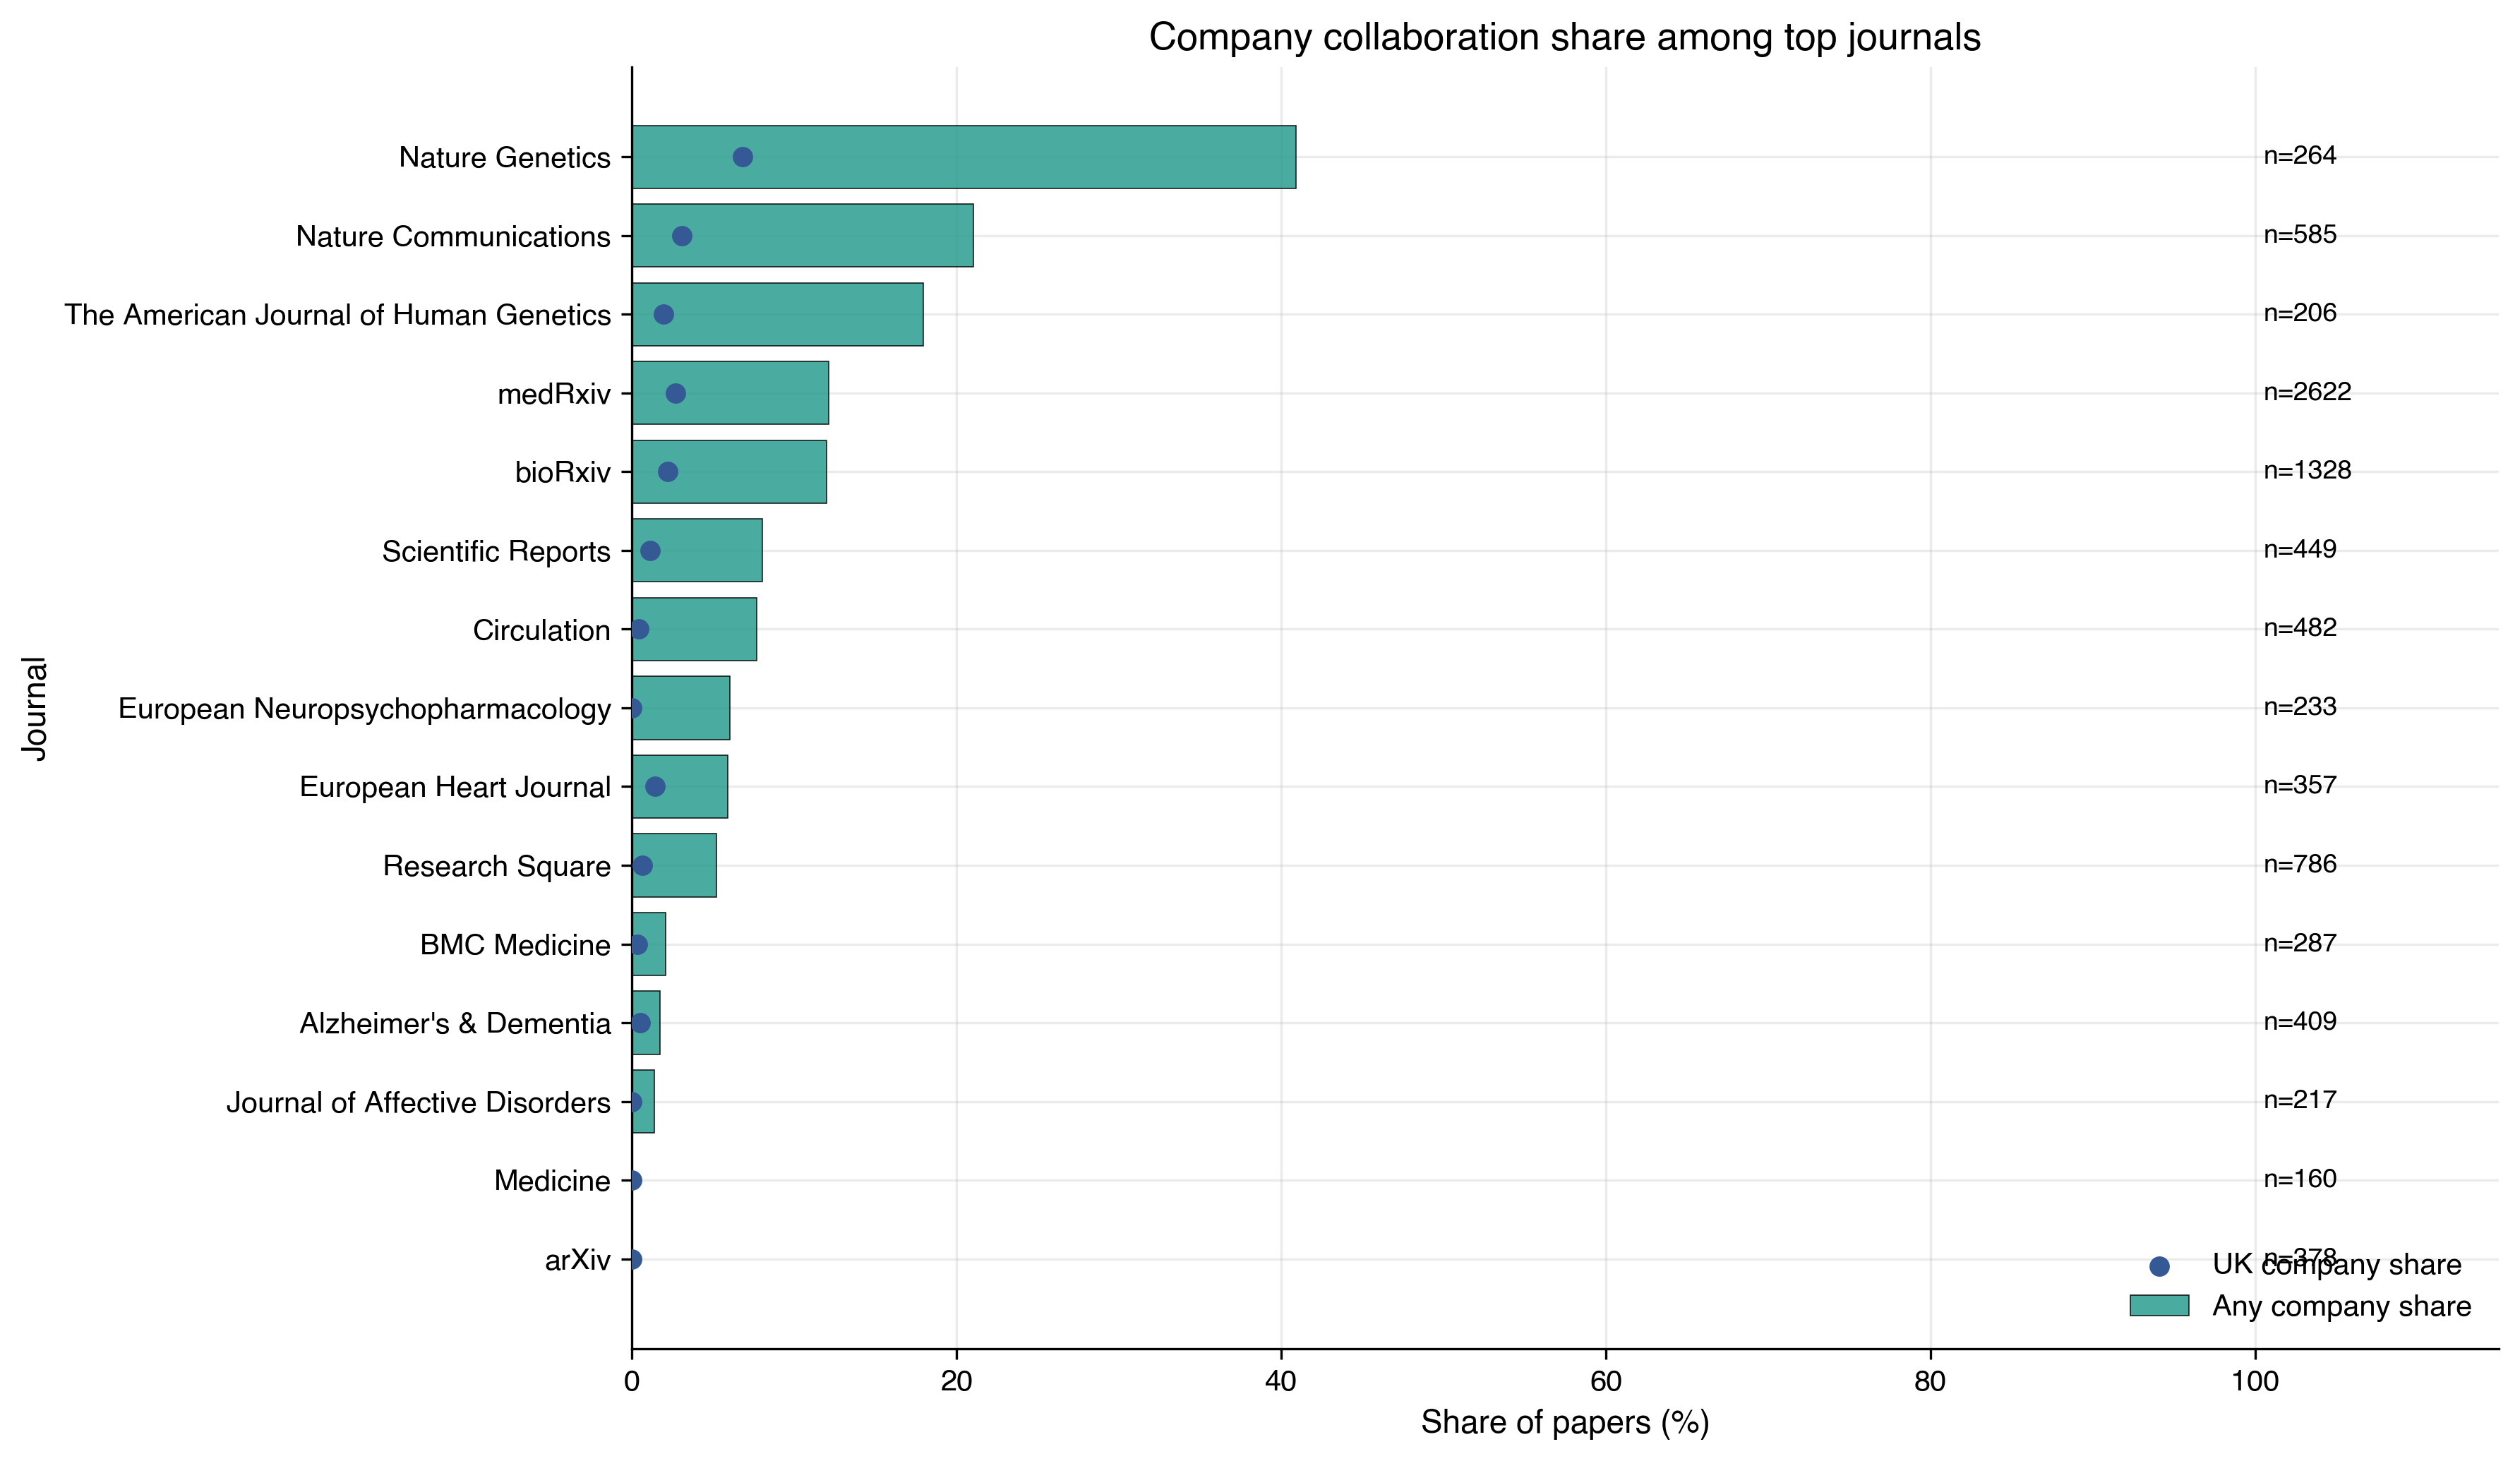

In [8]:
h.plot_collaboration_mix_stacked_area(df, start_year=2014, end_year=2025)
h.plot_collaboration_mix_share_stacked_area(df, start_year=2014, end_year=2025)
h.plot_flag_overlap_heatmap(df)
h.plot_citation_distribution_by_group(df, citation_col="times_cited")
h.plot_yearly_median_log_citations_by_group(
    df,
    citation_col="times_cited",
    start_year=2014,
    end_year=2025,
    min_papers_per_point=20,
)
h.plot_collaborator_concentration_curves(df)

journal_company_df = h.build_journal_company_table(df, top_n=20, min_papers=25)
print("Top journals by paper volume with company-share metrics:")
display(journal_company_df)
h.plot_top_journal_company_share(journal_company_df, top_n=15)


## 8. Advanced Dynamics and Diagnostics

This section extends taxonomy analysis with annual diagnostics on:
- volume/share dynamics by sector,
- UK vs non-UK company composition,
- collaborator churn (new vs returning companies),
- persistence of top company collaborators over time.

Yearly collaboration metrics:


,year,papers_total,papers_any_sector,share_any_sector_pct,papers_university_hei,share_university_hei_pct,papers_hospital_clinical,share_hospital_clinical_pct,papers_government_public,share_government_public_pct,papers_research_institute_centre,share_research_institute_centre_pct,papers_nonprofit_charity,share_nonprofit_charity_pct,papers_company_non_uk,share_company_non_uk_pct,papers_uk_company,share_uk_company_pct,share_company_any_pct,company_share_yoy_delta_pp
0,2014,27,25,92.592593,24,88.888889,11,40.740741,7,25.925926,8,29.629630,0,0.000000,0,0.000000,0,0.000000,0.000000,NaN
1,2015,63,60,95.238095,58,92.063492,26,41.269841,15,23.809524,24,38.095238,10,15.873016,4,6.349206,1,1.587302,7.936508,7.936508
2,2016,160,155,96.875000,151,94.375000,79,49.375000,33,20.625000,74,46.250000,48,30.000000,21,13.125000,2,1.250000,14.375000,6.438492
3,2017,310,300,96.774194,286,92.258065,146,47.096774,54,17.419355,100,32.258065,67,21.612903,30,9.677419,8,2.580645,12.258065,-2.116935
4,2018,614,582,94.788274,559,91.042345,298,48.534202,113,18.403909,231,37.622150,160,26.058632,76,12.377850,11,1.791531,14.169381,1.911317
5,2019,1023,984,96.187683,944,92.277615,480,46.920821,180,17.595308,315,30.791789,209,20.430108,97,9.481916,9,0.879765,10.361681,-3.807700
6,2020,1629,1576,96.746470,1493,91.651320,829,50.890117,261,16.022099,453,27.808471,270,16.574586,162,9.944751,35,2.148557,12.093309,1.731627
7,2021,2271,2184,96.169089,2054,90.444738,1172,51.607221,323,14.222809,569,25.055042,350,15.411713,185,8.146191,70,3.082343,11.228534,-0.864775
8,2022,2787,2650,95.084320,2508,89.989236,1468,52.673125,379,13.598852,623,22.353785,392,14.065303,220,7.893793,54,1.937567,9.831360,-1.397174
9,2023,3691,3535,95.773503,3235,87.645624,2127,57.626659,439,11.893796,708,19.181794,442,11.975075,231,6.258467,44,1.192089,7.450555,-2.380804


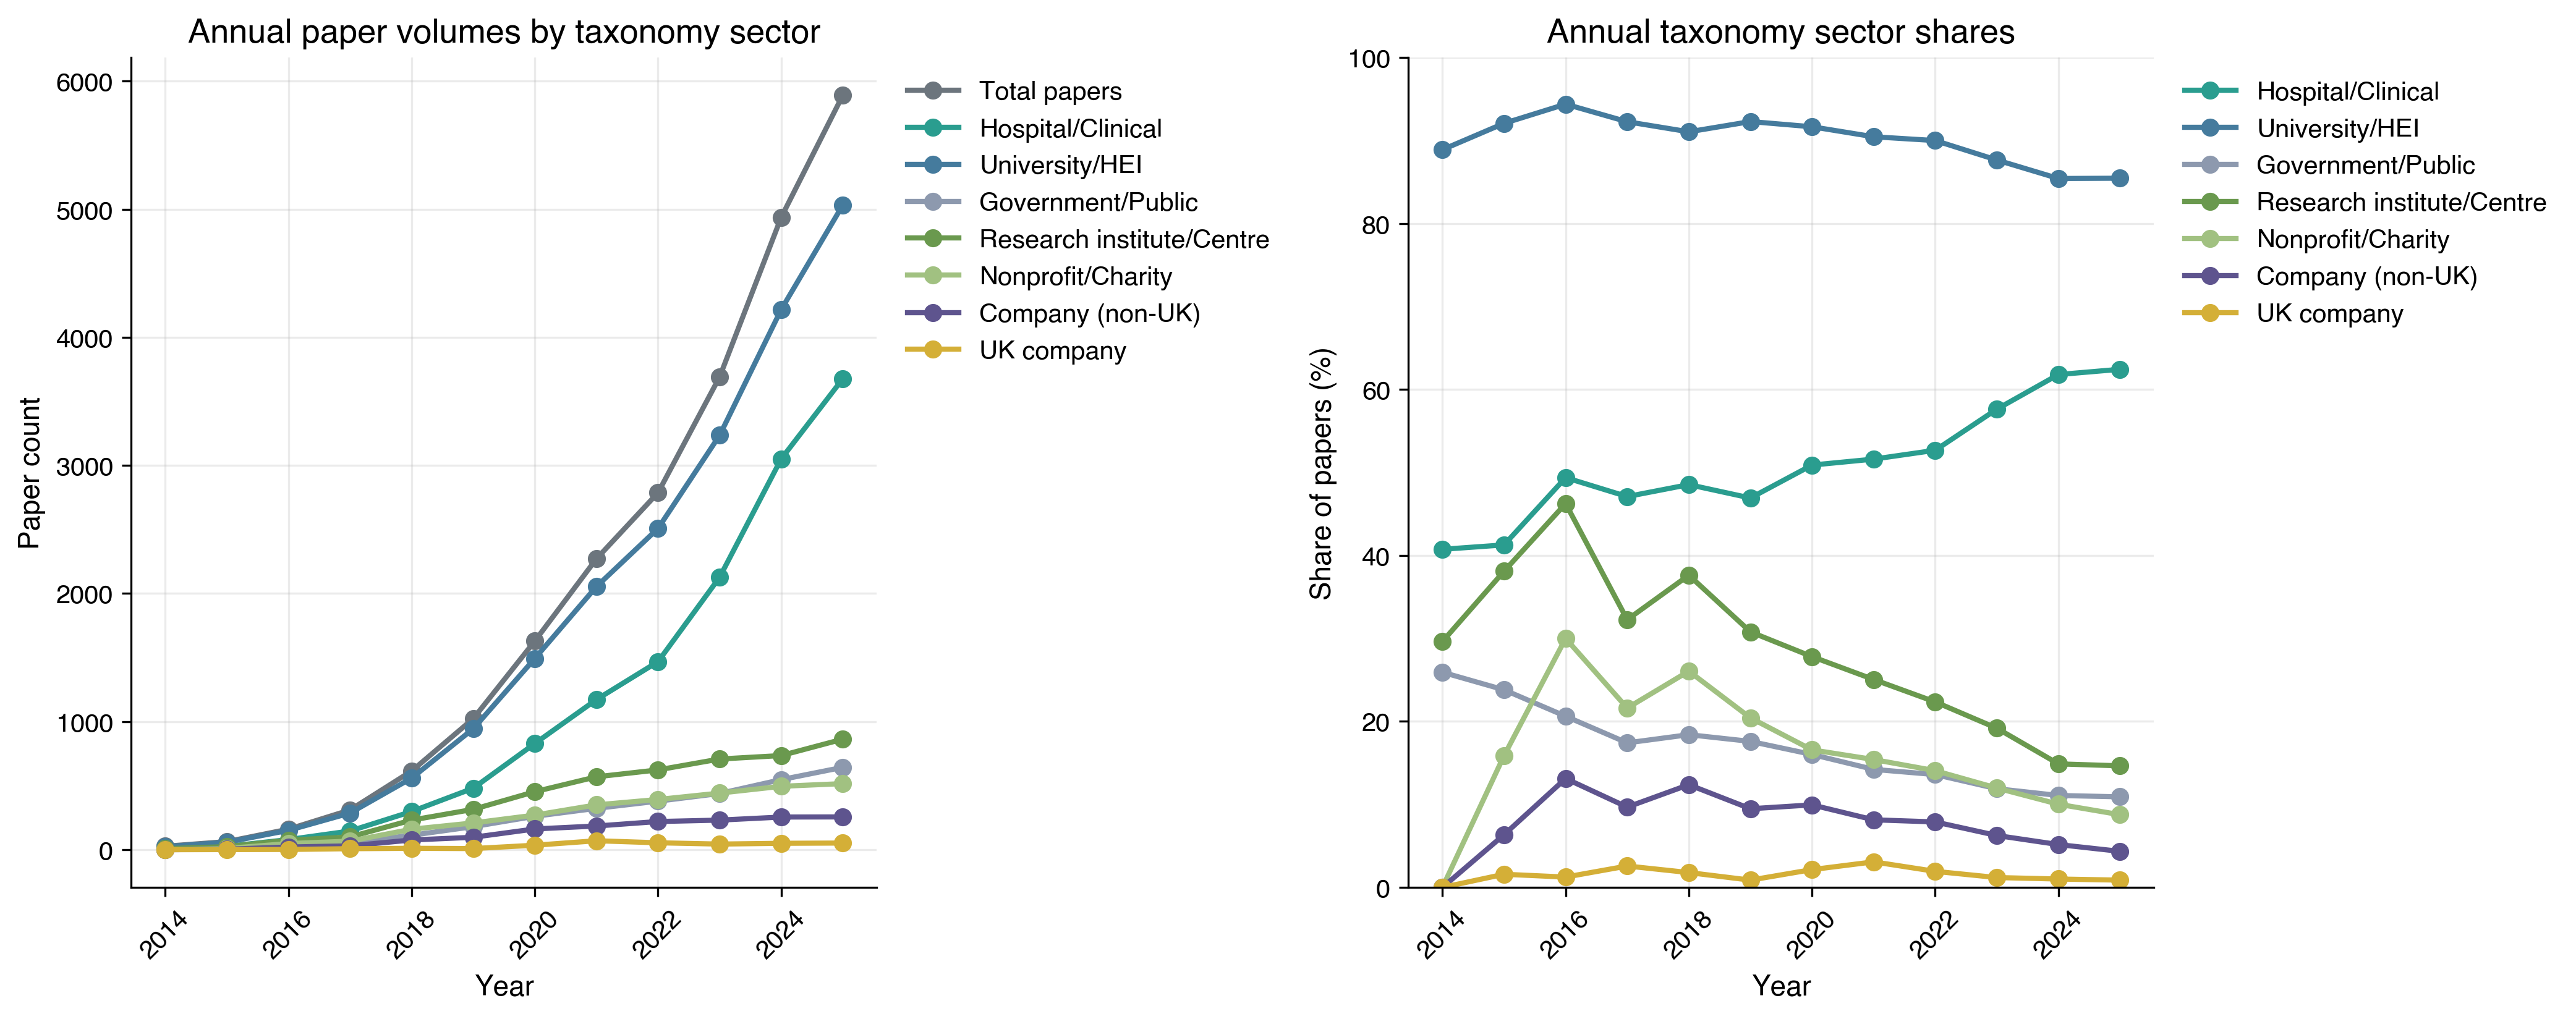

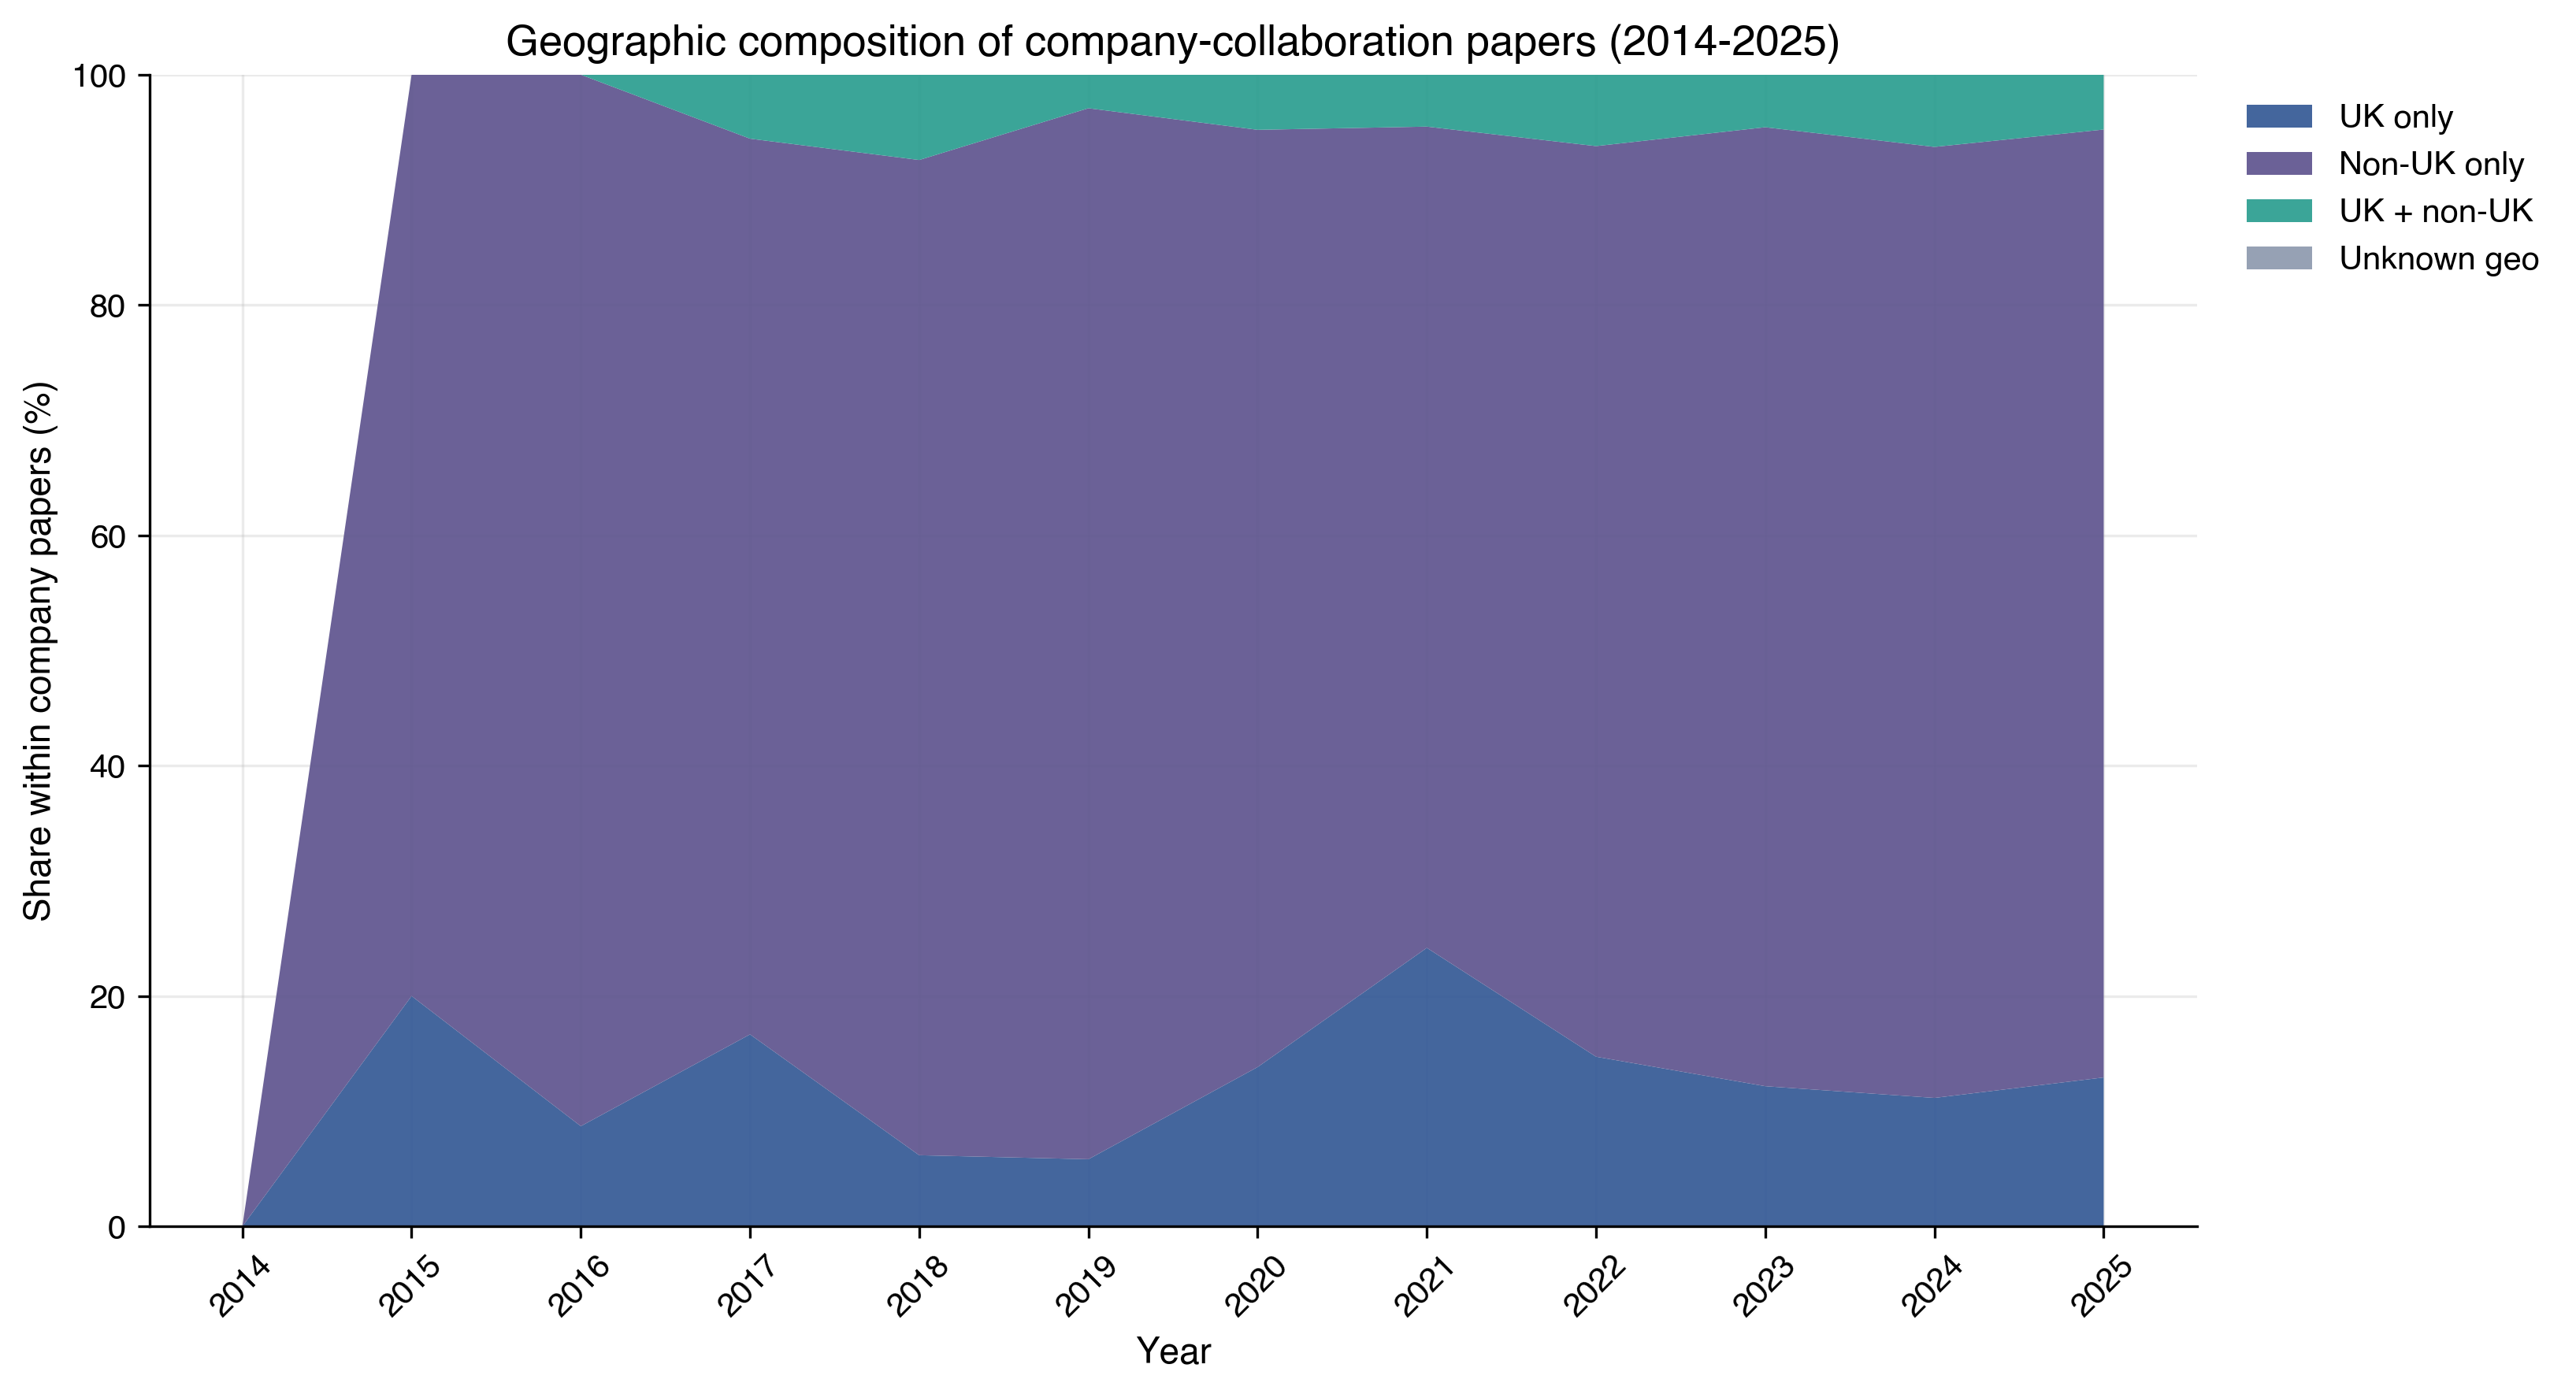

Company collaborator churn (new vs returning):


,year,active_company_collaborators,new_company_collaborators,returning_company_collaborators,new_share_pct
0,2014,0,0,0,0.000000
1,2015,7,7,0,100.000000
2,2016,29,26,3,89.655172
3,2017,30,24,6,80.000000
4,2018,63,41,22,65.079365
5,2019,76,39,37,51.315789
6,2020,102,53,49,51.960784
7,2021,131,60,71,45.801527
8,2022,154,62,92,40.259740
9,2023,133,47,86,35.338346


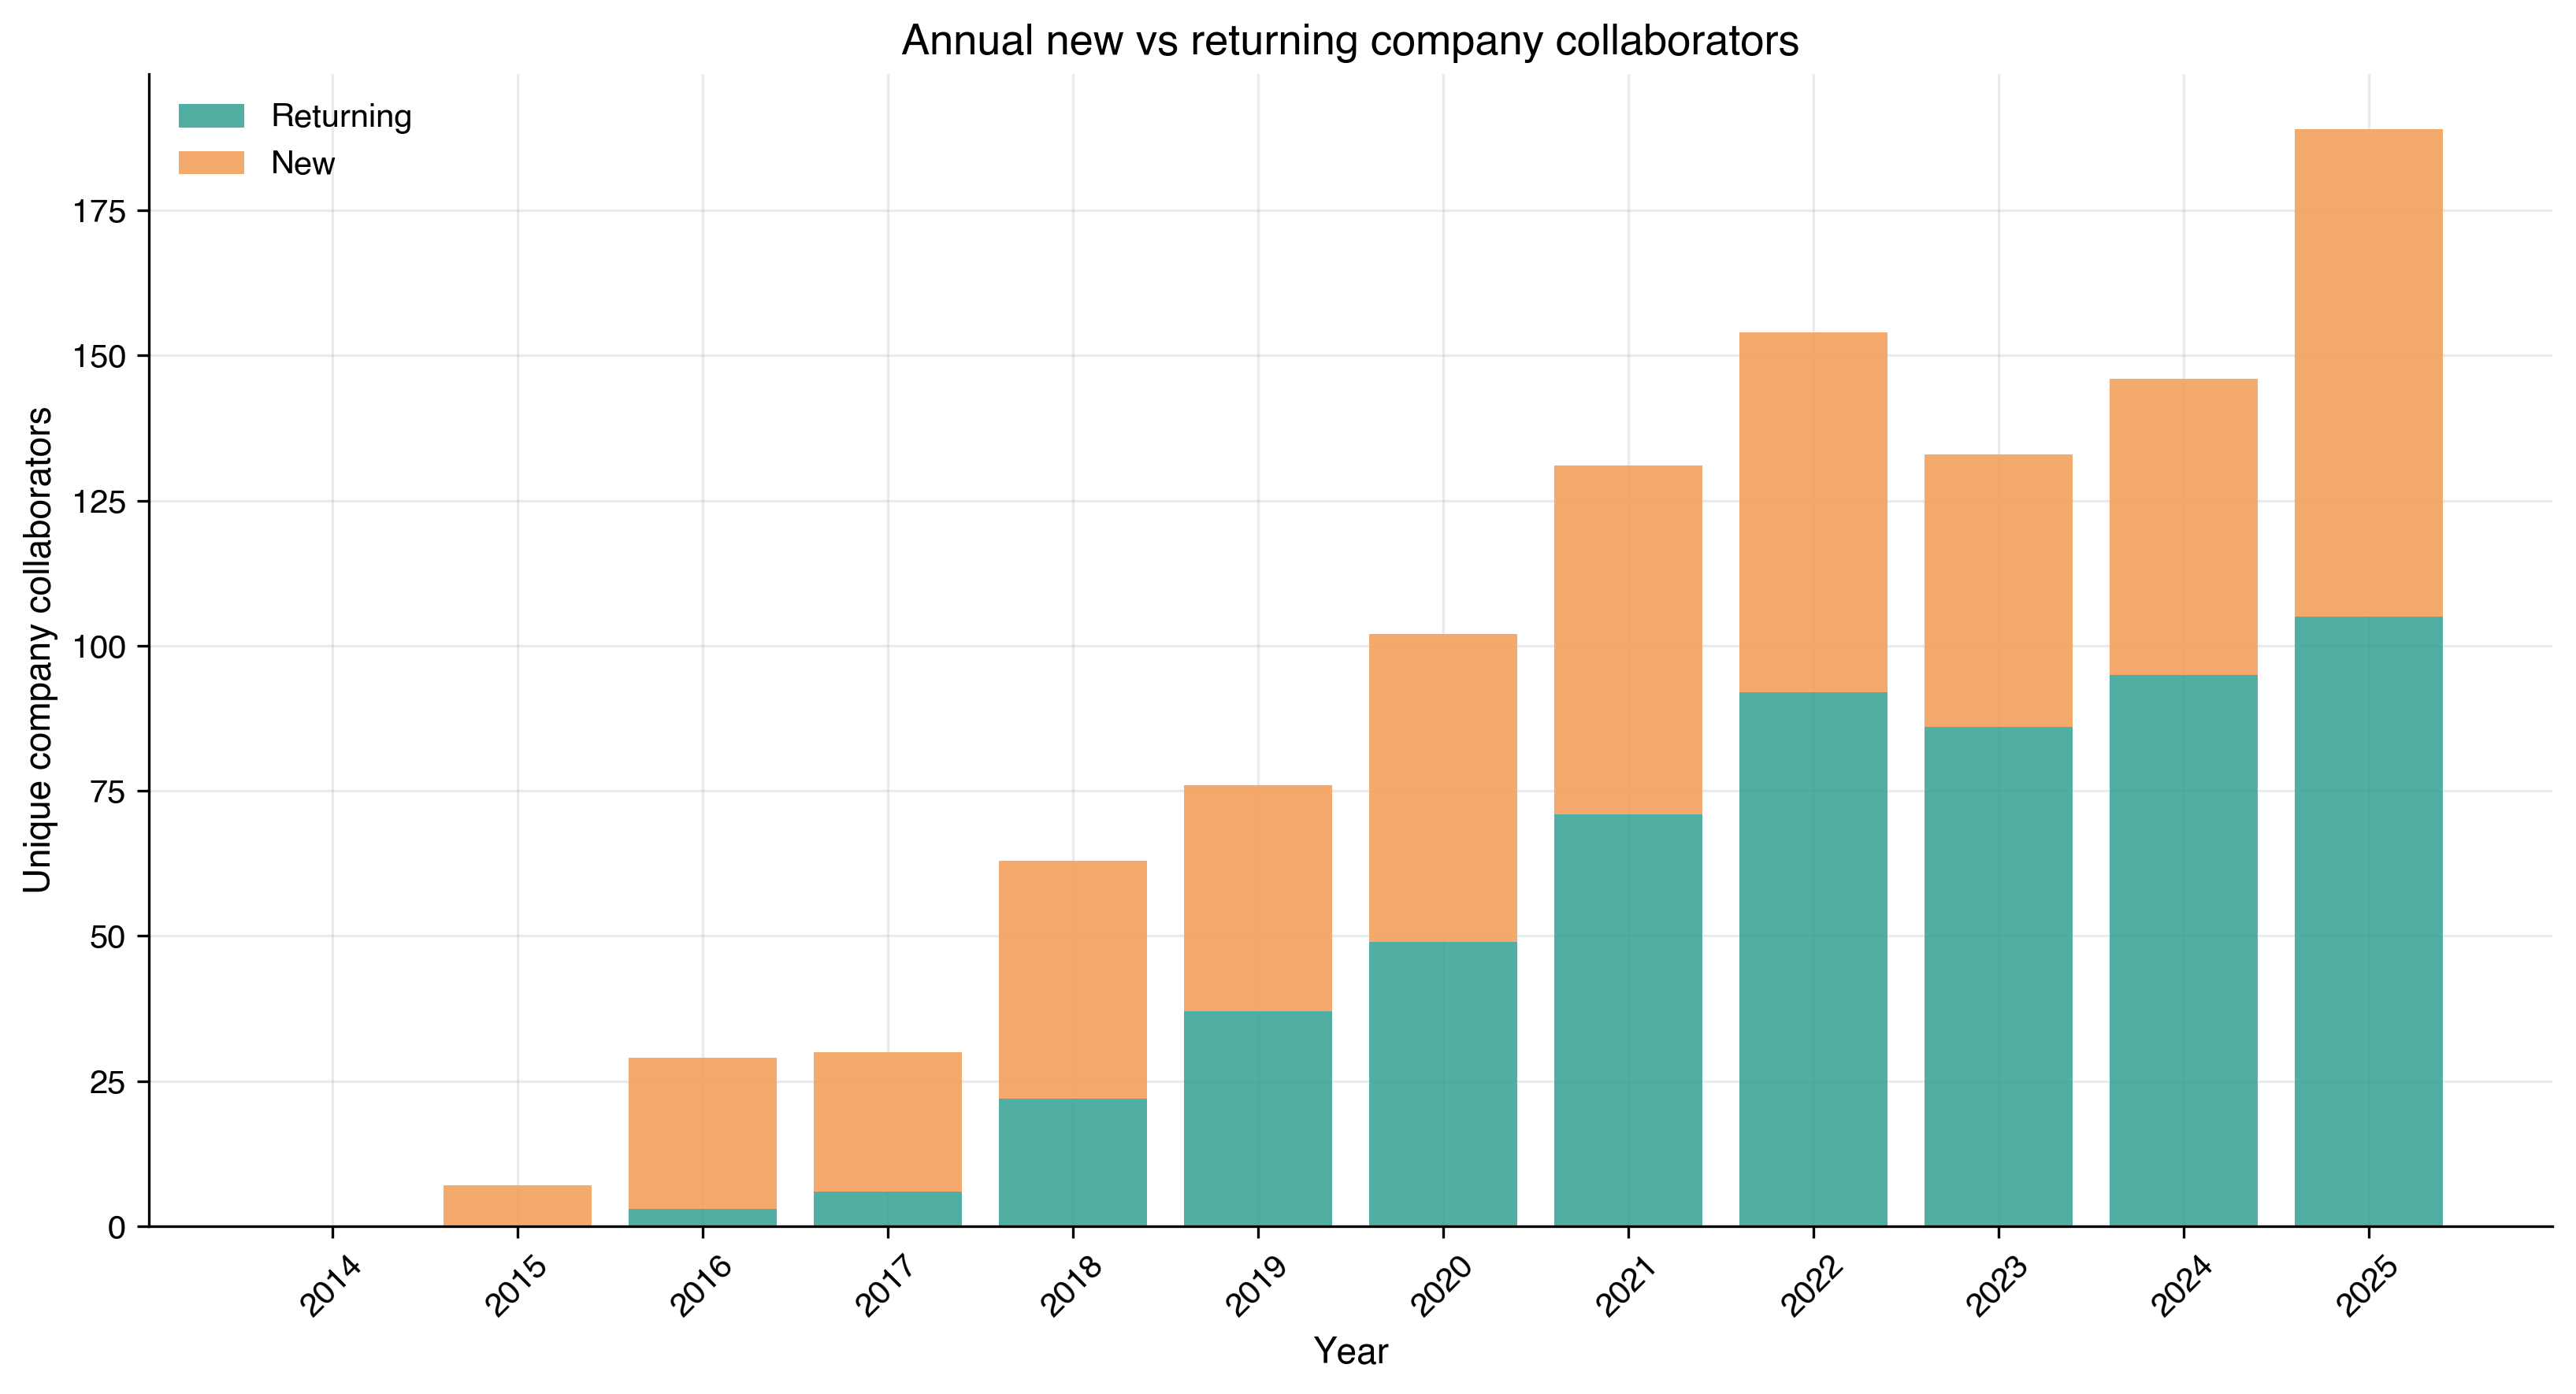

Top company collaborators by year matrix:


,org,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Decode Genetics ehf,0,0,6,8,13,12,12,15,17,23,14,8
1,Regeneron Pharmaceuticals Inc,0,0,0,1,3,6,21,20,19,18,21,9
2,23andMe Inc,0,2,9,4,17,22,12,13,12,7,8,6
3,Novo Nordisk Research Centre Oxford Ltd,0,0,0,0,0,0,5,19,21,12,11,8
4,AstraZeneca UK Ltd,0,0,0,0,1,0,4,6,12,11,16,11
5,Kaiser Permanente,0,0,1,0,4,4,10,11,3,11,7,6
6,Calico Life Sciences LLC,0,0,0,0,0,1,4,4,10,9,7,12
7,Biogen Inc,0,0,0,0,0,2,7,12,8,9,8,5
8,Fimlab (Finland),0,2,4,5,3,6,6,6,2,3,4,5
9,Genentech Inc,0,0,1,0,1,2,5,5,9,4,5,4


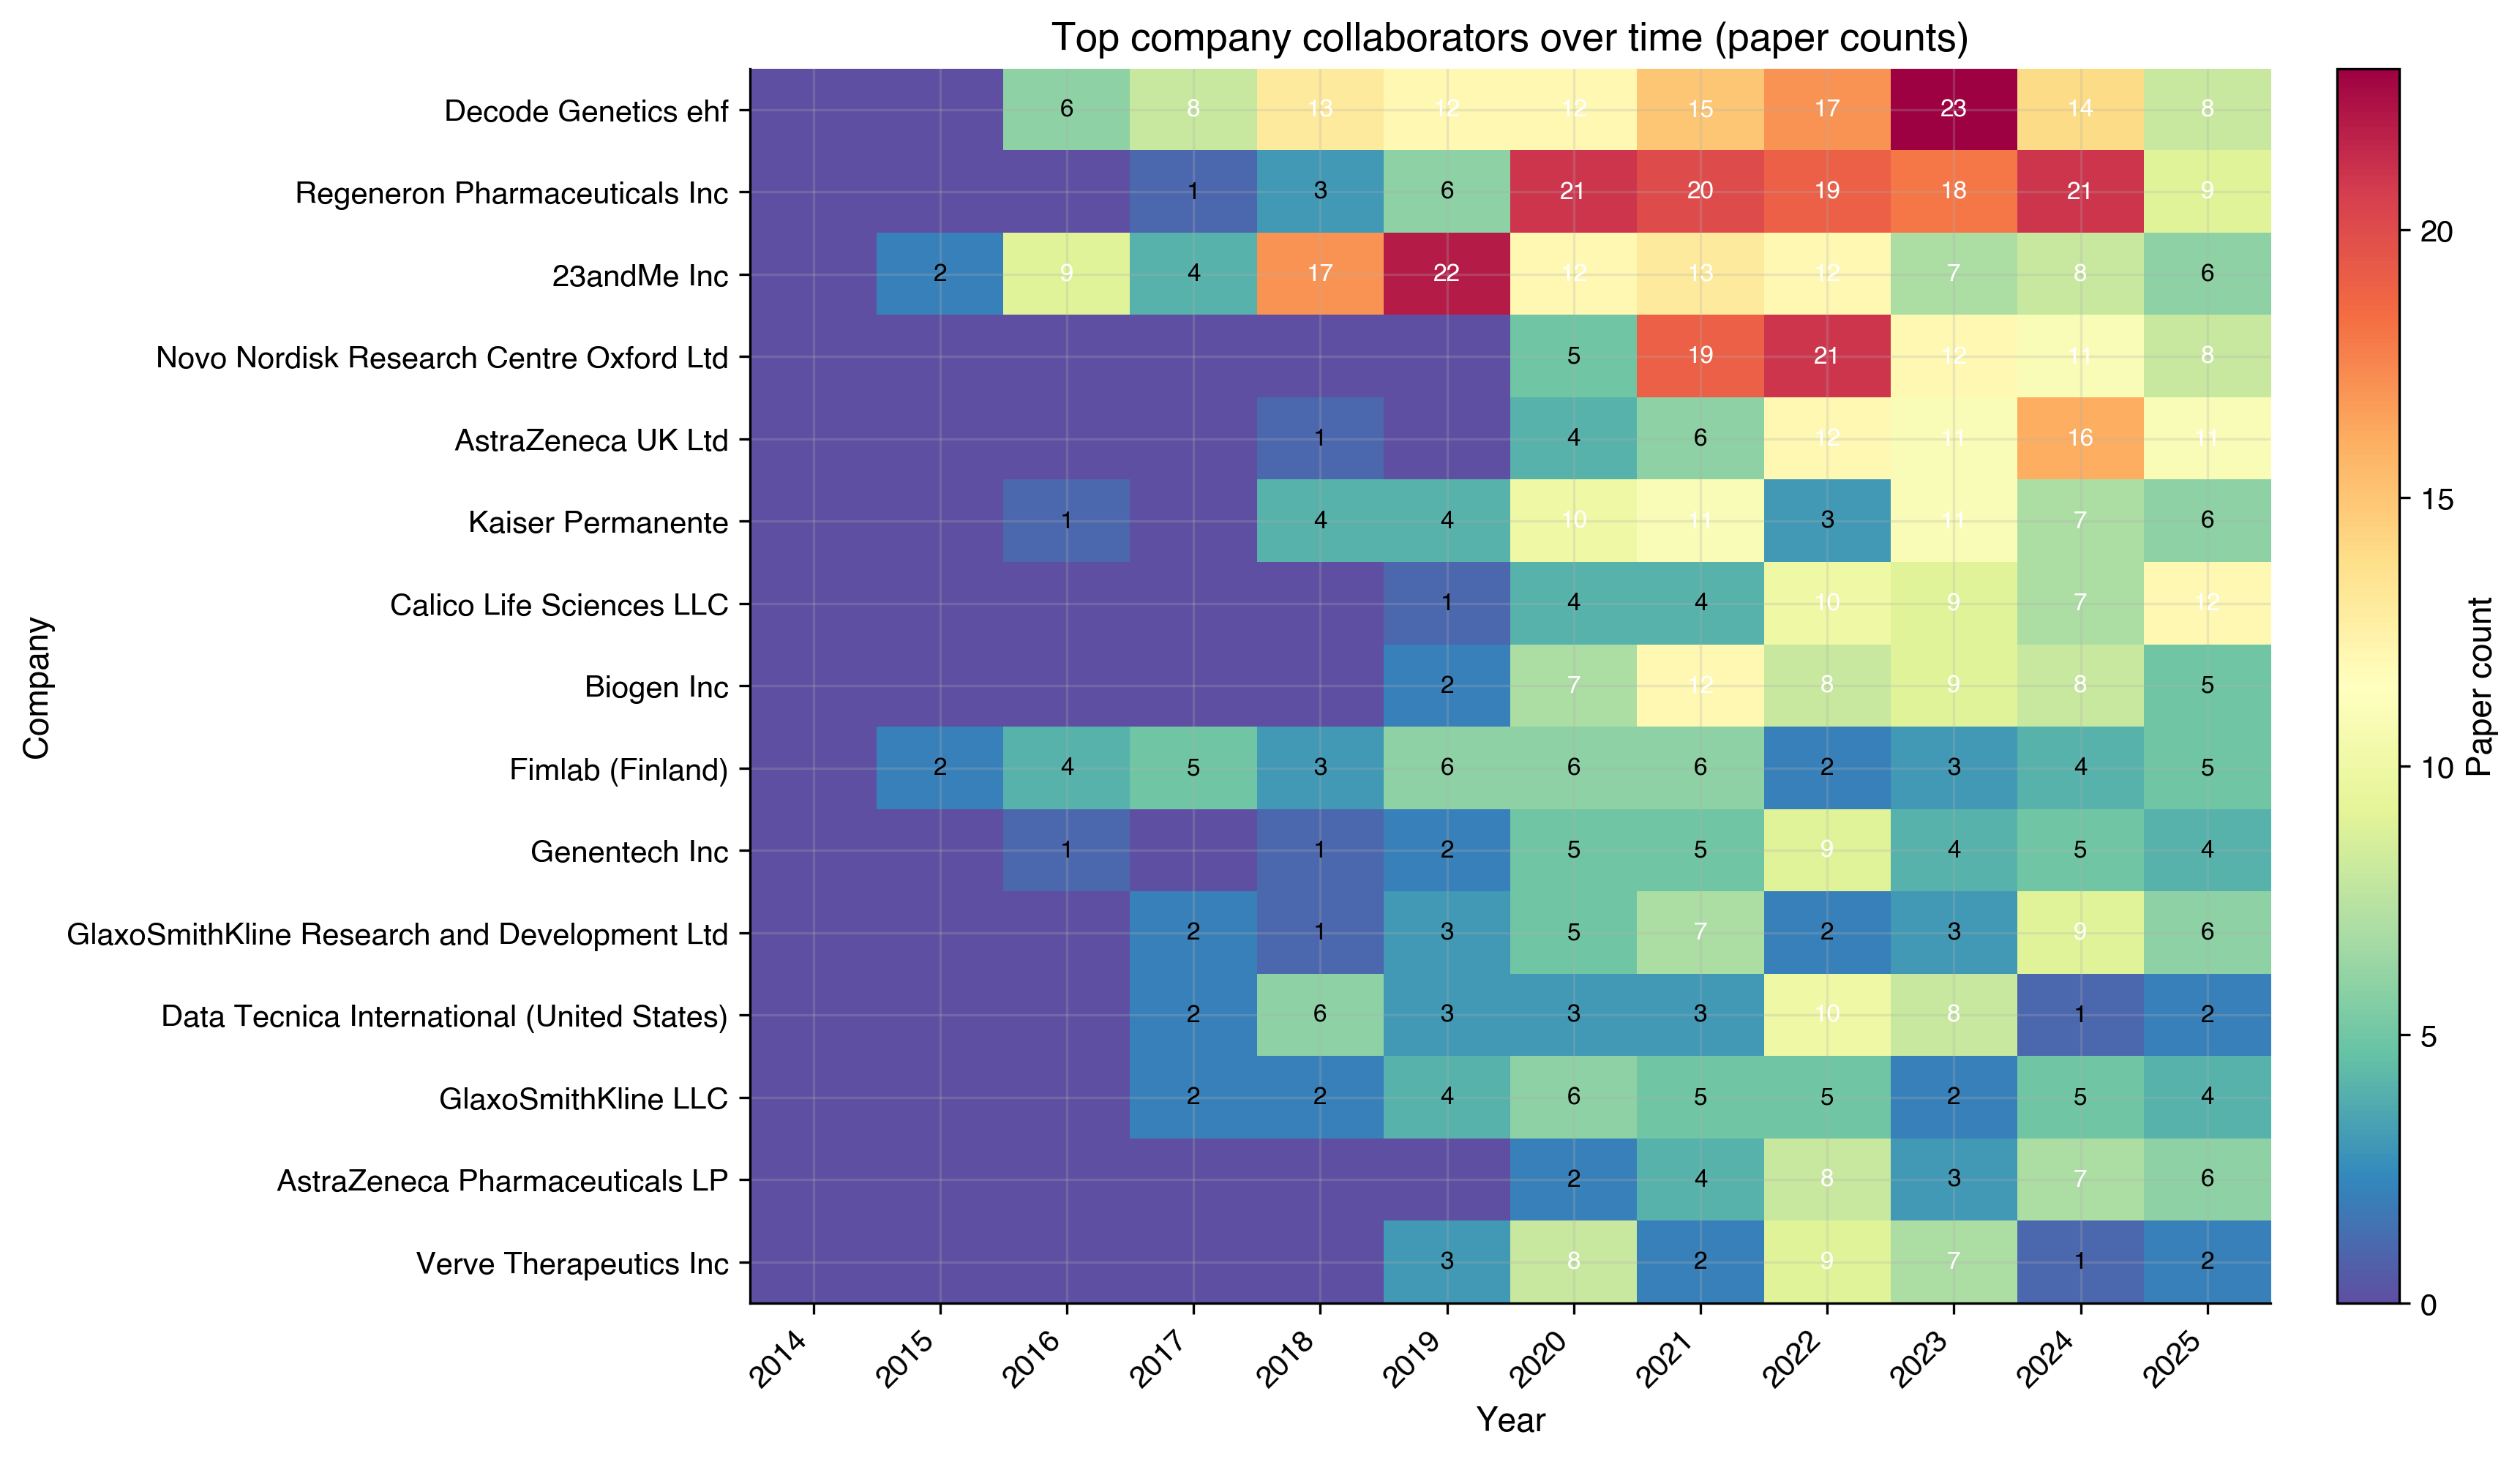

In [9]:
yearly_metrics_df = h.build_yearly_metrics_table(df, start_year=2014, end_year=2025)
print("Yearly collaboration metrics:")
display(yearly_metrics_df)

h.plot_yearly_metrics_dashboard(yearly_metrics_df)
h.plot_company_geography_mix_over_time(df, start_year=2014, end_year=2025)

company_churn_df = h.build_company_collaborator_churn_table(df, start_year=2014, end_year=2025)
print("Company collaborator churn (new vs returning):")
display(company_churn_df)

h.plot_new_vs_returning_company_collaborators(company_churn_df)

top_company_year_df = h.build_top_company_year_matrix(df, top_n=15, start_year=2014, end_year=2025)
print("Top company collaborators by year matrix:")
display(top_company_year_df)

h.plot_top_company_heatmap(top_company_year_df)


## 9. FoR 2020 Level-2 Analysis

FoR level-2 labels are parsed from `category_for_2020` and reported using discipline names (not only numeric codes).

Papers with parsed category_for_2020 level-2 codes: 26048
Unique parsed level-2 codes: 21


,l2_for_name,code,papers,share_hospital_clinical,share_university_hei,share_company_non_uk,share_uk_company
0,Biomedical and Clinical Sciences,32,15094,0.636081,0.874983,0.058036,0.012522
1,Health Sciences,42,10301,0.546549,0.889040,0.059315,0.013008
2,Biological Sciences,31,6554,0.545926,0.908605,0.127708,0.025328
3,Psychology,52,2790,0.535484,0.916487,0.040143,0.004659
4,Mathematical Sciences,49,1309,0.395722,0.799083,0.056532,0.006875
5,Information and Computing Sciences,46,786,0.221374,0.661578,0.069975,0.012723
6,Engineering,40,220,0.431818,0.795455,0.059091,0.013636
7,Environmental Sciences,41,211,0.526066,0.900474,0.014218,0.004739
8,Physical Sciences,51,121,0.289256,0.719008,0.016529,0.016529
9,Chemical Sciences,34,118,0.601695,0.898305,0.033898,0.000000


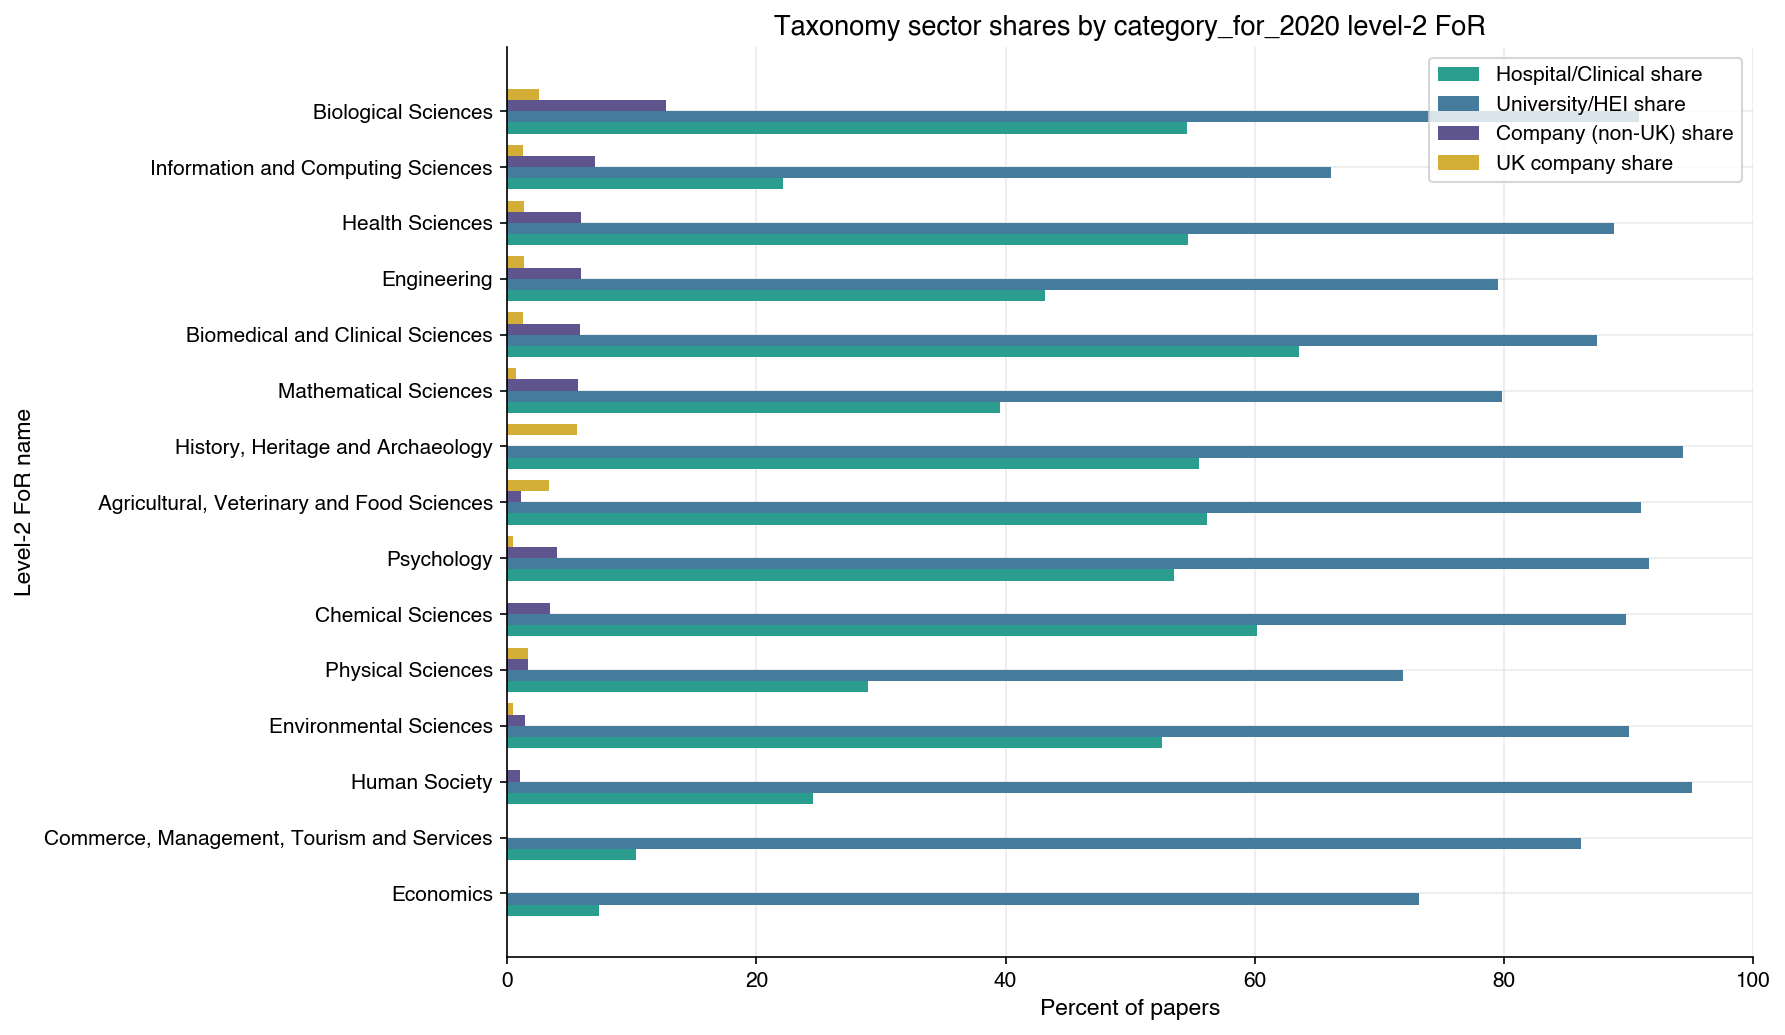

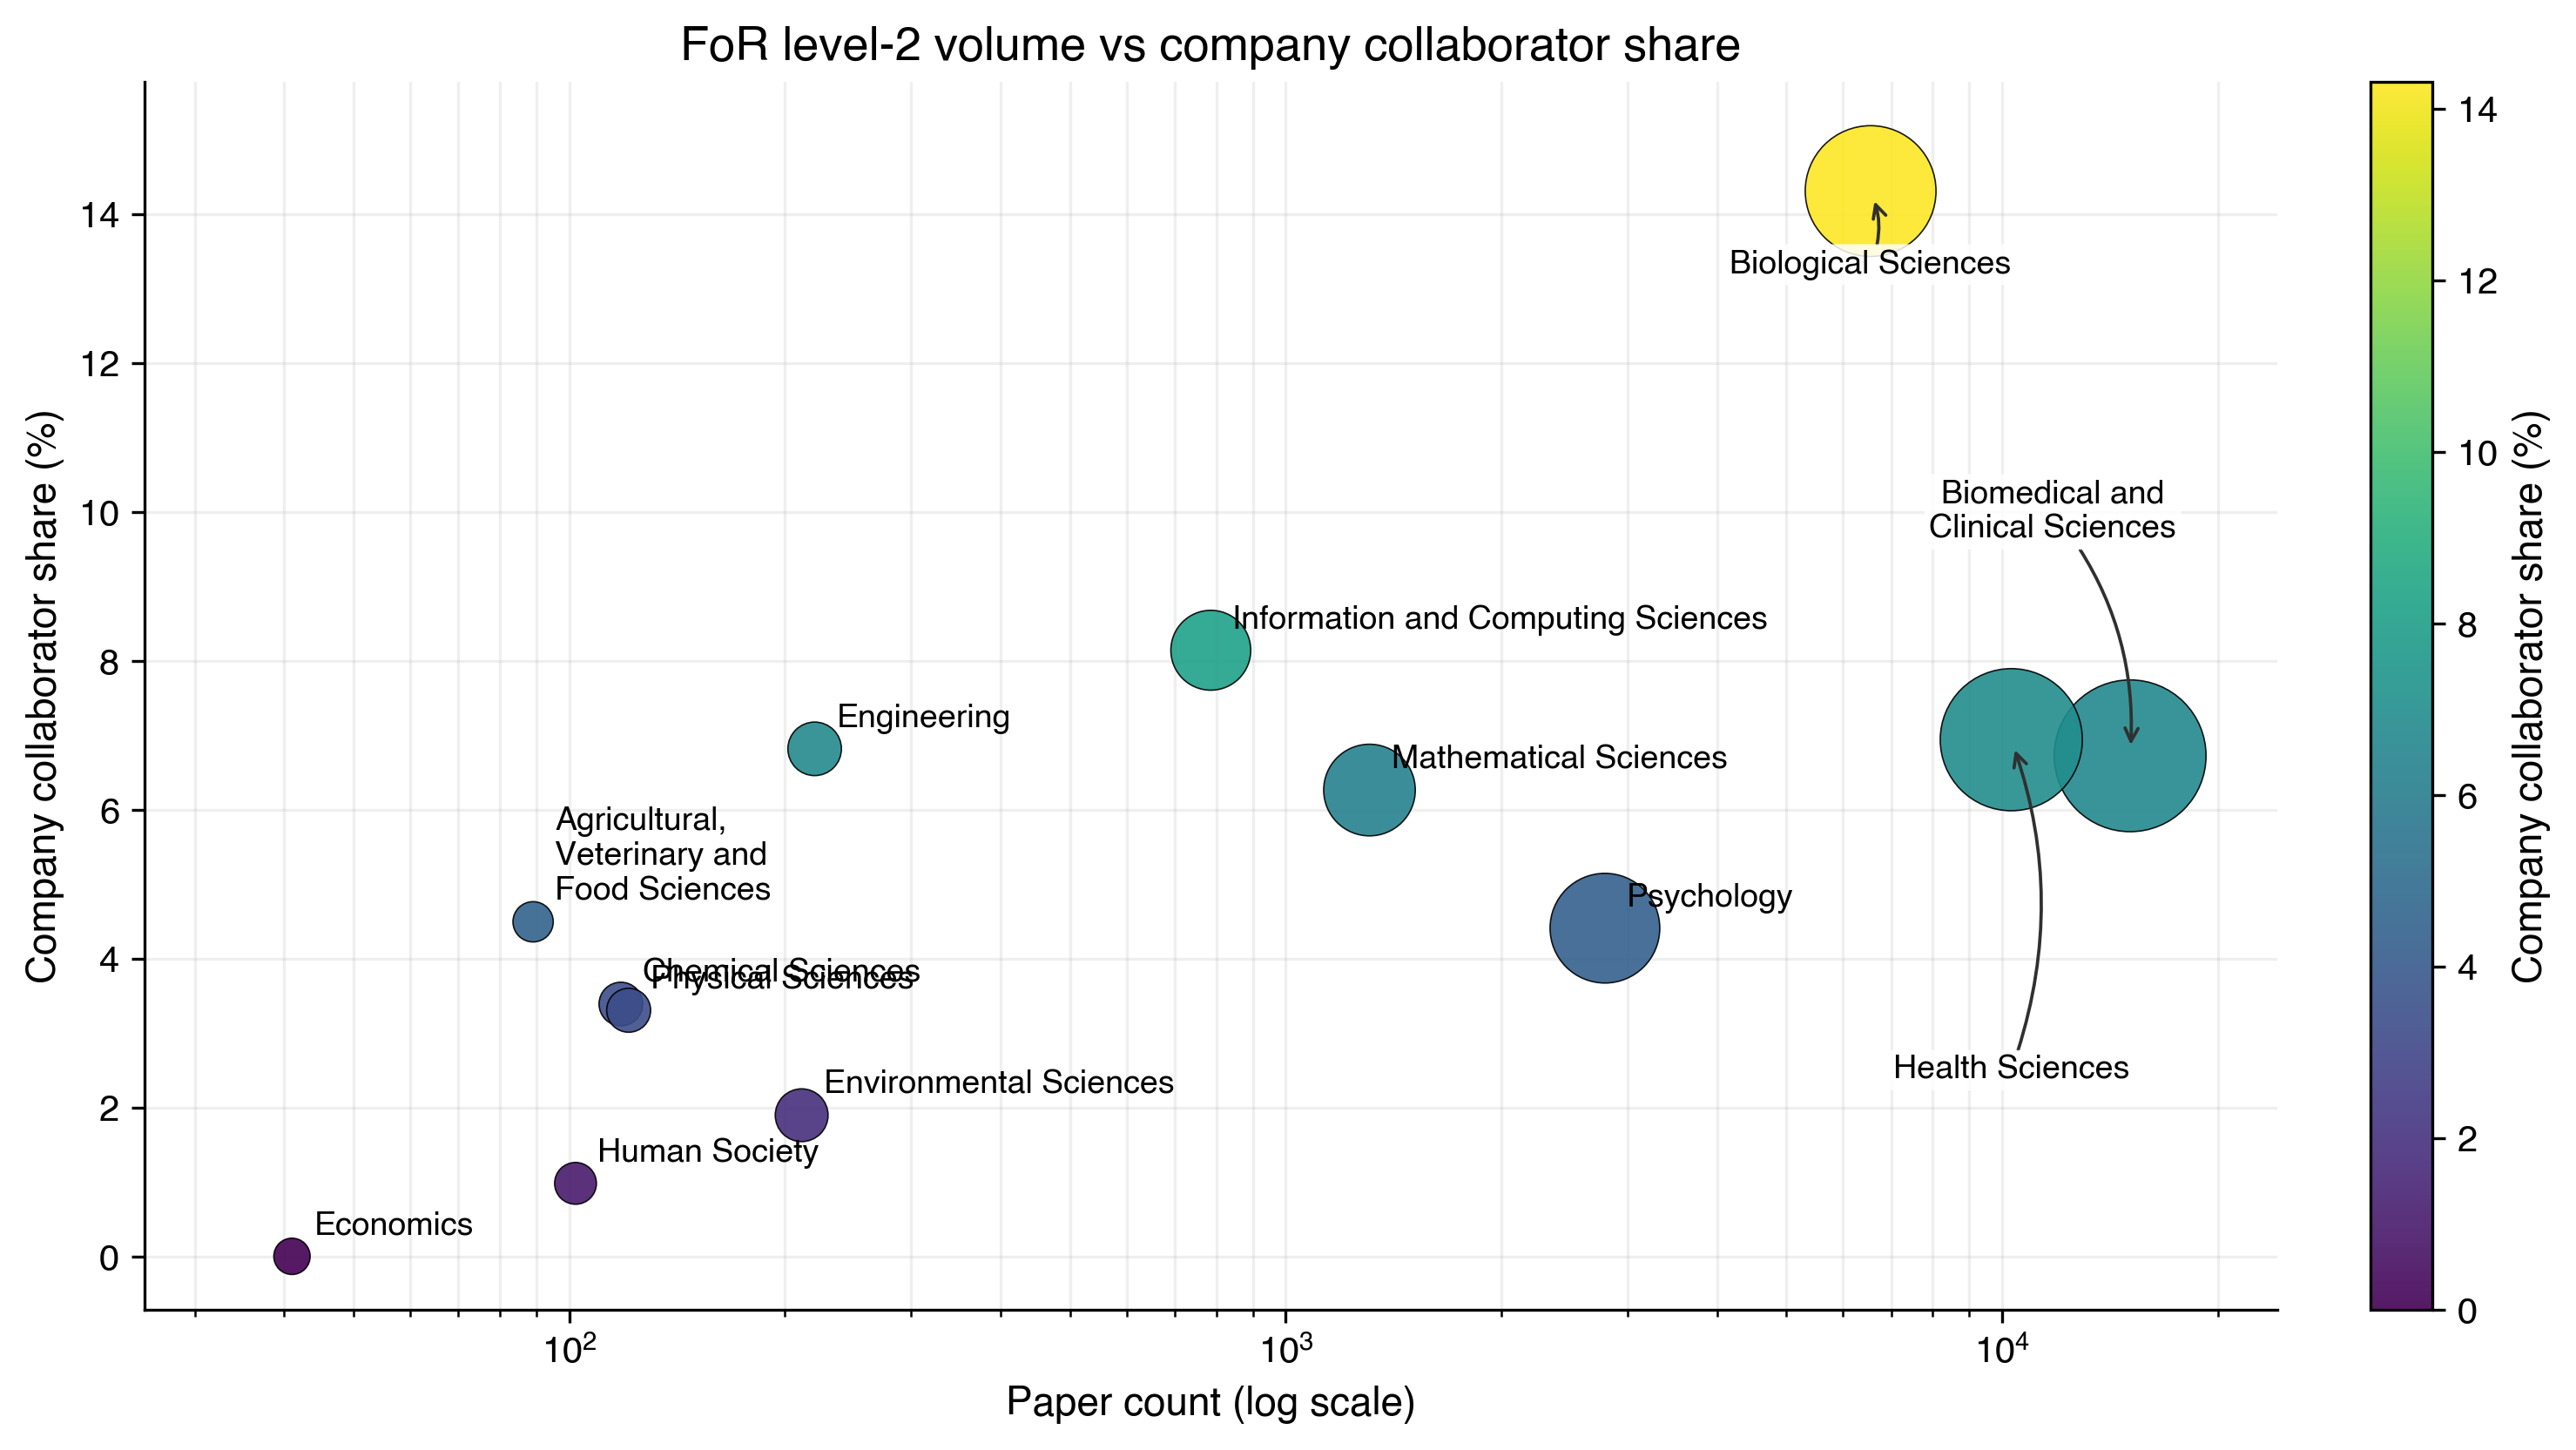

,l2_for_name,code,papers,uk_company_share
0,Law and Legal Studies,48,9,0.111111
1,"History, Heritage and Archaeology",43,18,0.055556
2,"Agricultural, Veterinary and Food Sciences",30,89,0.033708
3,Biological Sciences,31,6554,0.025328
4,Physical Sciences,51,121,0.016529
5,Engineering,40,220,0.013636
6,Health Sciences,42,10301,0.013008
7,Information and Computing Sciences,46,786,0.012723
8,Biomedical and Clinical Sciences,32,15094,0.012522
9,Mathematical Sciences,49,1309,0.006875


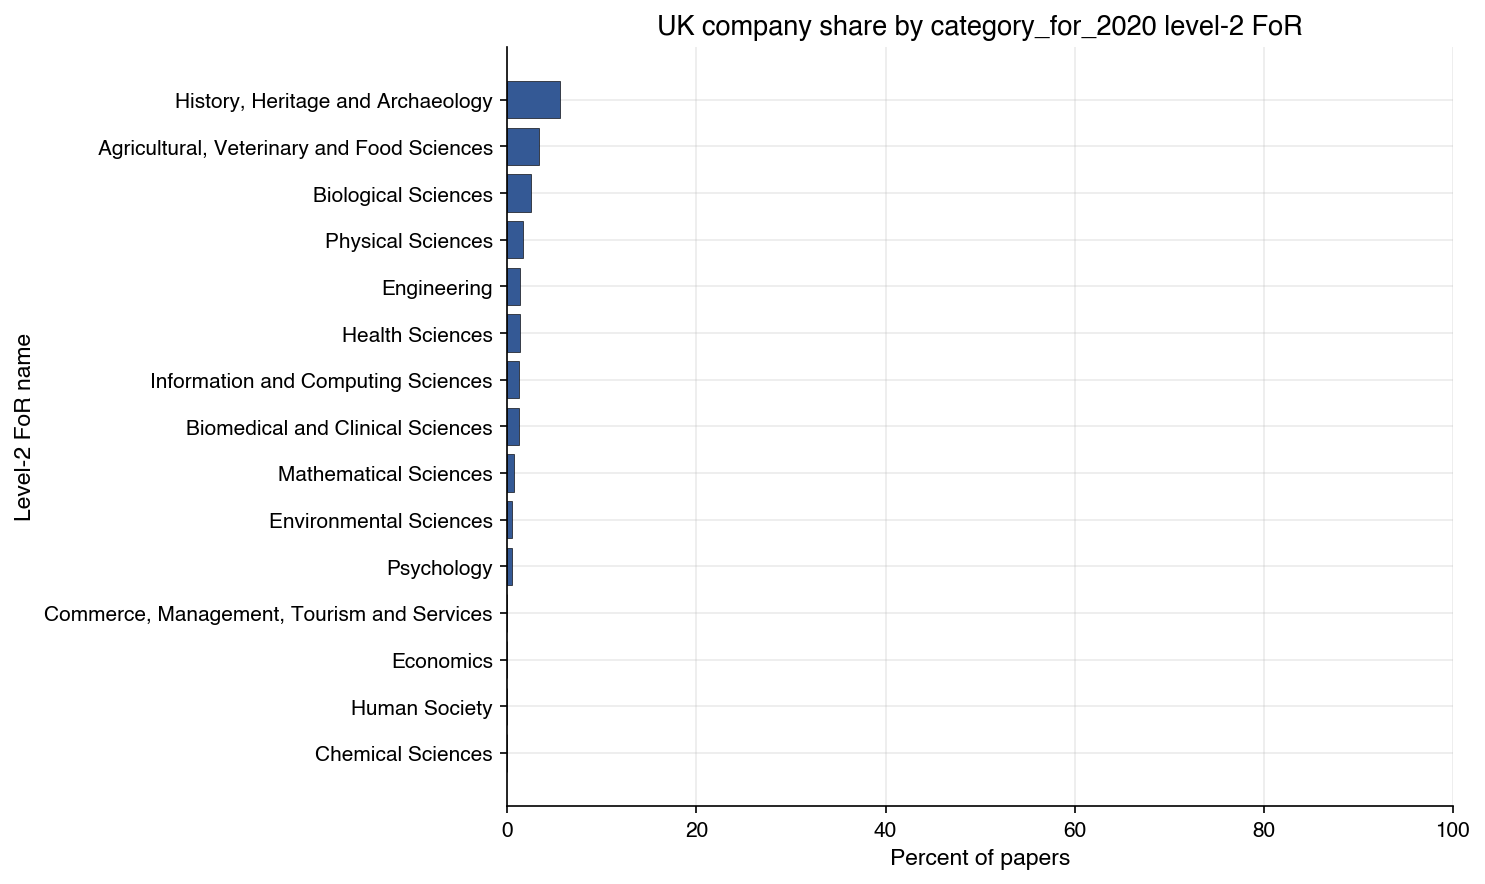

In [10]:
df, for_name_map = h.add_for_level2_columns(df)

if "category_for_2020_lvl2" in df.columns:
    n_with_lvl2 = int((df["category_for_2020_lvl2"].map(len) > 0).sum())
    unique_lvl2 = len({code for codes in df["category_for_2020_lvl2"] for code in codes})
    print(f"Papers with parsed category_for_2020 level-2 codes: {n_with_lvl2}")
    print(f"Unique parsed level-2 codes: {unique_lvl2}")
else:
    print("Column category_for_2020 not found or no level-2 parsing available.")

for_share_df = h.build_for_share_table(df, for_name_map)
if for_share_df.empty:
    print("No category_for_2020 level-2 codes found to plot.")
else:
    display(
        for_share_df[[
            "l2_for_name",
            "code",
            "papers",
            "share_hospital_clinical",
            "share_university_hei",
            "share_company_non_uk",
            "share_uk_company",
        ]]
        .sort_values("papers", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    h.plot_for_share_table(for_share_df, top_n=15)
    h.plot_for_company_share_scatter(for_share_df, min_papers=30, max_labels=10)

uk_for_df = h.build_uk_company_for_table(df, for_name_map)
if uk_for_df.empty:
    print("No category_for_2020 level-2 codes found to plot.")
else:
    display(
        uk_for_df[["l2_for_name", "code", "papers", "uk_company_share"]]
        .sort_values("uk_company_share", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )
    h.plot_uk_company_for_table(uk_for_df, top_n=15)


## 10. Geography of Collaborators

Country counts are matched from taxonomy-derived collaborator organization sets at paper level (with fallback to `research_org_country_names` where needed).

Top taxonomy-collaborator countries (all sectors combined):


,country,n_pubs,country_norm
0,United States,101245,United States of America
1,China,94202,China
2,United Kingdom,82675,United Kingdom
3,Australia,14663,Australia
4,Germany,14592,Germany
5,Netherlands,12511,Netherlands
6,Canada,11440,Canada
7,Sweden,7039,Sweden
8,Norway,6649,Norway
9,Denmark,6497,Denmark


Top company-sector collaborator countries:


,country,n_pubs,country_norm
0,United States,5525,United States of America
1,United Kingdom,1566,United Kingdom
2,Iceland,1472,Iceland
3,Germany,314,Germany
4,Sweden,219,Sweden
5,Finland,210,Finland
6,China,154,China
7,Denmark,75,Denmark
8,South Korea,56,South Korea
9,Israel,56,Israel


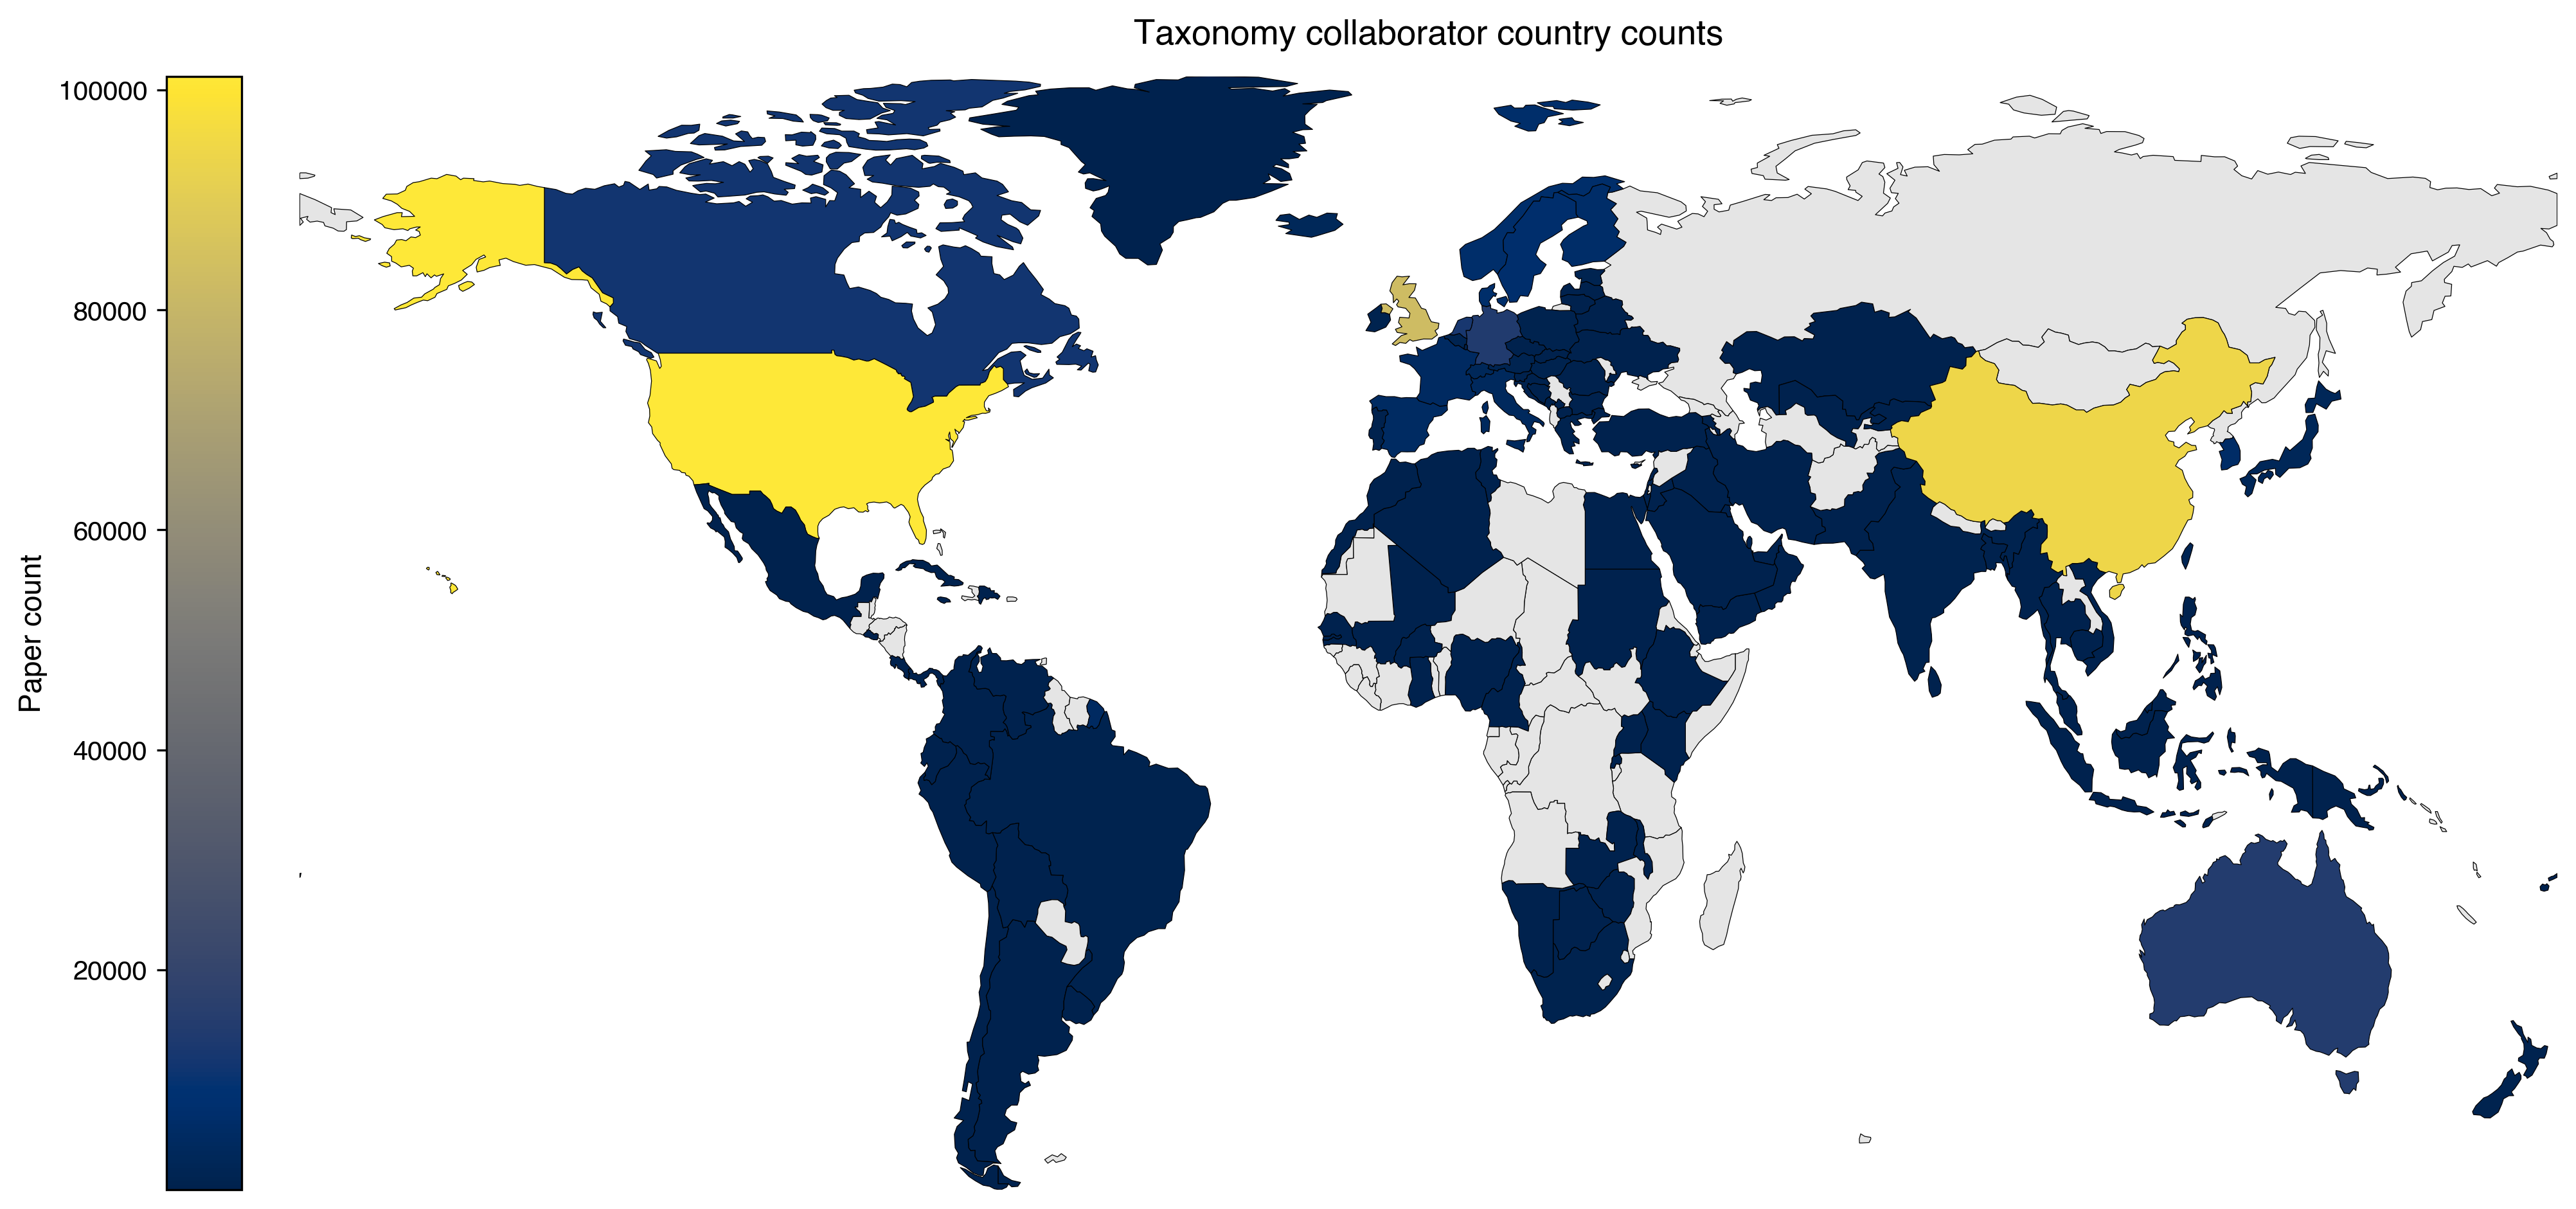

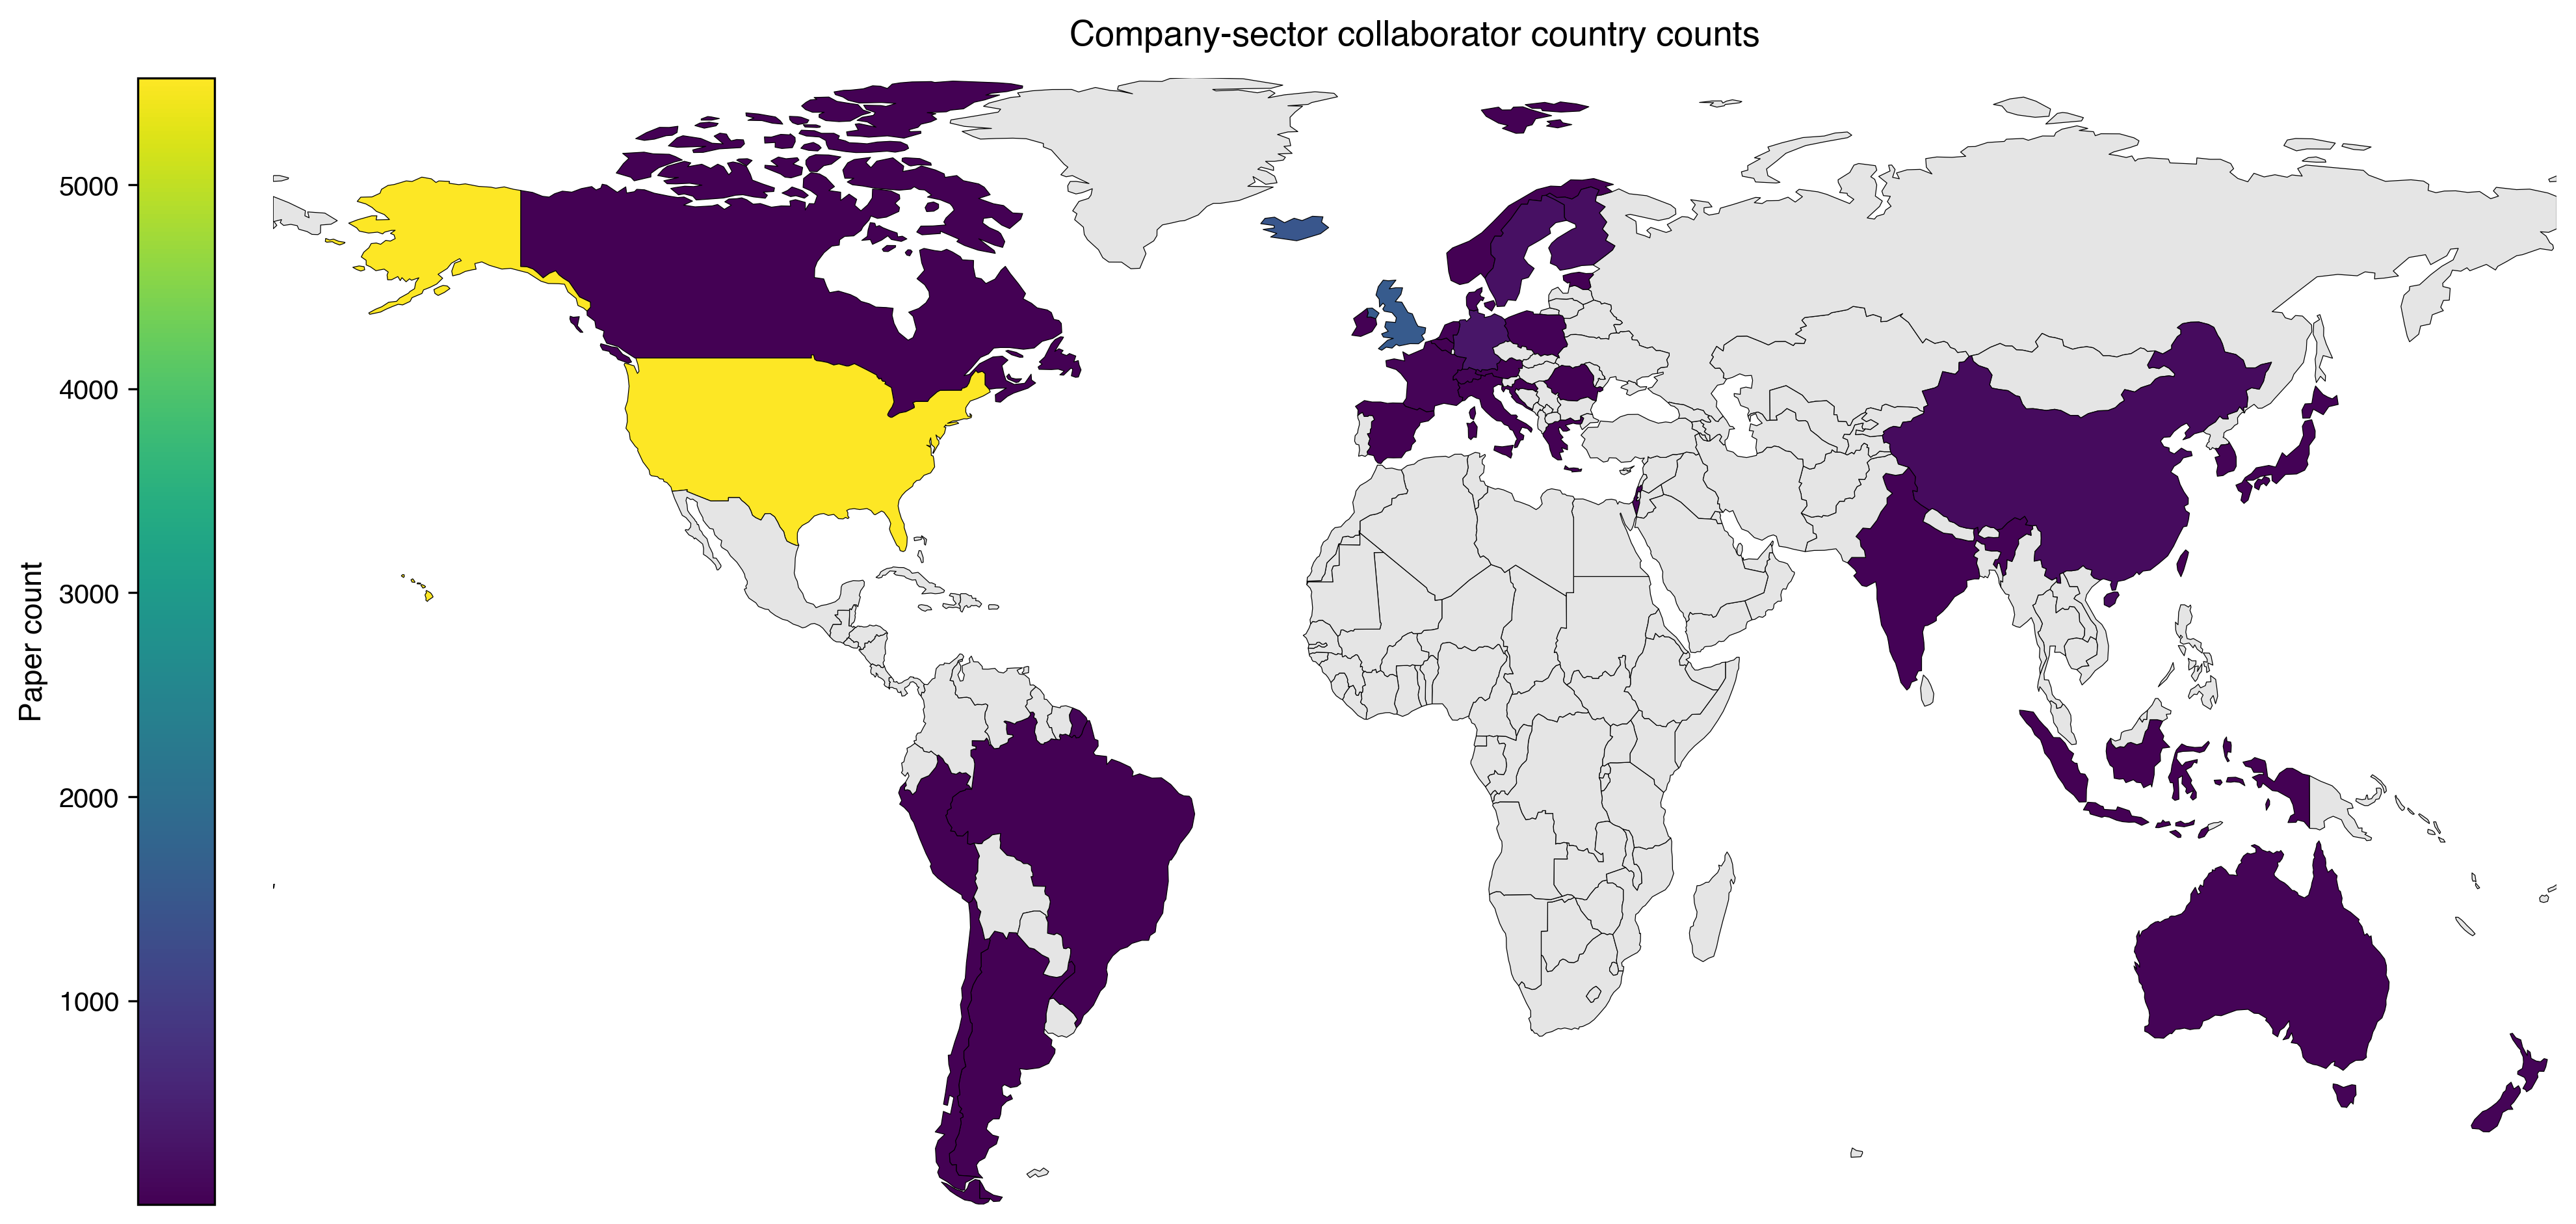

In [11]:
df = h.add_country_columns(df)

non_country_df = h.build_country_count_table(df["non_academic_countries"])
company_country_df = h.build_country_count_table(df["company_countries"])

print("Top taxonomy-collaborator countries (all sectors combined):")
display(non_country_df.sort_values("n_pubs", ascending=False).head(20).reset_index(drop=True))

print("Top company-sector collaborator countries:")
display(company_country_df.sort_values("n_pubs", ascending=False).head(20).reset_index(drop=True))

world = h.load_world_geodata()
h.plot_country_map(non_country_df, "Taxonomy collaborator country counts", cmap_name="cividis", world=world)
h.plot_country_map(company_country_df, "Company-sector collaborator country counts", cmap_name="viridis", world=world)


## 11. Top-Cited Papers

Top-five cited papers are shown for selected taxonomy sectors,
formatted as: first author surname (`et al.` when multiple authors), year, title, journal, DOI, citation count.

In [12]:
sections = h.build_top_cited_sections(df, top_n=5, citation_col="times_cited")

for heading, refs in sections.items():
    print()
    print(f"{heading}:")
    for i, ref in enumerate(refs, start=1):
        print(f"{i}. {ref}")



Top 5 cited papers with Hospital/Clinical collaborations:
1. Bycroft et al. (2018), The UK Biobank resource with deep phenotyping and genomic data, Nature, DOI not available, 9463
2. Khera et al. (2018), Genome-wide polygenic scores for common diseases identify individuals with risk equivalent to monogenic mutations, Nature Genetics, DOI not available, 3092
3. Wray et al. (2018), Genome-wide association analyses identify 44 risk variants and refine the genetic architecture of major depression, Nature Genetics, DOI not available, 3086
4. Howard et al. (2019), Genome-wide meta-analysis of depression identifies 102 independent variants and highlights the importance of the prefrontal brain regions, Nature Neuroscience, DOI not available, 2626
5. Lee et al. (2018), Gene discovery and polygenic prediction from a genome-wide association study of educational attainment in 1.1 million individuals, Nature Genetics, DOI not available, 2535

Top 5 cited papers with Company (non-UK) collaborations

## 12. Publication Figure

A single 2x2 composite figure for publication use.

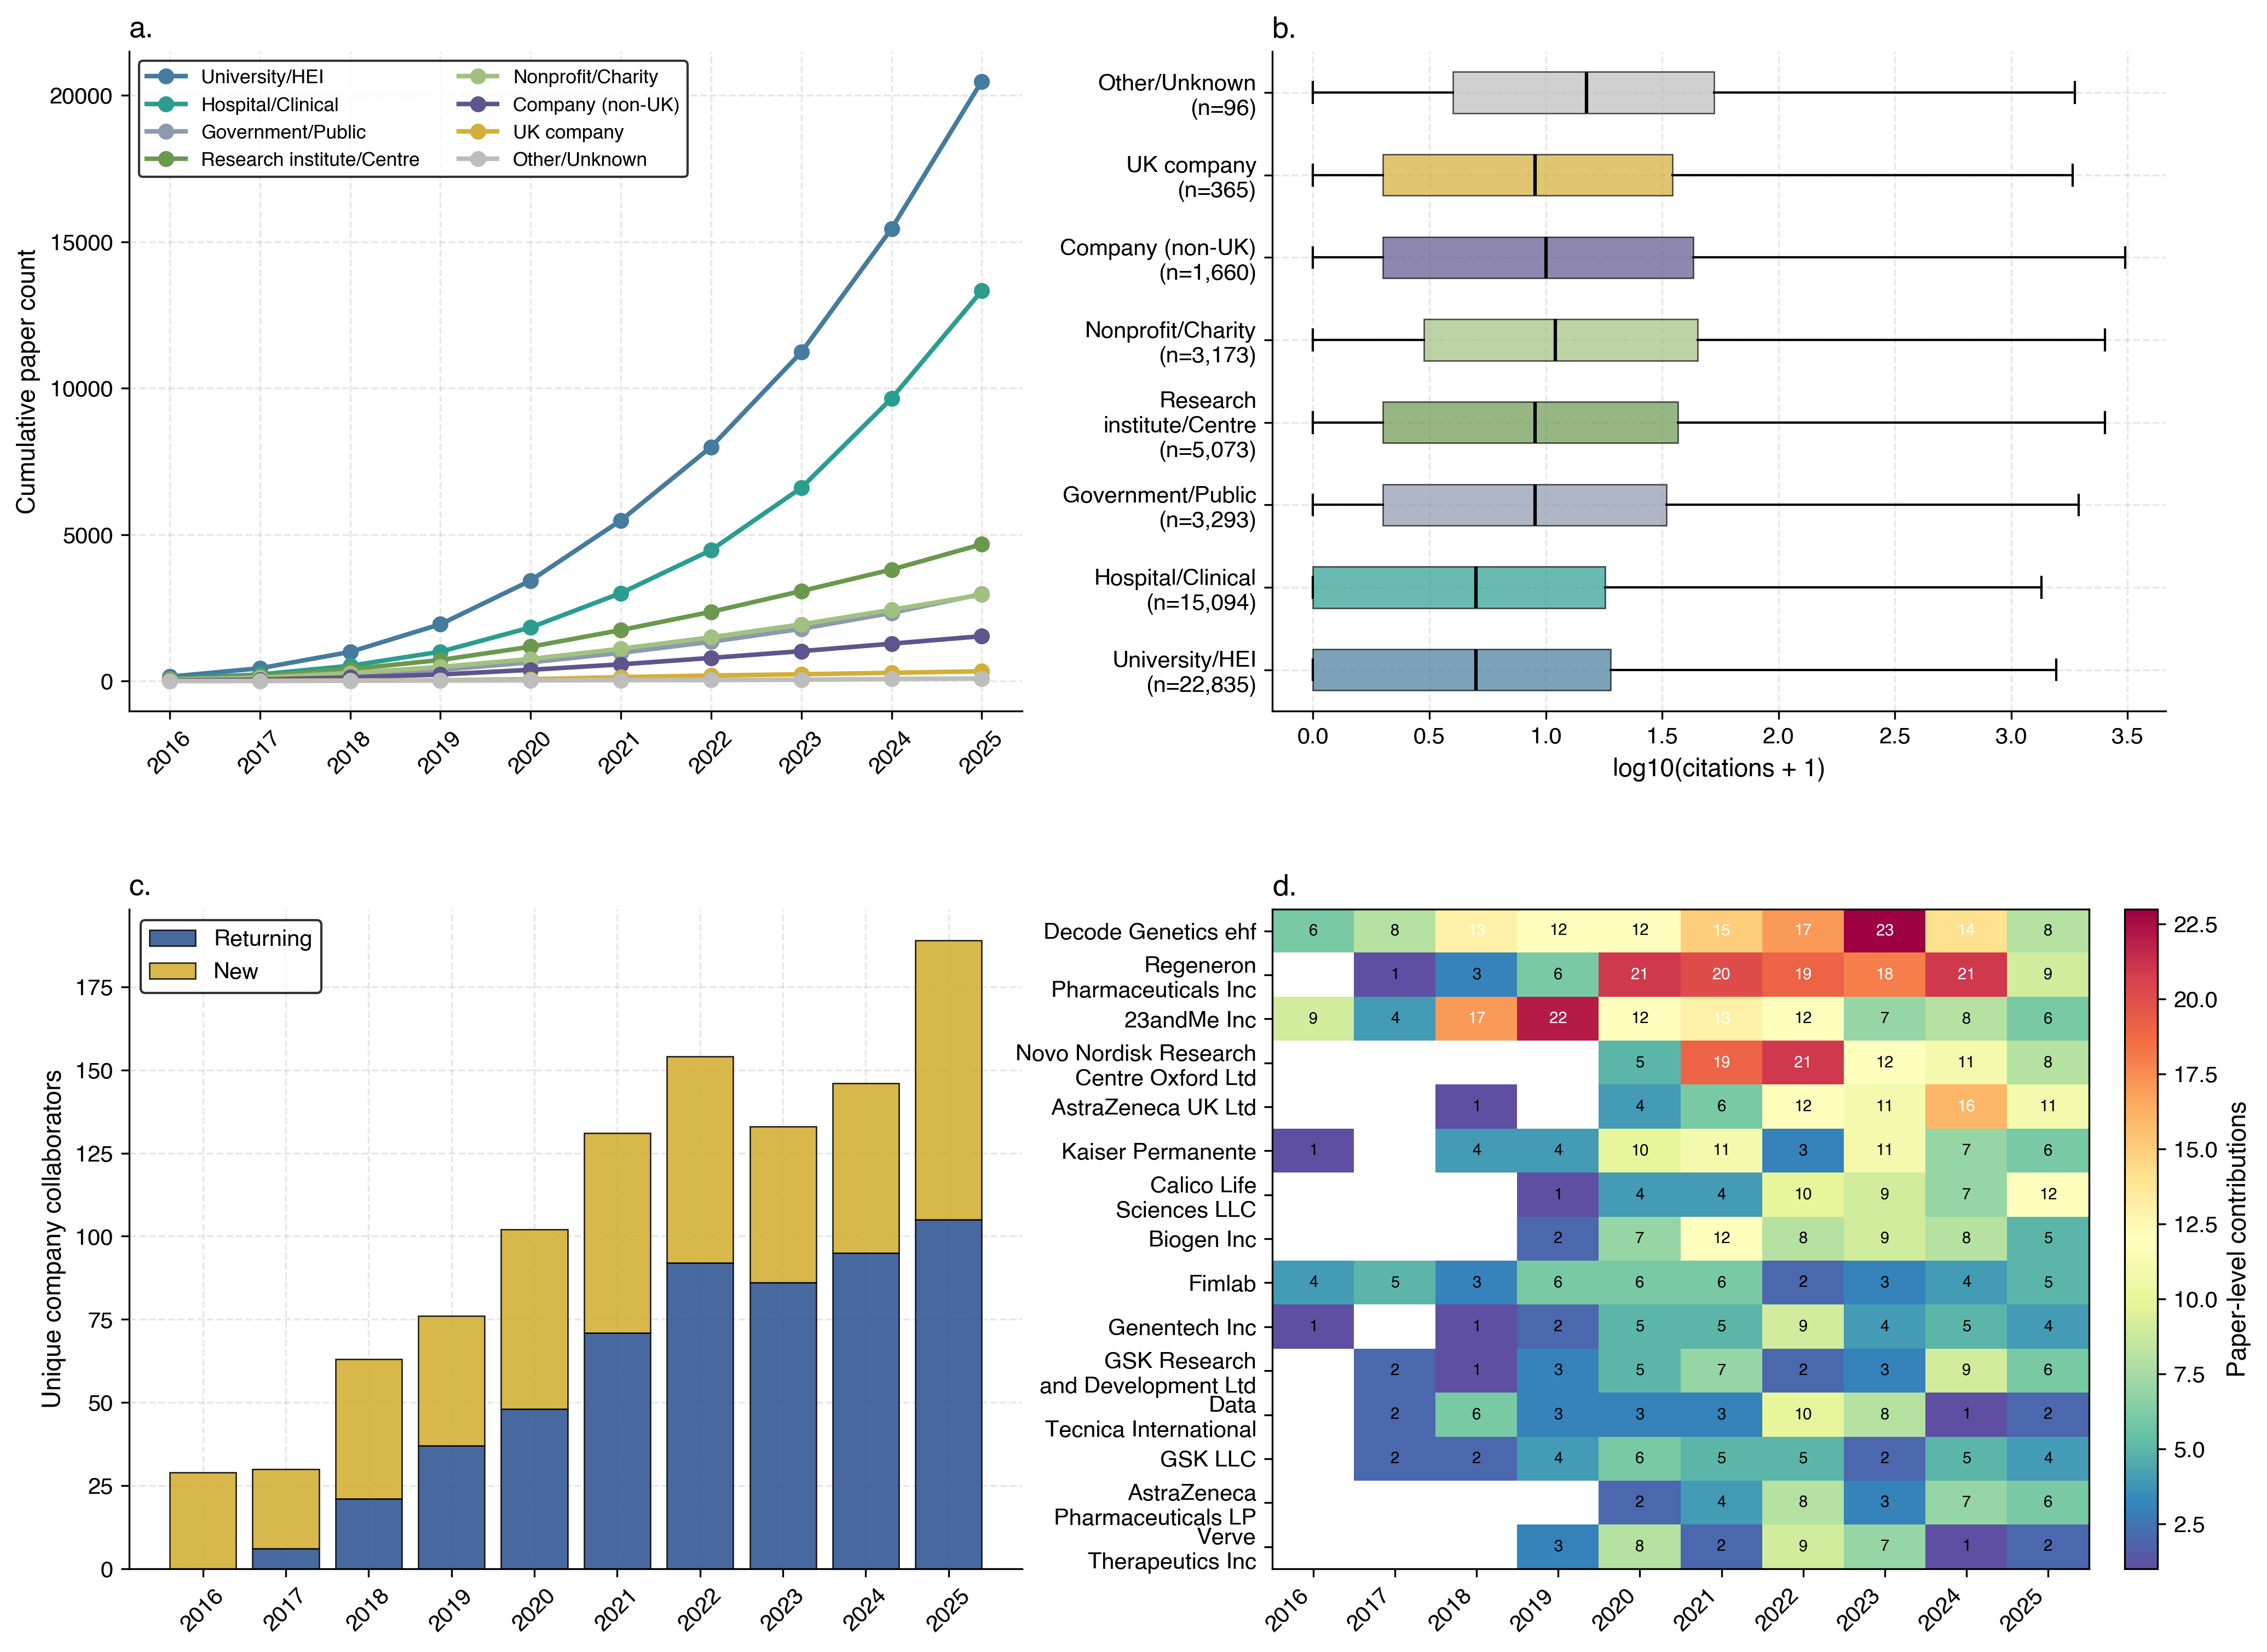

In [13]:
saved_pubfig = h.plot_publication_figure(
    df,
    start_year=2016,
    end_year=2025,
    citation_col="times_cited",
    top_company_n=15,
)